In [1]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Adjusting D_MODEL to 130 to be divisible by 5 heads.
Defined Muscle Groups (Indices): {'Finger Flexors': [2, 3], 'Finger Extensors': [4, 5], 'Wrist Flex/Dev': [1], 'Wrist Extend/Dev': [6, 7], 'Thumb': [0]}
Loading data from: s4_full.mat
Data loaded successfully.
Preprocessing data (No explicit filtering)...
Fitting scalers...
Scalers fitted.
Creating sequences from 35 valid trials...
Created 133000 sequences from 35 trials.
Train size: 106400, Validation size: 26600
Building MHA model...
MHA models built successfully.

--- Training Model Summary ---
Model: "Finger_MHA_Training_Model"
______________________________________________________________________________________________________________________________________________________
 Layer (type)                                    Output Shape                     Param #           Connected to                                      
 emg_input (InputLayer)                          [(None, 200, 8)]                 0                 []     

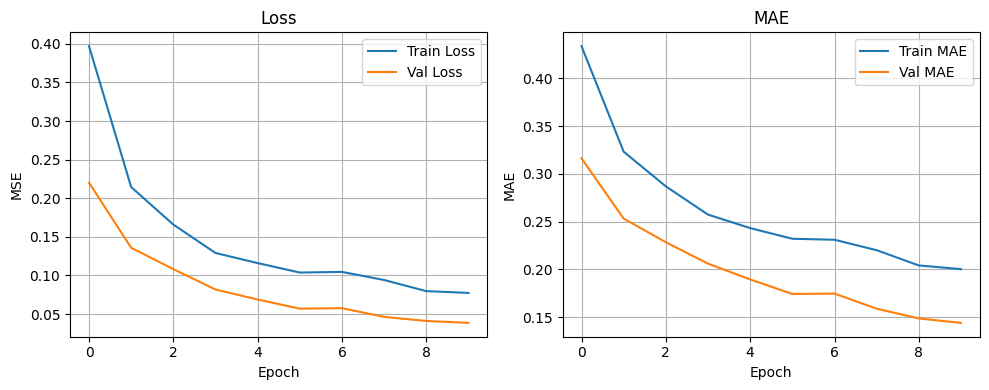


--- Performance Evaluation on Validation Set ---
832/832 [==============================] - 11s 12ms/step
Average R2 Score: 0.962
Average CC Score: 0.982


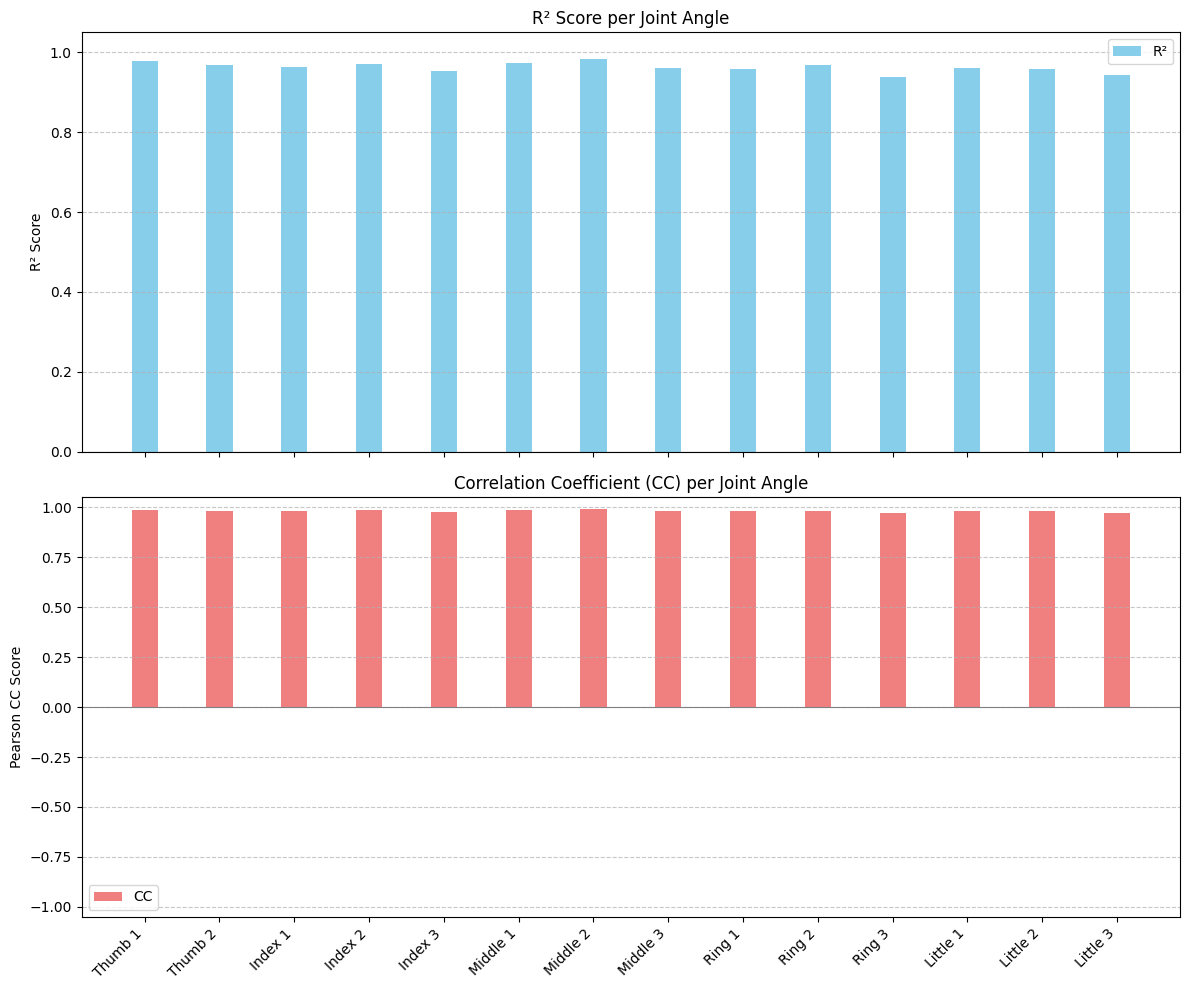

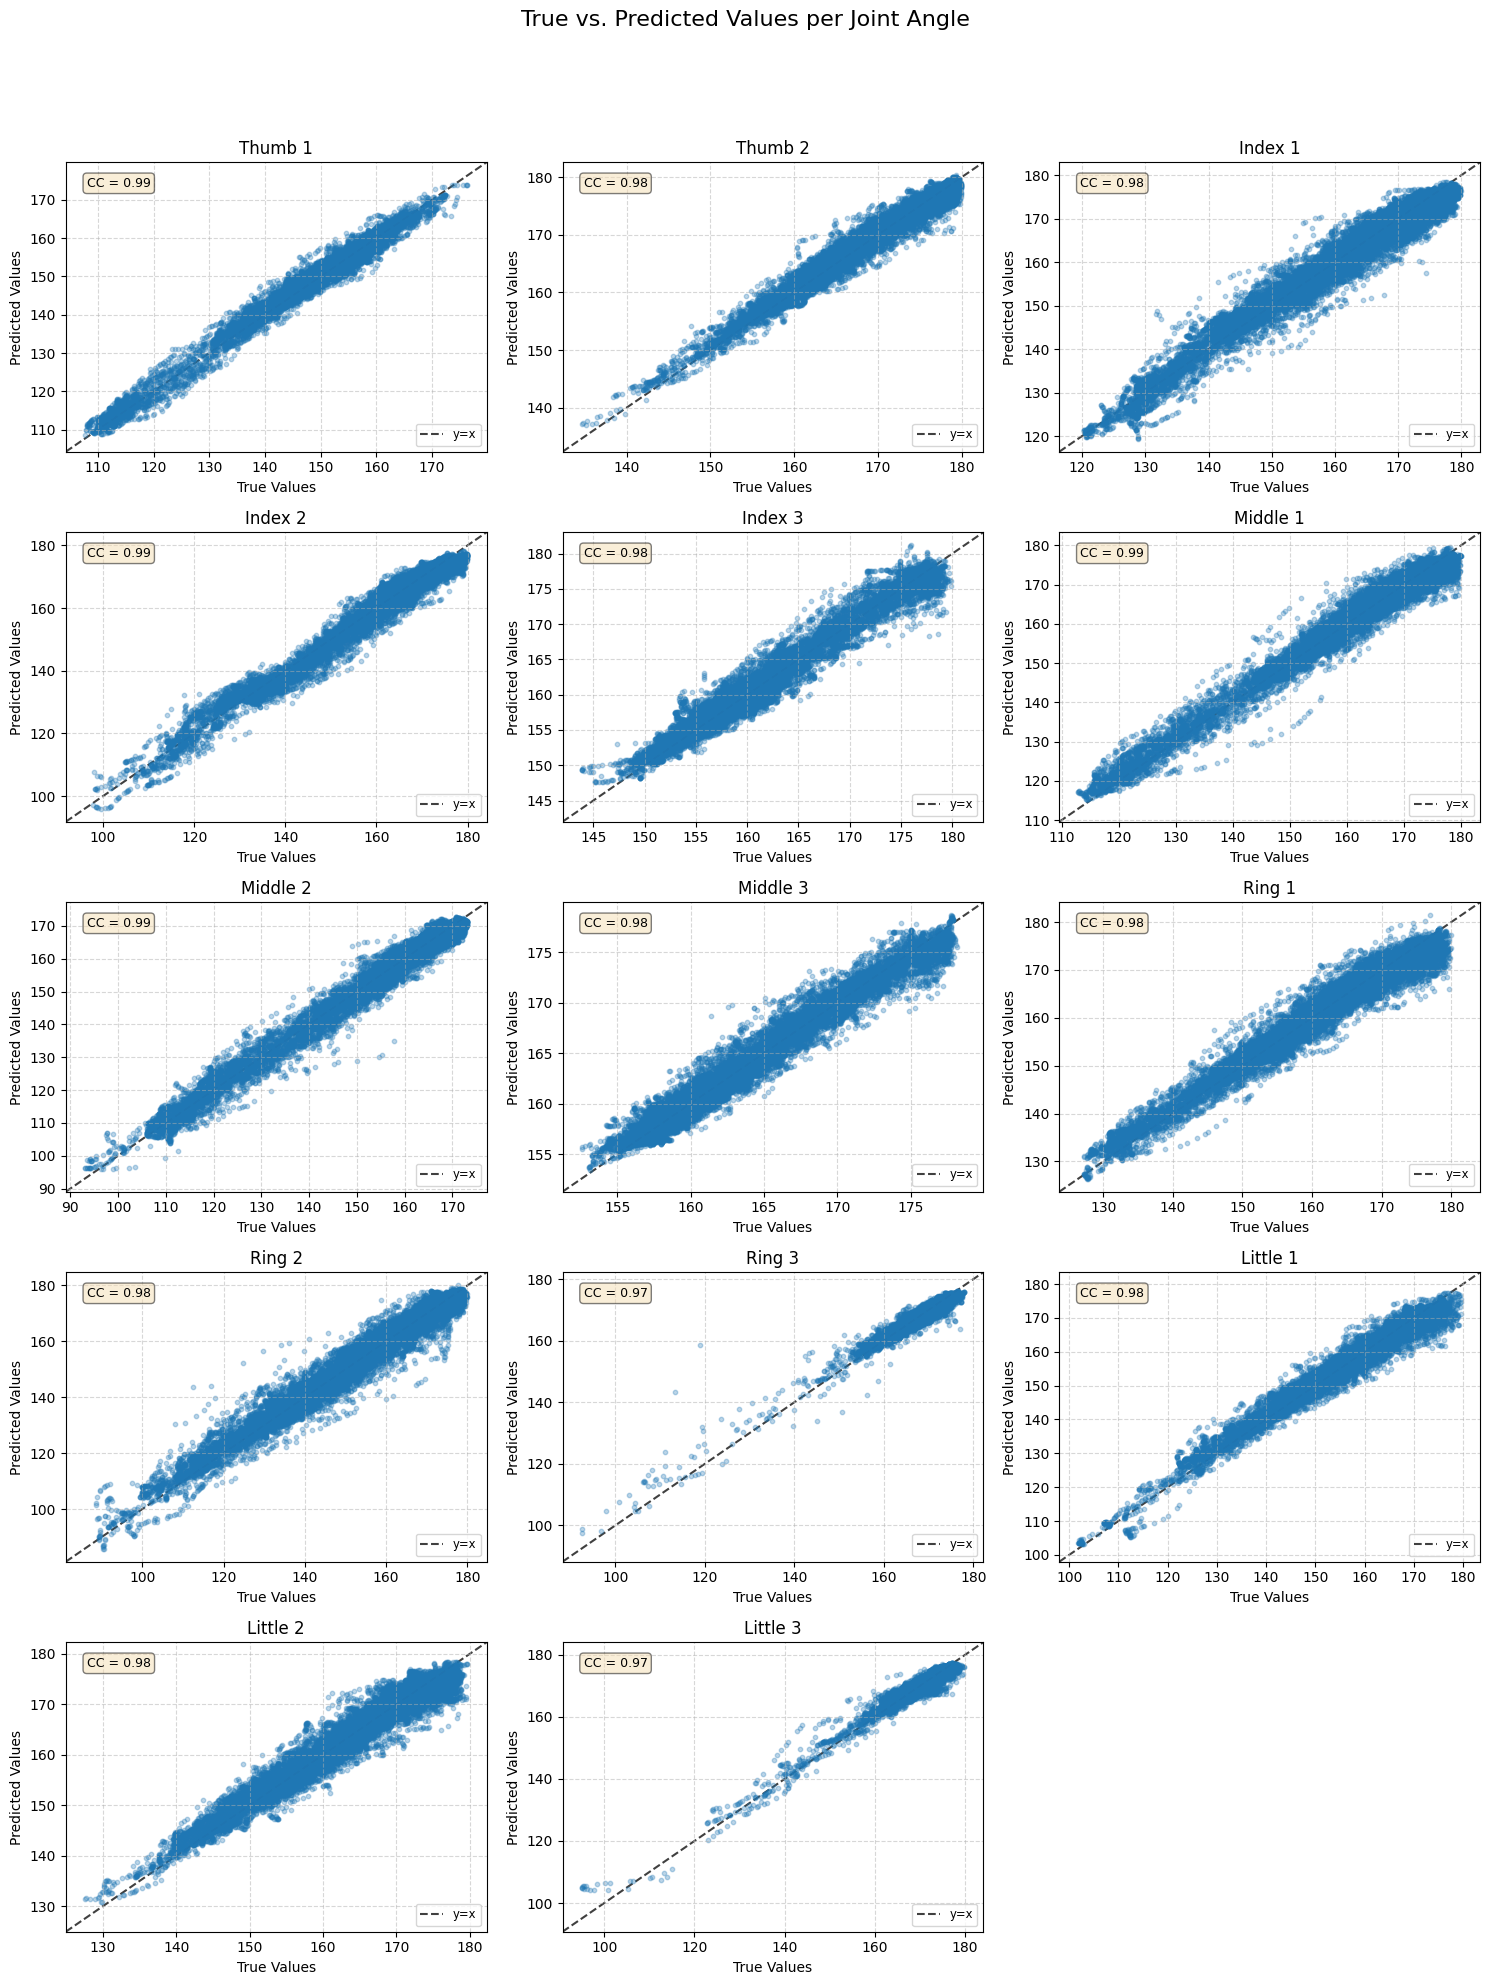


--- Detailed MHA Attention Visualization (Sample Windows) ---
Visualizing MHA attention heatmaps for the first 2 validation sample windows...

--- Visualizing MHA Attention Heatmap for Sample Window Index 0 ---


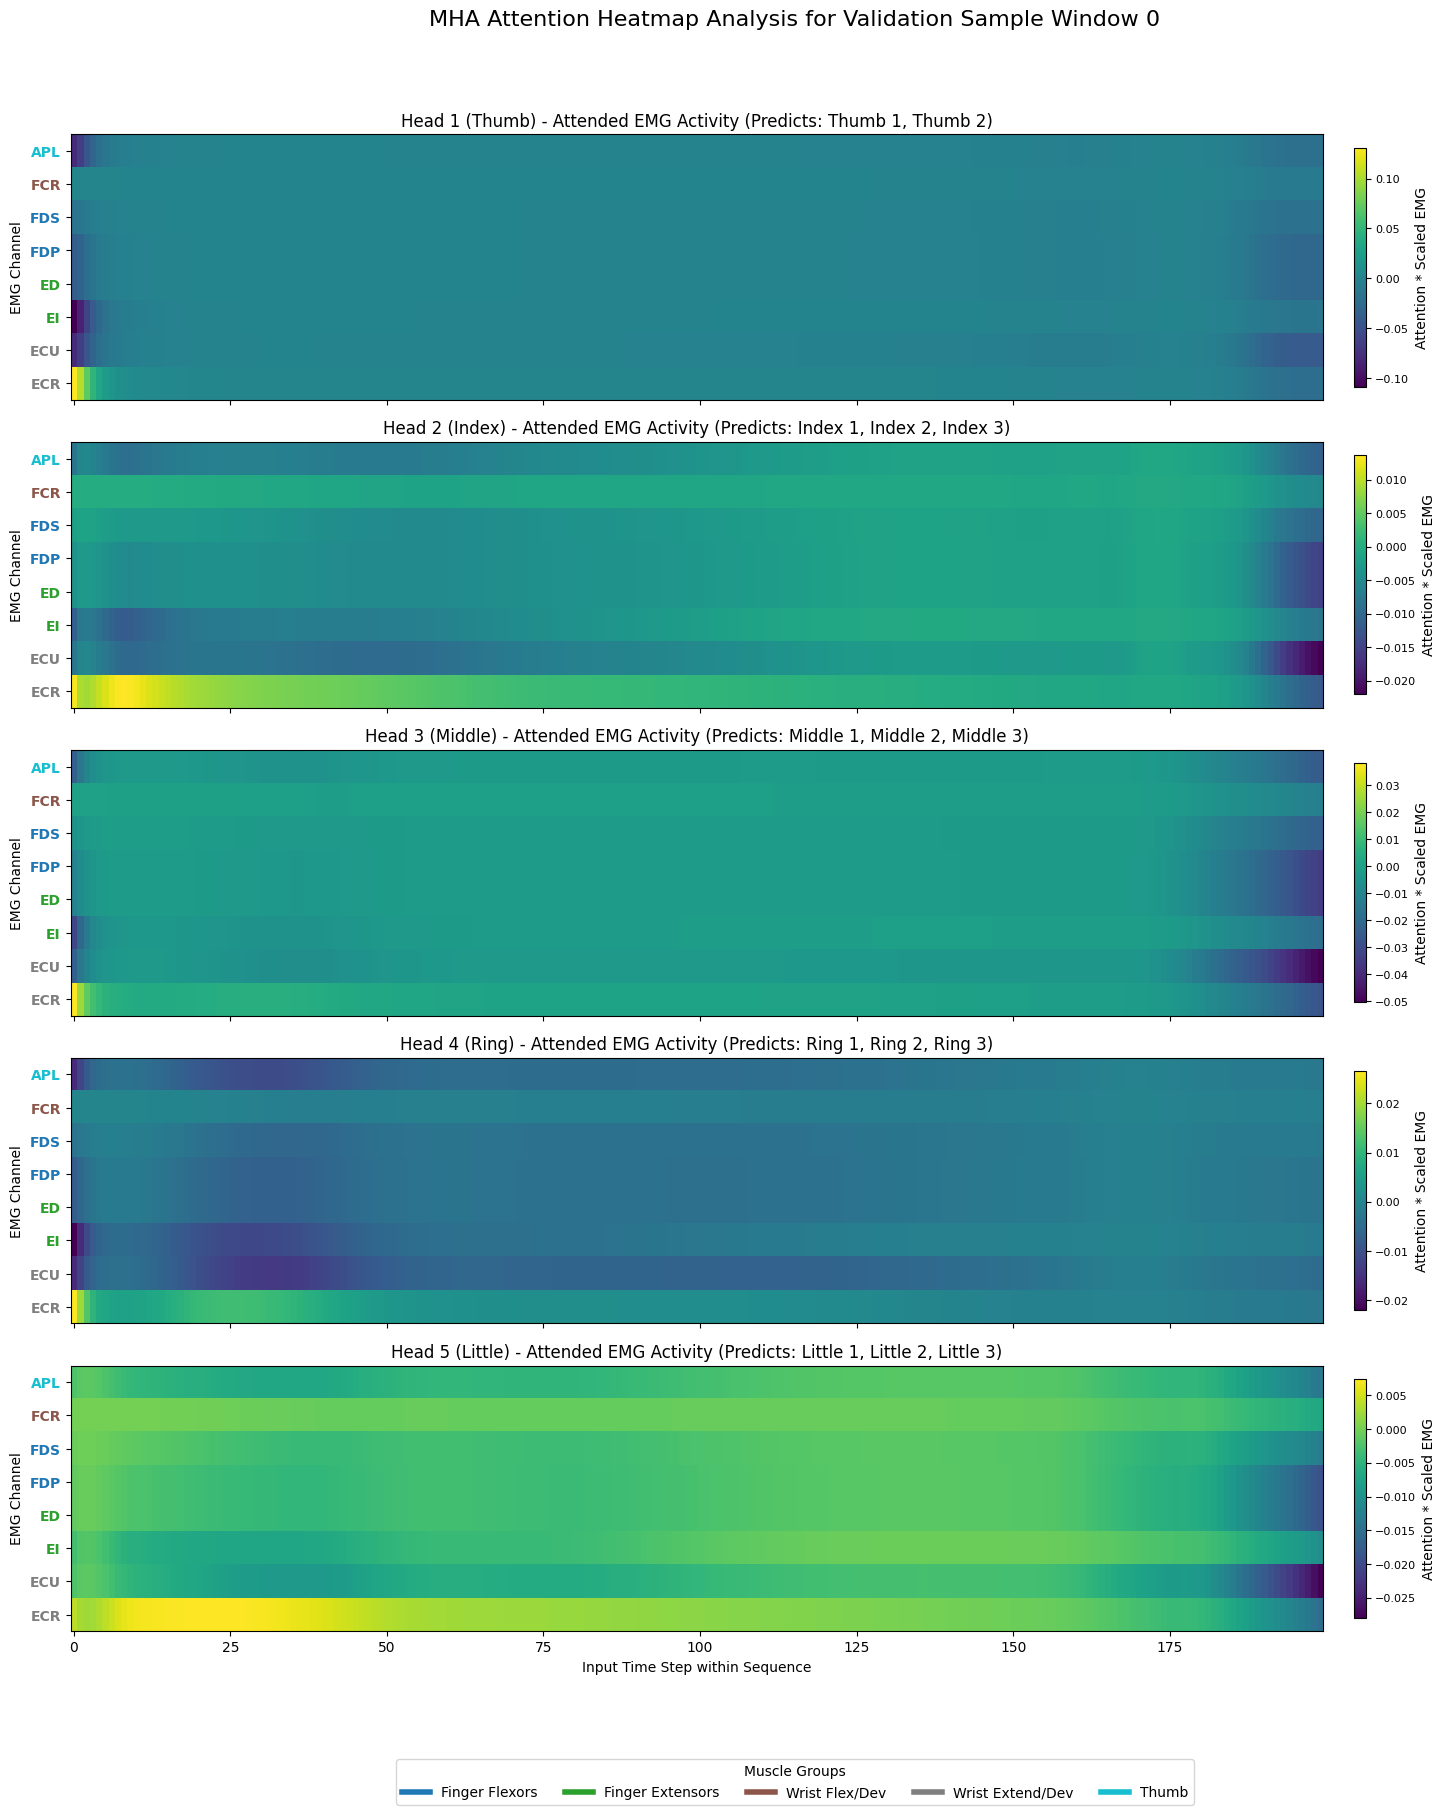


--- Visualizing MHA Attention Heatmap for Sample Window Index 1 ---


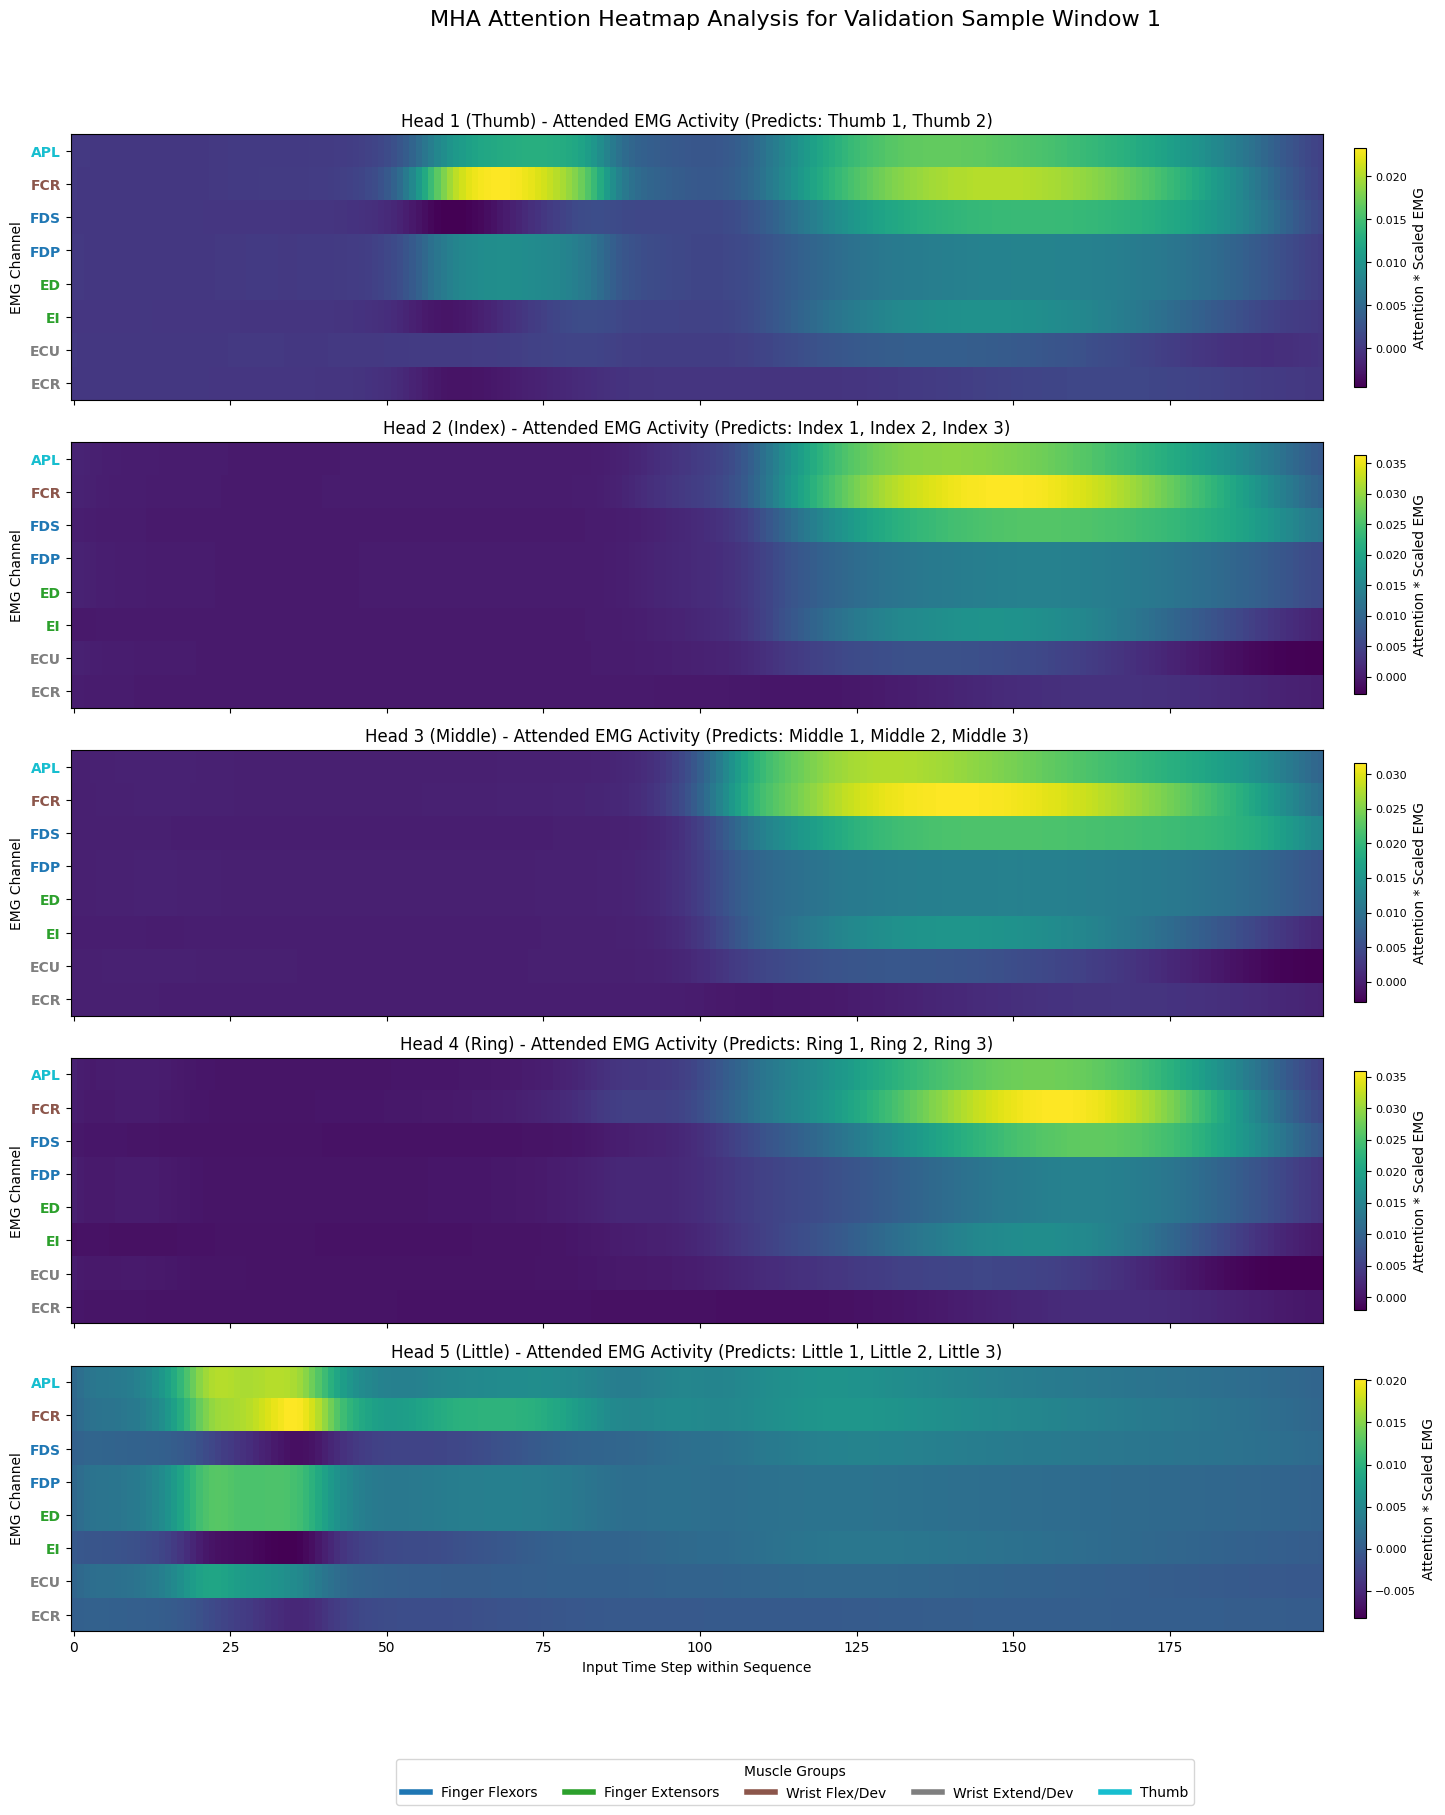


--- Dynamic Trial Simulation Visualization (EMG/Angle/Attention) ---
Visualizing dynamics simulation for the first 1 original trials...

--- Plotting Dynamics Simulation for Trial: T1_Task1 ---
Running model prediction for simulation...


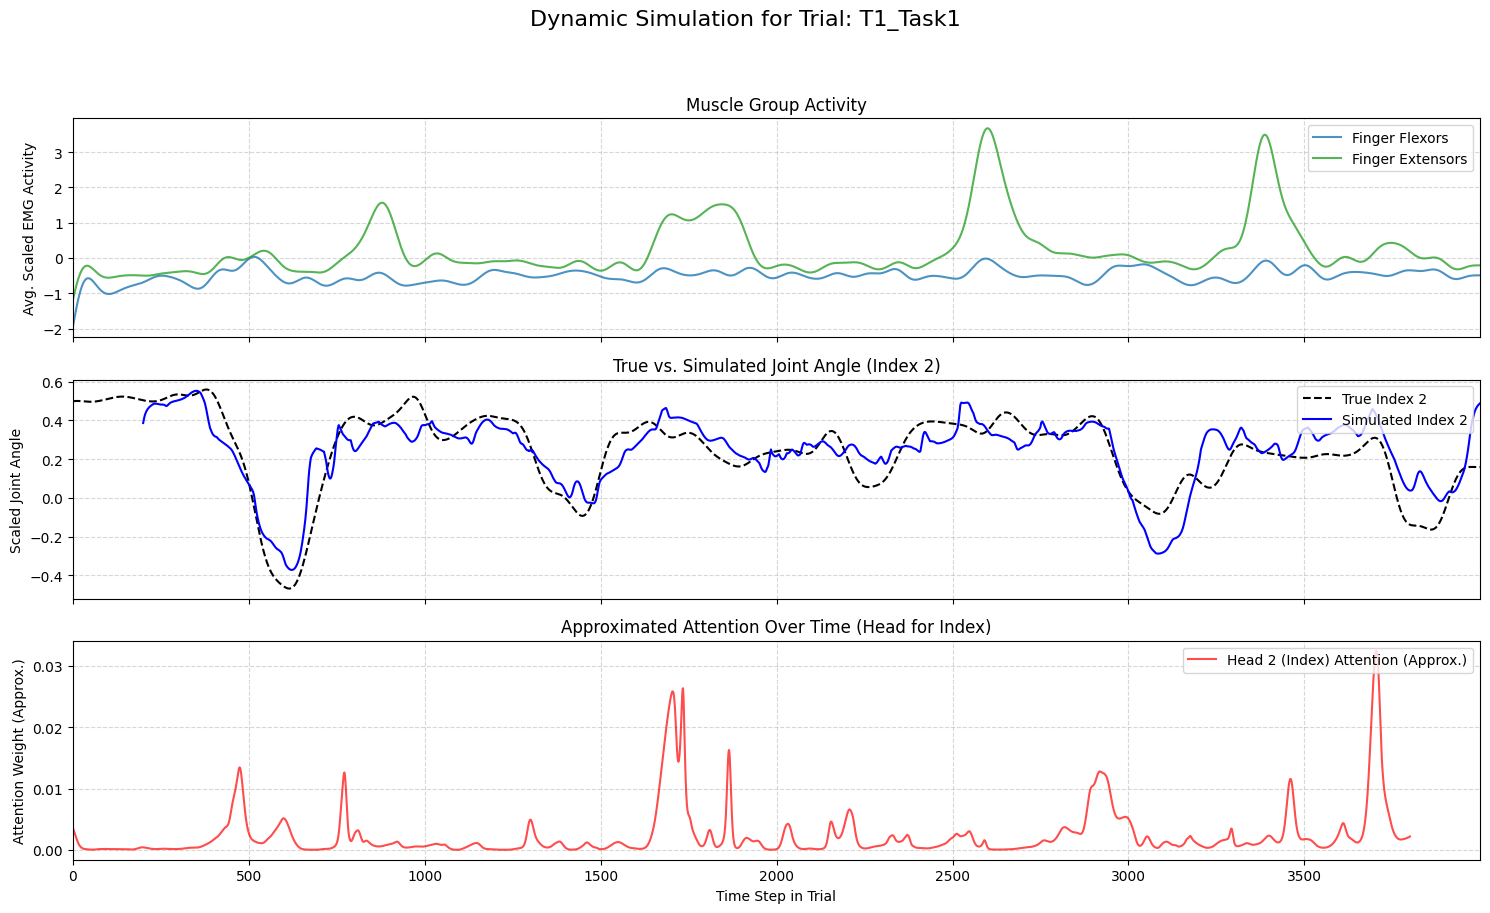


--- Integrated Gradients XAI Visualization ---
Calculating Integrated Gradients for the first 2 validation sample(s)...

--- Explaining Sample Index 0 ---
Explaining prediction for: Index 2 (Index 3)


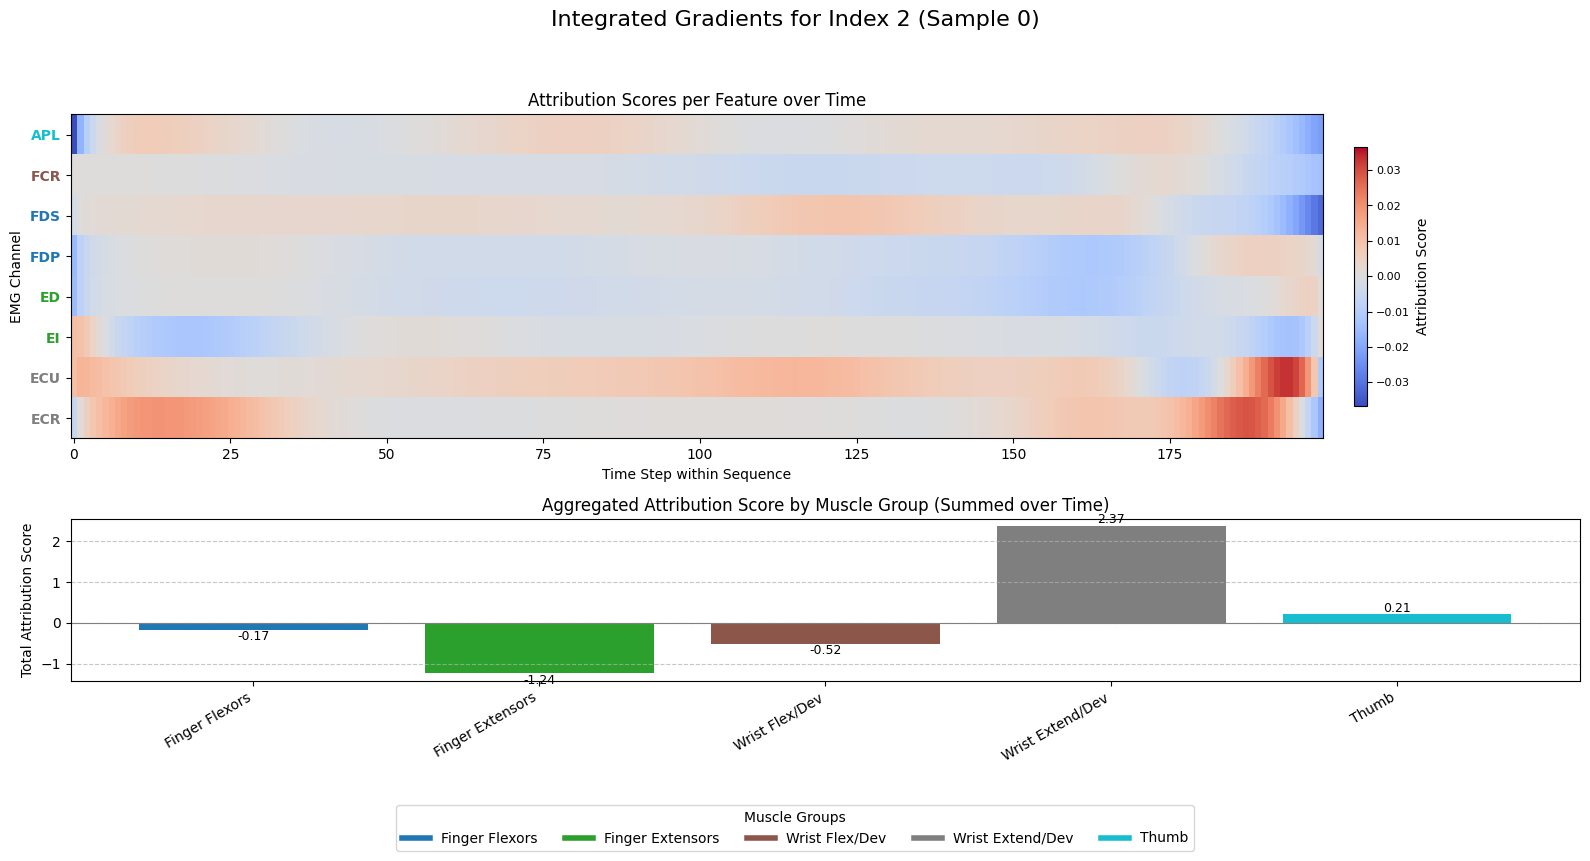


--- Explaining Sample Index 1 ---
Explaining prediction for: Index 2 (Index 3)


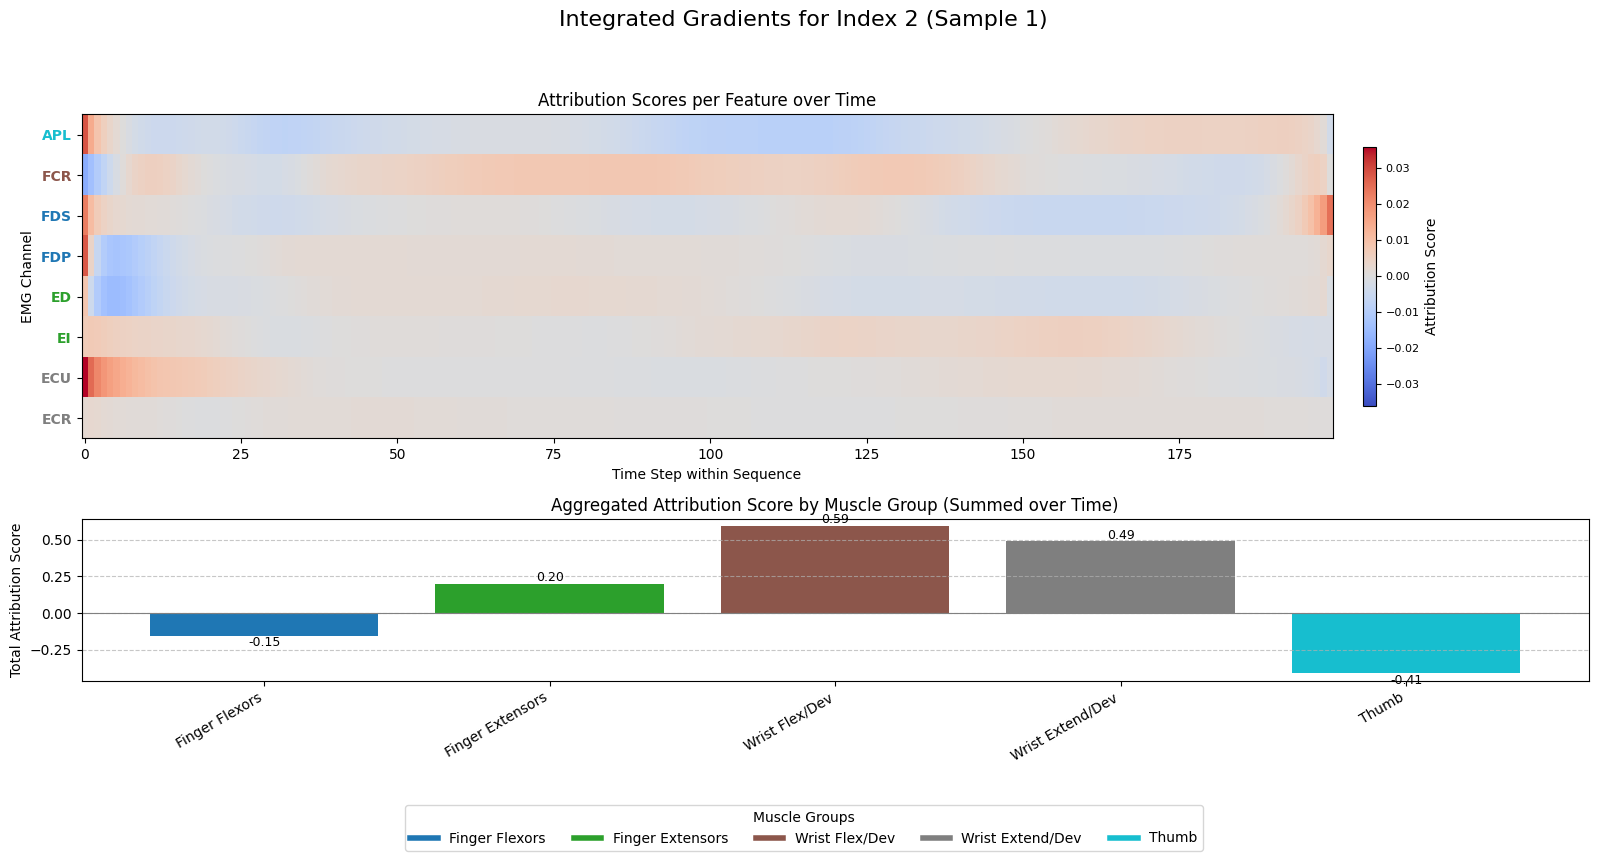

In [1]:
# -*- coding: utf-8 -*-
"""
Python script for predicting finger kinematics from EMG using a
Multi-Head Attention (MHA) LSTM model with specific EMG preprocessing
and Integrated Gradients for XAI.

Includes:
- Custom MHA model with separate finger heads.
- R2/CC score plotting.
- Regression correlation scatter plots.
- MHA Attention Heatmap visualization (per head, normalized).
- Dynamic Simulation plot (EMG/True Angle/Predicted Angle/Attention).
- Integrated Gradients calculation and visualization.

"""

import numpy as np
import scipy.io
import scipy.stats
# Removed: from scipy.signal import butter, sosfiltfilt # For filtering
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Layer, Dropout, Lambda, LayerNormalization, MultiHeadAttention,
    Concatenate
)
from tensorflow.keras import backend as K
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import r2_score
import os
import warnings
import math

# --- Configuration ---
MAT_FILE_PATH = 's4_full.mat' # <<<--- Example path, UPDATE FOR COLAB
SEQUENCE_LENGTH = 200
PREDICTION_HORIZON = 1 # Keep as 1 for current model structure
BATCH_SIZE = 128
EPOCHS = 10 # Adjust as needed
LSTM_UNITS = 128
VALIDATION_SPLIT = 0.2
MAX_SAMPLES_TO_VIZ_MHA = 2 # Limit detailed MHA heatmap visualization output
NUM_TRIALS_TO_PLOT_DYNAMICS = 1 # Limit dynamic plot output
NUM_SAMPLES_FOR_XAI = 2 # How many samples to run XAI (IG) on
MAX_SAMPLES_TO_VIZ = 2 # Limit detailed visualization output


# MHA Configuration
NUM_ATTENTION_HEADS = 5
D_MODEL = LSTM_UNITS
if D_MODEL % NUM_ATTENTION_HEADS != 0:
     D_MODEL = math.ceil(D_MODEL / NUM_ATTENTION_HEADS) * NUM_ATTENTION_HEADS
     print(f"Adjusting D_MODEL to {D_MODEL} to be divisible by {NUM_ATTENTION_HEADS} heads.")

# Integrated Gradients Config
IG_STEPS = 50 # Number of steps for approximation

# EMG Channel Names
EMG_CHANNEL_NAMES = ['APL', 'FCR', 'FDS', 'FDP', 'ED', 'EI', 'ECU', 'ECR']
# Joint Angle Names
JOINT_ANGLE_NAMES = [
    'Thumb 1', 'Thumb 2', 'Index 1', 'Index 2', 'Index 3', 'Middle 1', 'Middle 2', 'Middle 3',
    'Ring 1', 'Ring 2', 'Ring 3', 'Little 1', 'Little 2', 'Little 3'
]
# Finger to Joint Mapping
FINGER_JOINT_INDICES = {
    'Thumb': list(range(0, 2)), 'Index': list(range(2, 5)), 'Middle': list(range(5, 8)),
    'Ring': list(range(8, 11)), 'Little': list(range(11, 14))
}
FINGER_NAMES = list(FINGER_JOINT_INDICES.keys())

# --- Muscle Group Definitions ---
MUSCLE_GROUPS = {
    'Finger Flexors': [EMG_CHANNEL_NAMES.index('FDS'), EMG_CHANNEL_NAMES.index('FDP')],
    'Finger Extensors': [EMG_CHANNEL_NAMES.index('ED'), EMG_CHANNEL_NAMES.index('EI')],
    'Wrist Flex/Dev': [EMG_CHANNEL_NAMES.index('FCR')],
    'Wrist Extend/Dev': [EMG_CHANNEL_NAMES.index('ECU'), EMG_CHANNEL_NAMES.index('ECR')],
    'Thumb': [EMG_CHANNEL_NAMES.index('APL')]
}
# Assign colors
try: cmap = plt.colormaps.get_cmap('tab10')
except AttributeError: cmap = plt.cm.get_cmap('tab10')
GROUP_COLORS = cmap(np.linspace(0, 1, len(MUSCLE_GROUPS)))
MUSCLE_GROUP_VIS_INFO = {name: {'indices': indices, 'color': GROUP_COLORS[i]}
                         for i, (name, indices) in enumerate(MUSCLE_GROUPS.items())}
print("Defined Muscle Groups (Indices):", MUSCLE_GROUPS)

# --- Custom Multi-Head Attention Layer ---
# (Definition remains the same as previous version)
class CustomMultiHeadAttentionSeparateOutput(Layer):
    """ Custom MHA layer returning separate context vectors per head. """
    def __init__(self, num_heads, d_model, **kwargs):
        super().__init__(**kwargs)
        if d_model % num_heads != 0: raise ValueError(f"d_model ({d_model}) must be divisible by num_heads ({num_heads})")
        self.num_heads = num_heads; self.d_model = d_model; self.depth = d_model // num_heads
        self.wq = Dense(d_model, name='q_proj'); self.wk = Dense(d_model, name='k_proj'); self.wv = Dense(d_model, name='v_proj')

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def scaled_dot_product_attention(self, q, k, v, mask=None):
        matmul_qk = tf.matmul(q, k, transpose_b=True)
        dk = tf.cast(tf.shape(k)[-1], tf.float32)
        scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)
        if mask is not None: scaled_attention_logits += (mask * -1e9)
        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
        output = tf.matmul(attention_weights, v)
        return output, attention_weights

    def call(self, query, value, key, mask=None, return_attention_scores=False):
        batch_size = tf.shape(query)[0]
        q = self.wq(query); k = self.wk(key); v = self.wv(value)
        q = self.split_heads(q, batch_size); k = self.split_heads(k, batch_size); v = self.split_heads(v, batch_size)
        scaled_attention, attention_weights = self.scaled_dot_product_attention(q, k, v, mask)
        scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])
        head_outputs = [scaled_attention[:, :, i, :] for i in range(self.num_heads)]
        if query.shape[1] == 1: head_outputs_squeezed = [tf.squeeze(head, axis=1) for head in head_outputs]
        else: head_outputs_squeezed = head_outputs
        squeezed_attention_weights = tf.squeeze(attention_weights, axis=2)
        if return_attention_scores: return head_outputs_squeezed, squeezed_attention_weights
        else: return head_outputs_squeezed

    def get_config(self):
        config = super().get_config()
        config.update({'num_heads': self.num_heads, 'd_model': self.d_model})
        return config

# --- 1. Data Loading ---
def load_mat_data(filepath):
    """Loads EMG and joint angle data from the specified .mat file."""
    print(f"Loading data from: {filepath}")
    if not os.path.exists(filepath): print(f"Error: File not found at {filepath}"); return None, None, None
    try:
        mat_data = scipy.io.loadmat(filepath)
        emg_data_cells = mat_data['dsfilt_emg']
        joint_angles_cells = mat_data['joint_angles']
        kinematics_data = mat_data.get('finger_kinematics', None)
        print("Data loaded successfully.")
        return emg_data_cells, joint_angles_cells, kinematics_data
    except Exception as e: print(f"An error occurred during loading: {e}"); return None, None, None

# --- 2. Data Preprocessing (Filtering Removed) ---
# Removed filter design and application functions

# Removed filter parameters from signature
def preprocess_data(emg_data_cells, joint_angles_cells, sequence_length, prediction_horizon):
    """ Preprocesses data: flattens, creates sequences, normalizes, splits. (No filtering) """
    print("Preprocessing data (No explicit filtering)...")
    all_emg_sequences, all_angle_targets = [], []
    original_scaled_trials = []
    num_trials, num_tasks = emg_data_cells.shape
    emg_scaler, angle_scaler = StandardScaler(), StandardScaler()
    temp_emg_list, temp_angle_list = [], []

    # --- Fit scalers first (on raw data) ---
    print("Fitting scalers...")
    emg_list_for_scaling = [] # Renamed list
    angle_list_for_scaling = []
    valid_trial_count = 0
    for i in range(num_trials):
        for j in range(num_tasks):
            if isinstance(emg_data_cells[i, j], np.ndarray) and emg_data_cells[i, j].ndim == 2 and emg_data_cells[i, j].shape[0] > 0 and \
               isinstance(joint_angles_cells[i, j], np.ndarray) and joint_angles_cells[i, j].ndim == 2 and joint_angles_cells[i, j].shape[0] > 0:
                min_len = min(emg_data_cells[i,j].shape[0], joint_angles_cells[i,j].shape[0])
                if min_len >= sequence_length + prediction_horizon:
                    trial_emg = emg_data_cells[i, j][:min_len, :] # Use raw EMG
                    trial_angle = joint_angles_cells[i, j][:min_len, :]
                    # --- Filtering Removed ---
                    emg_list_for_scaling.append(trial_emg) # Append raw EMG
                    angle_list_for_scaling.append(trial_angle)
                    valid_trial_count += 1

    if not emg_list_for_scaling: print("Error: No valid data/trials long enough found."); return None, None, None, None, None, None, None
    full_emg_data = np.vstack(emg_list_for_scaling); full_angle_data = np.vstack(angle_list_for_scaling)
    if np.any(np.isnan(full_emg_data)) or np.any(np.isinf(full_emg_data)) or \
       np.any(np.isnan(full_angle_data)) or np.any(np.isinf(full_angle_data)): raise ValueError("NaN or Inf detected in data.")
    emg_scaler.fit(full_emg_data); angle_scaler.fit(full_angle_data); print("Scalers fitted.")

    # --- Create sequences and store original scaled trials ---
    print(f"Creating sequences from {valid_trial_count} valid trials...")
    trial_count = 0
    for i in range(num_trials):
        for j in range(num_tasks):
             if isinstance(emg_data_cells[i, j], np.ndarray) and emg_data_cells[i, j].ndim == 2 and emg_data_cells[i, j].shape[0] > 0 and \
               isinstance(joint_angles_cells[i, j], np.ndarray) and joint_angles_cells[i, j].ndim == 2 and joint_angles_cells[i, j].shape[0] > 0:
                min_len = min(emg_data_cells[i,j].shape[0], joint_angles_cells[i,j].shape[0])
                if min_len >= sequence_length + prediction_horizon:
                    trial_emg = emg_data_cells[i, j][:min_len, :] # Raw EMG
                    trial_angle = joint_angles_cells[i, j][:min_len, :]
                    # --- Filtering Removed ---
                    # Scale the full raw trial
                    trial_emg_scaled = emg_scaler.transform(trial_emg) # Scale raw EMG
                    trial_angle_scaled = angle_scaler.transform(trial_angle)
                    original_scaled_trials.append({'emg': trial_emg_scaled, 'angle': trial_angle_scaled, 'id': f"T{i+1}_Task{j+1}"})
                    # Create sequences from this scaled trial
                    for k in range(len(trial_emg_scaled) - sequence_length - prediction_horizon + 1):
                        emg_sequence = trial_emg_scaled[k : k + sequence_length]
                        angle_target = trial_angle_scaled[k + sequence_length : k + sequence_length + prediction_horizon]
                        if prediction_horizon == 1: angle_target = angle_target.squeeze(axis=0)
                        all_emg_sequences.append(emg_sequence); all_angle_targets.append(angle_target)
                    trial_count += 1

    if not all_emg_sequences: print("Error: Could not create sequences."); return None, None, None, None, None, None, None
    X = np.array(all_emg_sequences); y = np.array(all_angle_targets); print(f"Created {X.shape[0]} sequences from {trial_count} trials.")
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=VALIDATION_SPLIT, random_state=42, shuffle=True)
    print(f"Train size: {X_train.shape[0]}, Validation size: {X_val.shape[0]}")
    return X_train, X_val, y_train, y_val, emg_scaler, angle_scaler, original_scaled_trials


# --- 3. Model Architecture (MHA Redesign) ---
# (Definition remains the same as previous version)
def build_finger_mha_lstm(sequence_length, num_emg_features, num_angle_features,
                          lstm_units, d_model, num_heads, finger_joint_indices):
    """ Builds LSTM with Custom MHA and separate finger prediction heads. """
    print("Building MHA model...")
    if num_heads != len(finger_joint_indices): raise ValueError("Number of heads must match number of fingers defined.")
    encoder_inputs = Input(shape=(sequence_length, num_emg_features), name='emg_input')
    encoder_lstm = LSTM(lstm_units, return_sequences=True, return_state=True, name='encoder_lstm')
    if d_model != lstm_units: print(f"Warning: d_model({d_model}) != lstm_units({lstm_units}). Ensure consistency.")
    encoder_outputs, state_h, state_c = encoder_lstm(encoder_inputs)
    encoder_outputs_norm = LayerNormalization(epsilon=1e-6)(encoder_outputs)
    state_h_norm = LayerNormalization(epsilon=1e-6)(state_h)
    query = Lambda(lambda x: tf.expand_dims(x, axis=1), name='expand_query_dim')(state_h_norm)
    value = encoder_outputs_norm; key = encoder_outputs_norm
    mha_layer = CustomMultiHeadAttentionSeparateOutput(num_heads=num_heads, d_model=d_model, name='custom_mha')
    head_context_vectors, attention_weights = mha_layer(query=query, value=value, key=key, return_attention_scores=True)
    finger_outputs = []
    finger_names = list(finger_joint_indices.keys())
    for i in range(num_heads):
        finger_name = finger_names[i]; num_finger_joints = len(finger_joint_indices[finger_name])
        head_context = head_context_vectors[i]
        finger_dense1 = Dense(32, activation='relu', name=f'{finger_name}_dense1')(head_context)
        finger_dropout = Dropout(0.2, name=f'{finger_name}_dropout')(finger_dense1)
        finger_output = Dense(num_finger_joints, activation='linear', name=f'{finger_name}_output')(finger_dropout)
        finger_outputs.append(finger_output)
    final_output = Concatenate(axis=-1, name='final_concatenated_output')(finger_outputs)
    model = Model(inputs=encoder_inputs, outputs=final_output, name='Finger_MHA_Training_Model')
    attention_model = Model(inputs=encoder_inputs, outputs=attention_weights, name='Finger_MHA_Attention_Model')
    print("MHA models built successfully.")
    return model, attention_model

# --- 4. Training ---
# (Definition remains the same as previous version)
def train_model(model, X_train, y_train, X_val, y_val, epochs, batch_size):
    """ Compiles and trains the model. """
    print("Compiling model...")
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    print("Starting training...")
    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_val, y_val), callbacks=[early_stopping], verbose=1)
    print("Training finished.")
    return history

# --- 5. Performance Evaluation & Visualization ---
# (Definitions remain the same as previous version)
def calculate_performance_scores(y_true, y_pred):
    """ Calculates R2 and CC scores for each output feature. """
    if y_true.shape != y_pred.shape: raise ValueError(f"Shape mismatch: y_true {y_true.shape}, y_pred {y_pred.shape}")
    if y_true.ndim != 2: raise ValueError(f"Expected 2D arrays, got shapes: y_true {y_true.shape}, y_pred {y_pred.shape}")
    num_features = y_true.shape[1]
    r2_scores, cc_scores, cc_pvalues = [], [], []
    for i in range(num_features):
        r2 = r2_score(y_true[:, i], y_pred[:, i])
        r2_scores.append(r2)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)
            cc, p_value = scipy.stats.pearsonr(y_true[:, i], y_pred[:, i])
            if np.isnan(cc): cc, p_value = 0.0, 1.0
        cc_scores.append(cc); cc_pvalues.append(p_value)
    return np.array(r2_scores), np.array(cc_scores), np.array(cc_pvalues)

def plot_performance_scores(r2_scores, cc_scores, angle_names):
    """ Creates bar plots for R2 and CC scores. """
    num_angles = len(angle_names); x = np.arange(num_angles); width = 0.35
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    rects1 = ax1.bar(x, r2_scores, width, label='R²', color='skyblue')
    ax1.set_ylabel('R² Score'); ax1.set_title('R² Score per Joint Angle')
    ax1.set_ylim(min(0, np.min(r2_scores)-0.1 if r2_scores.size > 0 else 0), 1.05); ax1.axhline(0, color='grey', lw=0.8)
    ax1.legend(); ax1.grid(axis='y', linestyle='--', alpha=0.7)
    rects2 = ax2.bar(x, cc_scores, width, label='CC', color='lightcoral')
    ax2.set_ylabel('Pearson CC Score'); ax2.set_title('Correlation Coefficient (CC) per Joint Angle')
    ax2.set_xticks(x); ax2.set_xticklabels(angle_names, rotation=45, ha='right')
    ax2.set_ylim(-1.05, 1.05); ax2.axhline(0, color='grey', lw=0.8)
    ax2.legend(); ax2.grid(axis='y', linestyle='--', alpha=0.7)
    fig.tight_layout(); plt.show()

def plot_regression_correlation(y_true, y_pred, angle_names, cc_scores=None):
    """ Creates scatter plots for true vs predicted values for each angle. """
    num_angles = y_true.shape[1]
    if num_angles != len(angle_names): angle_names = [f"Angle {i+1}" for i in range(num_angles)]
    ncols = 3; nrows = math.ceil(num_angles / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharex=False, sharey=False)
    axes = axes.flatten()
    for i in range(num_angles):
        ax = axes[i]; true_vals = y_true[:, i]; pred_vals = y_pred[:, i]
        ax.scatter(true_vals, pred_vals, alpha=0.3, s=10)
        min_val = min(np.min(true_vals), np.min(pred_vals)); max_val = max(np.max(true_vals), np.max(pred_vals))
        padding = (max_val - min_val) * 0.05; lims = [min_val - padding, max_val + padding]
        ax.plot(lims, lims, 'k--', alpha=0.75, zorder=0, label='y=x'); ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_xlabel("True Values"); ax.set_ylabel("Predicted Values"); ax.set_title(f"{angle_names[i]}")
        ax.grid(True, linestyle='--', alpha=0.5)
        if cc_scores is not None and i < len(cc_scores): cc = cc_scores[i]; ax.text(0.05, 0.95, f'CC = {cc:.2f}', transform=ax.transAxes, fontsize=9, va='top', bbox=dict(boxstyle='round,pad=0.3', fc='wheat', alpha=0.5))
        ax.legend(loc='lower right', fontsize='small')
    for j in range(num_angles, len(axes)): fig.delaxes(axes[j])
    fig.suptitle("True vs. Predicted Values per Joint Angle", fontsize=16, y=1.02)
    fig.tight_layout(rect=[0, 0.03, 1, 0.98]); plt.show()


# --- 6. Attention Visualization (MHA Redesign - Updated) ---
# (Definitions remain the same as previous version)
def get_mha_attention_weights(input_data, attention_model):
    """ Extracts MHA attention weights (batch, heads, seq_len). """
    try:
        input_data_float32 = input_data.astype(np.float32)
        attention_weights = attention_model.predict(input_data_float32, verbose=0)
        return attention_weights
    except Exception as e: print(f"Error during MHA attention weight prediction: {e}"); return None

def plot_mha_attention_heatmap(input_emg_sequence, attention_weights_sample,
                               emg_channels, muscle_group_info, finger_names,
                               title="MHA Attention Analysis"):
    """ Plots one heatmap per head showing attended EMG activity (Normalized Per Head). """
    num_heads, seq_len = attention_weights_sample.shape
    num_emg = len(emg_channels)
    if input_emg_sequence is None or input_emg_sequence.shape != (seq_len, num_emg): print(f"Cannot plot: Input EMG sequence shape mismatch or is None."); return

    fig, axes = plt.subplots(num_heads, 1, figsize=(16, 3.5 * num_heads), sharex=True)
    if num_heads == 1: axes = [axes]
    fig.suptitle(title, fontsize=16, y=1.01)
    heatmap_data = np.zeros((num_heads, num_emg, seq_len))
    for h in range(num_heads):
        for t in range(seq_len):
            for c in range(num_emg): heatmap_data[h, c, t] = attention_weights_sample[h, t] * input_emg_sequence[t, c]
    for h in range(num_heads):
        ax = axes[h]; head_data = heatmap_data[h, :, :]
        vmin_head = np.min(head_data); vmax_head = np.max(head_data)
        if abs(vmax_head - vmin_head) < 1e-6: vmin_head -= 0.01; vmax_head += 0.01
        im = ax.imshow(head_data, aspect='auto', cmap='viridis', vmin=vmin_head, vmax=vmax_head)
        ax.set_yticks(np.arange(num_emg)); ax.set_yticklabels(emg_channels)
        ax.set_title(f"Head {h+1} ({finger_names[h]}) - Attended EMG Activity (Predicts: {', '.join(JOINT_ANGLE_NAMES[idx] for idx in FINGER_JOINT_INDICES[finger_names[h]])})")
        ax.set_ylabel("EMG Channel")
        for group_name, info in muscle_group_info.items():
            for idx in info['indices']:
                if 0 <= idx < len(ax.get_yticklabels()): ax.get_yticklabels()[idx].set_color(info['color']); ax.get_yticklabels()[idx].set_fontweight('bold')
        cbar = fig.colorbar(im, ax=ax, label='Attention * Scaled EMG', shrink=0.9, pad=0.02); cbar.ax.tick_params(labelsize=8)
    axes[-1].set_xlabel("Input Time Step within Sequence")
    legend_elements = [plt.Line2D([0], [0], color=info['color'], lw=4, label=name) for name, info in muscle_group_info.items()]
    fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=len(muscle_group_info), title="Muscle Groups")
    plt.tight_layout(rect=[0, 0.05, 1, 0.98]); plt.show()

# --- 7. Dynamic EMG/Angle Simulation Plot ---
# (Definition modified from previous version)
def plot_trial_dynamics_simulation(
    trial_emg_scaled, trial_angles_scaled, # True angle data for comparison
    model, attention_model, # Trained models
    emg_channels, joint_angle_names, muscle_group_info,
    finger_names, finger_joint_indices, sequence_length,
    prediction_horizon, # <<<--- Argument added
    trial_id="Unknown Trial"):
    """ Visualizes EMG group activity, true vs. SIMULATED joint angles, and approximated attention. """
    print(f"\n--- Plotting Dynamics Simulation for Trial: {trial_id} ---")
    trial_len = trial_emg_scaled.shape[0]
    if trial_len < sequence_length: print(f"Trial too short ({trial_len} steps). Skipping dynamics plot."); return

    num_windows = trial_len - sequence_length + 1
    X_windows = np.array([trial_emg_scaled[k:k + sequence_length] for k in range(num_windows)])
    X_windows_float32 = X_windows.astype(np.float32)
    mha_attention_weights = get_mha_attention_weights(X_windows_float32, attention_model)
    if mha_attention_weights is None: print("Could not get attention weights. Skipping."); return
    print("Running model prediction for simulation...")
    y_pred_windows_scaled = model.predict(X_windows_float32, verbose=0)
    # print(f"Predicted angles shape: {y_pred_windows_scaled.shape}") # Verbose
    num_heads = mha_attention_weights.shape[1]
    groups_to_plot = ['Finger Flexors', 'Finger Extensors']
    group_indices_to_plot = {name: muscle_group_info[name]['indices'] for name in groups_to_plot}
    group_colors_to_plot = {name: muscle_group_info[name]['color'] for name in groups_to_plot}
    angle_name_to_plot = 'Index 2'; angle_idx_to_plot = JOINT_ANGLE_NAMES.index(angle_name_to_plot) if angle_name_to_plot in JOINT_ANGLE_NAMES else 0; angle_name_to_plot = JOINT_ANGLE_NAMES[angle_idx_to_plot]
    head_idx_to_plot = -1; head_name_to_plot = "N/A"
    for head_i, (finger, indices) in enumerate(FINGER_JOINT_INDICES.items()):
        if angle_idx_to_plot in indices: head_idx_to_plot = head_i; head_name_to_plot = finger; break
    if head_idx_to_plot == -1: head_idx_to_plot = 0; head_name_to_plot = finger_names[0]
    attention_over_time = mha_attention_weights[:, head_idx_to_plot, 0]
    attention_time_axis = np.arange(num_windows)
    fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True); fig.suptitle(f"Dynamic Simulation for Trial: {trial_id}", fontsize=16, y=1.01)
    time_axis_full = np.arange(trial_len)
    # Use prediction_horizon in time axis calculation
    time_axis_pred = np.arange(sequence_length + prediction_horizon -1, trial_len + prediction_horizon)
    if len(time_axis_pred) != num_windows: time_axis_pred = np.arange(sequence_length, trial_len + prediction_horizon); # Try adjusting if P_H > 1 caused mismatch
    if len(time_axis_pred) != num_windows: time_axis_pred = None # Give up if still mismatch
    ax1 = axes[0]
    for name, indices in group_indices_to_plot.items():
        if indices: group_activity = np.mean(trial_emg_scaled[:, indices], axis=1); ax1.plot(time_axis_full, group_activity, label=name, color=group_colors_to_plot[name], alpha=0.8)
    ax1.set_ylabel("Avg. Scaled EMG Activity"); ax1.set_title("Muscle Group Activity"); ax1.legend(loc='upper right'); ax1.grid(True, linestyle='--', alpha=0.5)
    ax2 = axes[1]
    ax2.plot(time_axis_full, trial_angles_scaled[:, angle_idx_to_plot], label=f'True {angle_name_to_plot}', color='black', linestyle='--')
    if time_axis_pred is not None and len(time_axis_pred) == y_pred_windows_scaled.shape[0]: ax2.plot(time_axis_pred, y_pred_windows_scaled[:, angle_idx_to_plot], label=f'Simulated {angle_name_to_plot}', color='blue', linestyle='-')
    else: print(f"Cannot plot simulated angle due to time axis mismatch.")
    ax2.set_ylabel("Scaled Joint Angle"); ax2.set_title(f"True vs. Simulated Joint Angle ({angle_name_to_plot})"); ax2.legend(loc='upper right'); ax2.grid(True, linestyle='--', alpha=0.5)
    ax3 = axes[2]
    if len(attention_time_axis) == len(attention_over_time): ax3.plot(attention_time_axis, attention_over_time, label=f'Head {head_idx_to_plot+1} ({head_name_to_plot}) Attention (Approx.)', color='red', alpha=0.7)
    else: print(f"Cannot plot attention: Time axis length mismatch.")
    ax3.set_ylabel("Attention Weight (Approx.)"); ax3.set_title(f"Approximated Attention Over Time (Head for {head_name_to_plot})"); ax3.set_xlabel("Time Step in Trial"); ax3.legend(loc='upper right'); ax3.grid(True, linestyle='--', alpha=0.5); ax3.set_xlim(0, trial_len -1)
    plt.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()


# --- 8. Integrated Gradients XAI (NEW) ---
# (Definitions remain the same as previous version)
@tf.function
def get_gradients(model, input_tensor, target_angle_index):
    """Calculates gradients of the target output angle w.r.t. input tensor."""
    input_tensor = tf.cast(input_tensor, dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(input_tensor)
        predictions = model(input_tensor, training=False)
        target_output = predictions[:, target_angle_index]
    gradients = tape.gradient(target_output, input_tensor)
    return gradients

def get_integrated_gradients(model, baseline, input_sample, target_angle_index, num_steps=50):
    """Calculates Integrated Gradients attributions."""
    input_sample = tf.convert_to_tensor(input_sample, dtype=tf.float32)
    if baseline is None: baseline = tf.zeros_like(input_sample)
    else: baseline = tf.convert_to_tensor(baseline, dtype=tf.float32)
    if input_sample.shape != baseline.shape: raise ValueError(f"Input shape {input_sample.shape} != baseline shape {baseline.shape}")
    interpolated_inputs = tf.stack([baseline + (float(i) / num_steps) * (input_sample - baseline) for i in range(num_steps + 1)])
    if input_sample.shape[0] == 1: interpolated_inputs = tf.squeeze(interpolated_inputs, axis=1)
    try:
        grads = get_gradients(model, interpolated_inputs, target_angle_index)
        if grads is None: print("Error: Gradients are None."); return None
    except Exception as e:
        print(f"Error calculating gradients during IG: {e}")
        try: # Retry without tf.function
            print("Retrying gradient calculation without tf.function...")
            grads = get_gradients.__wrapped__(model, interpolated_inputs, target_angle_index)
            if grads is None: print("Error: Gradients are still None."); return None
        except Exception as e2: print(f"Error calculating gradients during IG (retry): {e2}"); return None
    grads = (grads[:-1] + grads[1:]) / 2.0
    avg_grads = tf.reduce_mean(grads, axis=0)
    input_squeezed = tf.squeeze(input_sample, axis=0) if input_sample.shape[0] == 1 else input_sample
    baseline_squeezed = tf.squeeze(baseline, axis=0) if baseline.shape[0] == 1 else baseline
    integrated_gradients = (input_squeezed - baseline_squeezed) * avg_grads
    return integrated_gradients.numpy()

def visualize_attributions(attributions, emg_channels, muscle_group_info, title="Feature Attributions"):
    """Visualizes attributions using a heatmap and aggregated bars."""
    seq_len, num_emg = attributions.shape
    fig, axes = plt.subplots(2, 1, figsize=(16, 8), gridspec_kw={'height_ratios': [2, 1]})
    fig.suptitle(title, fontsize=16, y=1.01)
    ax1 = axes[0]; max_abs_val = np.max(np.abs(attributions)); vmin, vmax = -max_abs_val, max_abs_val
    cmap = 'coolwarm'; im = ax1.imshow(attributions.T, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    ax1.set_yticks(np.arange(num_emg)); ax1.set_yticklabels(emg_channels)
    ax1.set_ylabel("EMG Channel"); ax1.set_xlabel("Time Step within Sequence"); ax1.set_title("Attribution Scores per Feature over Time")
    for group_name, info in muscle_group_info.items():
        for idx in info['indices']:
            if 0 <= idx < len(ax1.get_yticklabels()): ax1.get_yticklabels()[idx].set_color(info['color']); ax1.get_yticklabels()[idx].set_fontweight('bold')
    cbar = fig.colorbar(im, ax=ax1, label='Attribution Score', shrink=0.8, pad=0.02); cbar.ax.tick_params(labelsize=8)
    ax2 = axes[1]; group_names = list(muscle_group_info.keys()); total_channel_attribution = np.sum(attributions, axis=0)
    aggregated_scores = {name: 0.0 for name in group_names}
    for group_name, info in muscle_group_info.items():
        if info['indices']: aggregated_scores[group_name] = np.sum(total_channel_attribution[info['indices']])
    x_groups = np.arange(len(group_names)); colors = [muscle_group_info[name]['color'] for name in group_names]
    bars = ax2.bar(x_groups, [aggregated_scores[name] for name in group_names], color=colors)
    ax2.set_ylabel('Total Attribution Score'); ax2.set_title('Aggregated Attribution Score by Muscle Group (Summed over Time)')
    ax2.set_xticks(x_groups); ax2.set_xticklabels(group_names, rotation=30, ha='right')
    ax2.grid(axis='y', linestyle='--', alpha=0.7); ax2.axhline(0, color='grey', lw=0.8)
    for bar in bars: yval = bar.get_height(); ax2.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}', va='bottom' if yval >=0 else 'top', ha='center', fontsize=9)
    legend_elements = [plt.Line2D([0], [0], color=info['color'], lw=4, label=name) for name, info in muscle_group_info.items()]
    fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=len(muscle_group_info), title="Muscle Groups")
    plt.tight_layout(rect=[0, 0.05, 1, 0.97]); plt.show()


# --- Main Execution (Using MHA Model) ---
if __name__ == "__main__":
    # 1. Load Data
    emg_data_cells, joint_angles_cells, _ = load_mat_data(MAT_FILE_PATH)

    if emg_data_cells is not None and joint_angles_cells is not None:
        # 2. Preprocess Data
        # --- MODIFIED CALL: Pass correct variable names ---
        X_train, X_val, y_train, y_val, emg_scaler, angle_scaler, original_scaled_trials = preprocess_data(
            emg_data_cells, joint_angles_cells, SEQUENCE_LENGTH, PREDICTION_HORIZON
            # Removed filter params from call
        )
        # --- End MODIFICATION ---

        if X_train is not None:
            num_emg_features = X_train.shape[2]
            num_angle_features = y_train.shape[1]

            if num_angle_features != len(JOINT_ANGLE_NAMES): exit(f"FATAL Error: Angle features mismatch.")

            # 3. Build MHA Models
            model, attention_model = build_finger_mha_lstm(
                SEQUENCE_LENGTH, num_emg_features, num_angle_features,
                LSTM_UNITS, D_MODEL, NUM_ATTENTION_HEADS, FINGER_JOINT_INDICES
            )
            print("\n--- Training Model Summary ---")
            model.summary(line_length=150)
            print("\n--- Model Architecture Plotting Skipped ---")

            # 4. Train Model
            history = train_model(model, X_train, y_train, X_val, y_val, EPOCHS, BATCH_SIZE)

            # Plot training history
            plt.figure(figsize=(10, 4))
            plt.subplot(1, 2, 1); plt.plot(history.history['loss'], label='Train Loss'); plt.plot(history.history['val_loss'], label='Val Loss'); plt.title('Loss'); plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.legend(); plt.grid(True)
            plt.subplot(1, 2, 2); plt.plot(history.history['mae'], label='Train MAE'); plt.plot(history.history['val_mae'], label='Val MAE'); plt.title('MAE'); plt.xlabel('Epoch'); plt.ylabel('MAE'); plt.legend(); plt.grid(True)
            plt.tight_layout(); plt.show()

            # 5. Evaluate & Plot Performance Scores
            print("\n--- Performance Evaluation on Validation Set ---")
            y_pred_scaled_all = model.predict(X_val)
            cc_scores = None
            if hasattr(angle_scaler, 'mean_') and angle_scaler.mean_ is not None:
                 y_val_rescaled = angle_scaler.inverse_transform(y_val)
                 y_pred_rescaled_all = angle_scaler.inverse_transform(y_pred_scaled_all)
                 r2_scores, cc_scores, _ = calculate_performance_scores(y_val_rescaled, y_pred_rescaled_all)
                 print(f"Average R2 Score: {np.mean(r2_scores):.3f}")
                 print(f"Average CC Score: {np.mean(cc_scores):.3f}")
                 plot_performance_scores(r2_scores, cc_scores, JOINT_ANGLE_NAMES)
                 plot_regression_correlation(y_val_rescaled, y_pred_rescaled_all, JOINT_ANGLE_NAMES, cc_scores)
            else:
                 print("Warning: Angle scaler not fitted. Cannot evaluate/plot performance on original scale.")
                 loss, mae = model.evaluate(X_val, y_val, verbose=0)
                 print(f"Scaled Validation Loss (MSE): {loss:.4f}, Scaled Validation MAE: {mae:.4f}")


            # --- 6. MHA Attention Visualization (Heatmaps per sample window) ---
            print("\n--- Detailed MHA Attention Visualization (Sample Windows) ---")
            num_samples_to_viz_mha = min(MAX_SAMPLES_TO_VIZ, X_val.shape[0])
            if num_samples_to_viz_mha > 0:
                print(f"Visualizing MHA attention heatmaps for the first {num_samples_to_viz_mha} validation sample windows...")
                X_val_subset_mha = X_val[:num_samples_to_viz_mha]
                mha_attention_weights = get_mha_attention_weights(X_val_subset_mha, attention_model)
                if mha_attention_weights is not None and mha_attention_weights.shape[0] == num_samples_to_viz_mha:
                    for i in range(num_samples_to_viz_mha):
                        print(f"\n--- Visualizing MHA Attention Heatmap for Sample Window Index {i} ---")
                        plot_mha_attention_heatmap(
                            X_val_subset_mha[i], mha_attention_weights[i],
                            EMG_CHANNEL_NAMES, MUSCLE_GROUP_VIS_INFO, FINGER_NAMES,
                            title=f"MHA Attention Heatmap Analysis for Validation Sample Window {i}"
                        )
                else: print("\nCould not extract MHA attention weights for the specified samples.")
            else: print("Skipping MHA Heatmap visualization.")

            # --- 7. Dynamic Trial Simulation Visualization ---
            print("\n--- Dynamic Trial Simulation Visualization (EMG/Angle/Attention) ---")
            num_trials_to_plot = min(NUM_TRIALS_TO_PLOT_DYNAMICS, len(original_scaled_trials))
            if num_trials_to_plot > 0 and 'attention_model' in locals() and 'model' in locals():
                 print(f"Visualizing dynamics simulation for the first {num_trials_to_plot} original trials...")
                 for i in range(num_trials_to_plot):
                     trial_data = original_scaled_trials[i]
                     plot_trial_dynamics_simulation(
                         trial_emg_scaled=trial_data['emg'], trial_angles_scaled=trial_data['angle'],
                         model=model, attention_model=attention_model,
                         emg_channels=EMG_CHANNEL_NAMES, joint_angle_names=JOINT_ANGLE_NAMES,
                         muscle_group_info=MUSCLE_GROUP_VIS_INFO, finger_names=FINGER_NAMES,
                         finger_joint_indices=FINGER_JOINT_INDICES, sequence_length=SEQUENCE_LENGTH,
                         prediction_horizon=PREDICTION_HORIZON, # Pass argument
                         trial_id=trial_data['id']
                     )
            else: print("Skipping dynamic trial plotting.")

            # --- 8. Integrated Gradients XAI Visualization (NEW) ---
            print("\n--- Integrated Gradients XAI Visualization ---")
            num_samples_to_explain = min(NUM_SAMPLES_FOR_XAI, X_val.shape[0])
            if num_samples_to_explain > 0:
                print(f"Calculating Integrated Gradients for the first {num_samples_to_explain} validation sample(s)...")
                baseline = np.zeros((1, SEQUENCE_LENGTH, num_emg_features)).astype(np.float32)
                X_explain = X_val[:num_samples_to_explain]
                for i in range(num_samples_to_explain):
                    print(f"\n--- Explaining Sample Index {i} ---")
                    input_sample = X_explain[i:i+1]
                    target_angle_name = 'Index 2'
                    try: target_angle_index = JOINT_ANGLE_NAMES.index(target_angle_name)
                    except ValueError: target_angle_index = 0; target_angle_name = JOINT_ANGLE_NAMES[0]
                    print(f"Explaining prediction for: {target_angle_name} (Index {target_angle_index})")
                    ig_attributions = get_integrated_gradients(
                        model=model, baseline=baseline, input_sample=input_sample,
                        target_angle_index=target_angle_index, num_steps=IG_STEPS
                    )
                    if ig_attributions is not None:
                        visualize_attributions(
                            attributions=ig_attributions, emg_channels=EMG_CHANNEL_NAMES,
                            muscle_group_info=MUSCLE_GROUP_VIS_INFO,
                            title=f"Integrated Gradients for {target_angle_name} (Sample {i})"
                        )
                    else: print("Skipping visualization due to IG calculation error.")
            else: print("Skipping Integrated Gradients visualization.")

        else:
            print("Preprocessing failed. Exiting.")
    else:
        print("Data loading failed. Exiting.")



Adjusting D_MODEL to 130 to be divisible by 5 heads.
Defined Muscle Groups (Indices): {'Finger Flexors': [2, 3], 'Finger Extensors': [4, 5], 'Wrist Flex/Dev': [1], 'Wrist Extend/Dev': [6, 7], 'Thumb': [0]}
Loading data from: s4_full.mat
Data loaded successfully.
Preprocessing data (No explicit filtering)...
Fitting scalers...
Scalers fitted.
Creating sequences from 35 valid trials...
Created 133000 sequences from 35 trials.
Train size: 106400, Validation size: 26600
Building MHA model...
MHA models built successfully.

--- Training Model Summary ---
Model: "Finger_MHA_Training_Model"
______________________________________________________________________________________________________________________________________________________
 Layer (type)                                    Output Shape                     Param #           Connected to                                      
 emg_input (InputLayer)                          [(None, 200, 8)]                 0                 []     

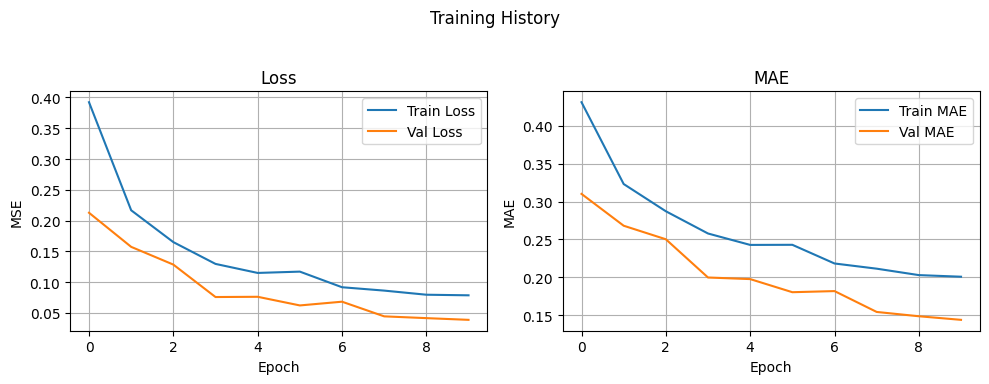


--- Performance Evaluation on Validation Set ---
832/832 [==============================] - 9s 10ms/step
Average R2 Score (Rescaled): 0.962
Average CC Score (Rescaled): 0.982


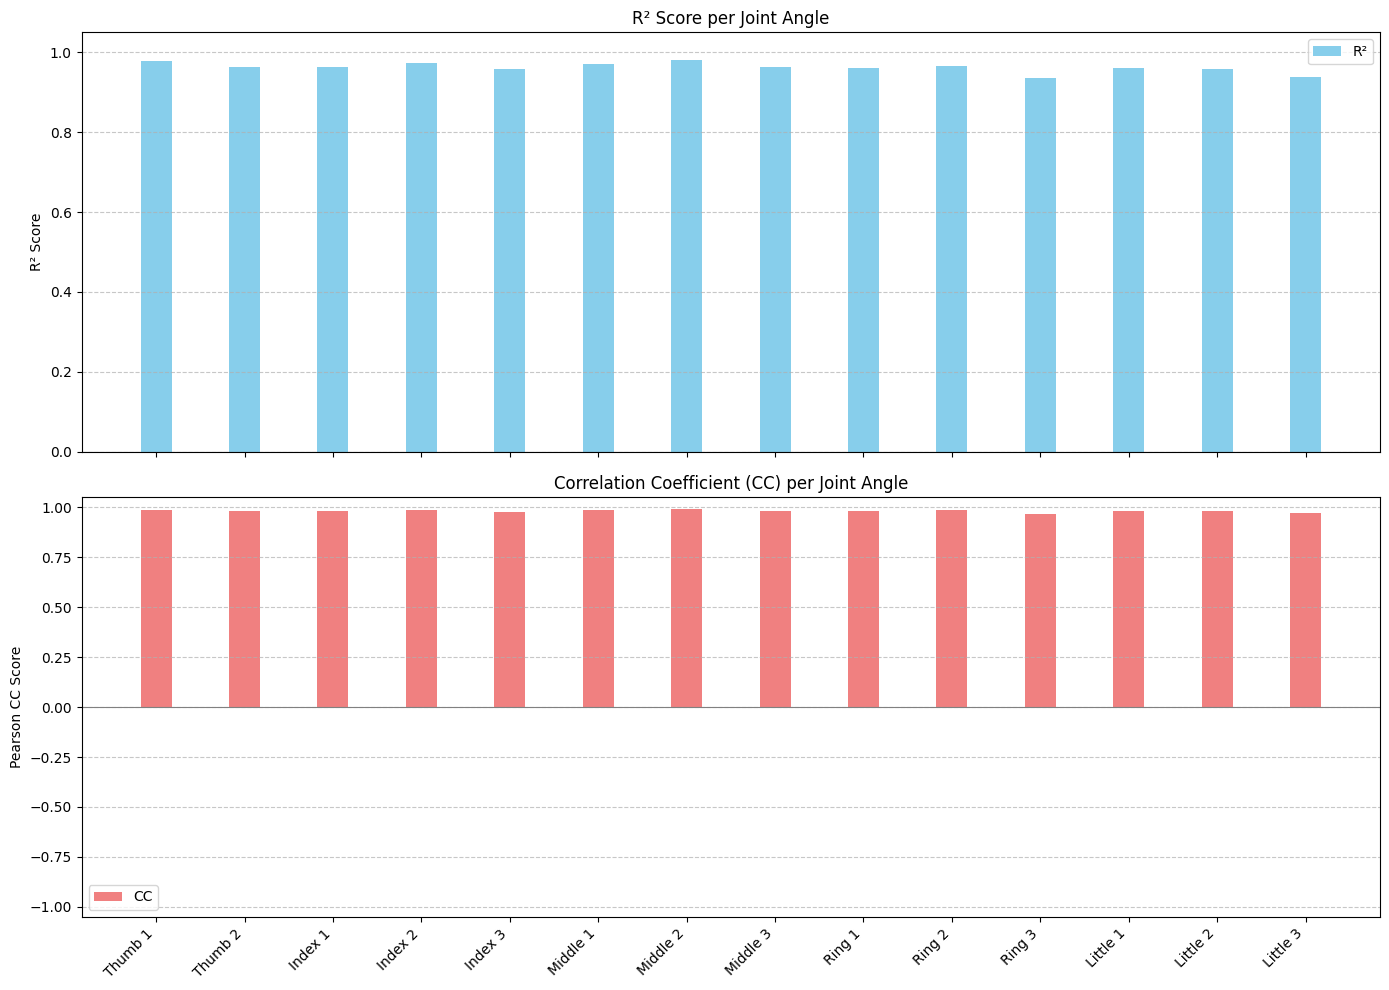

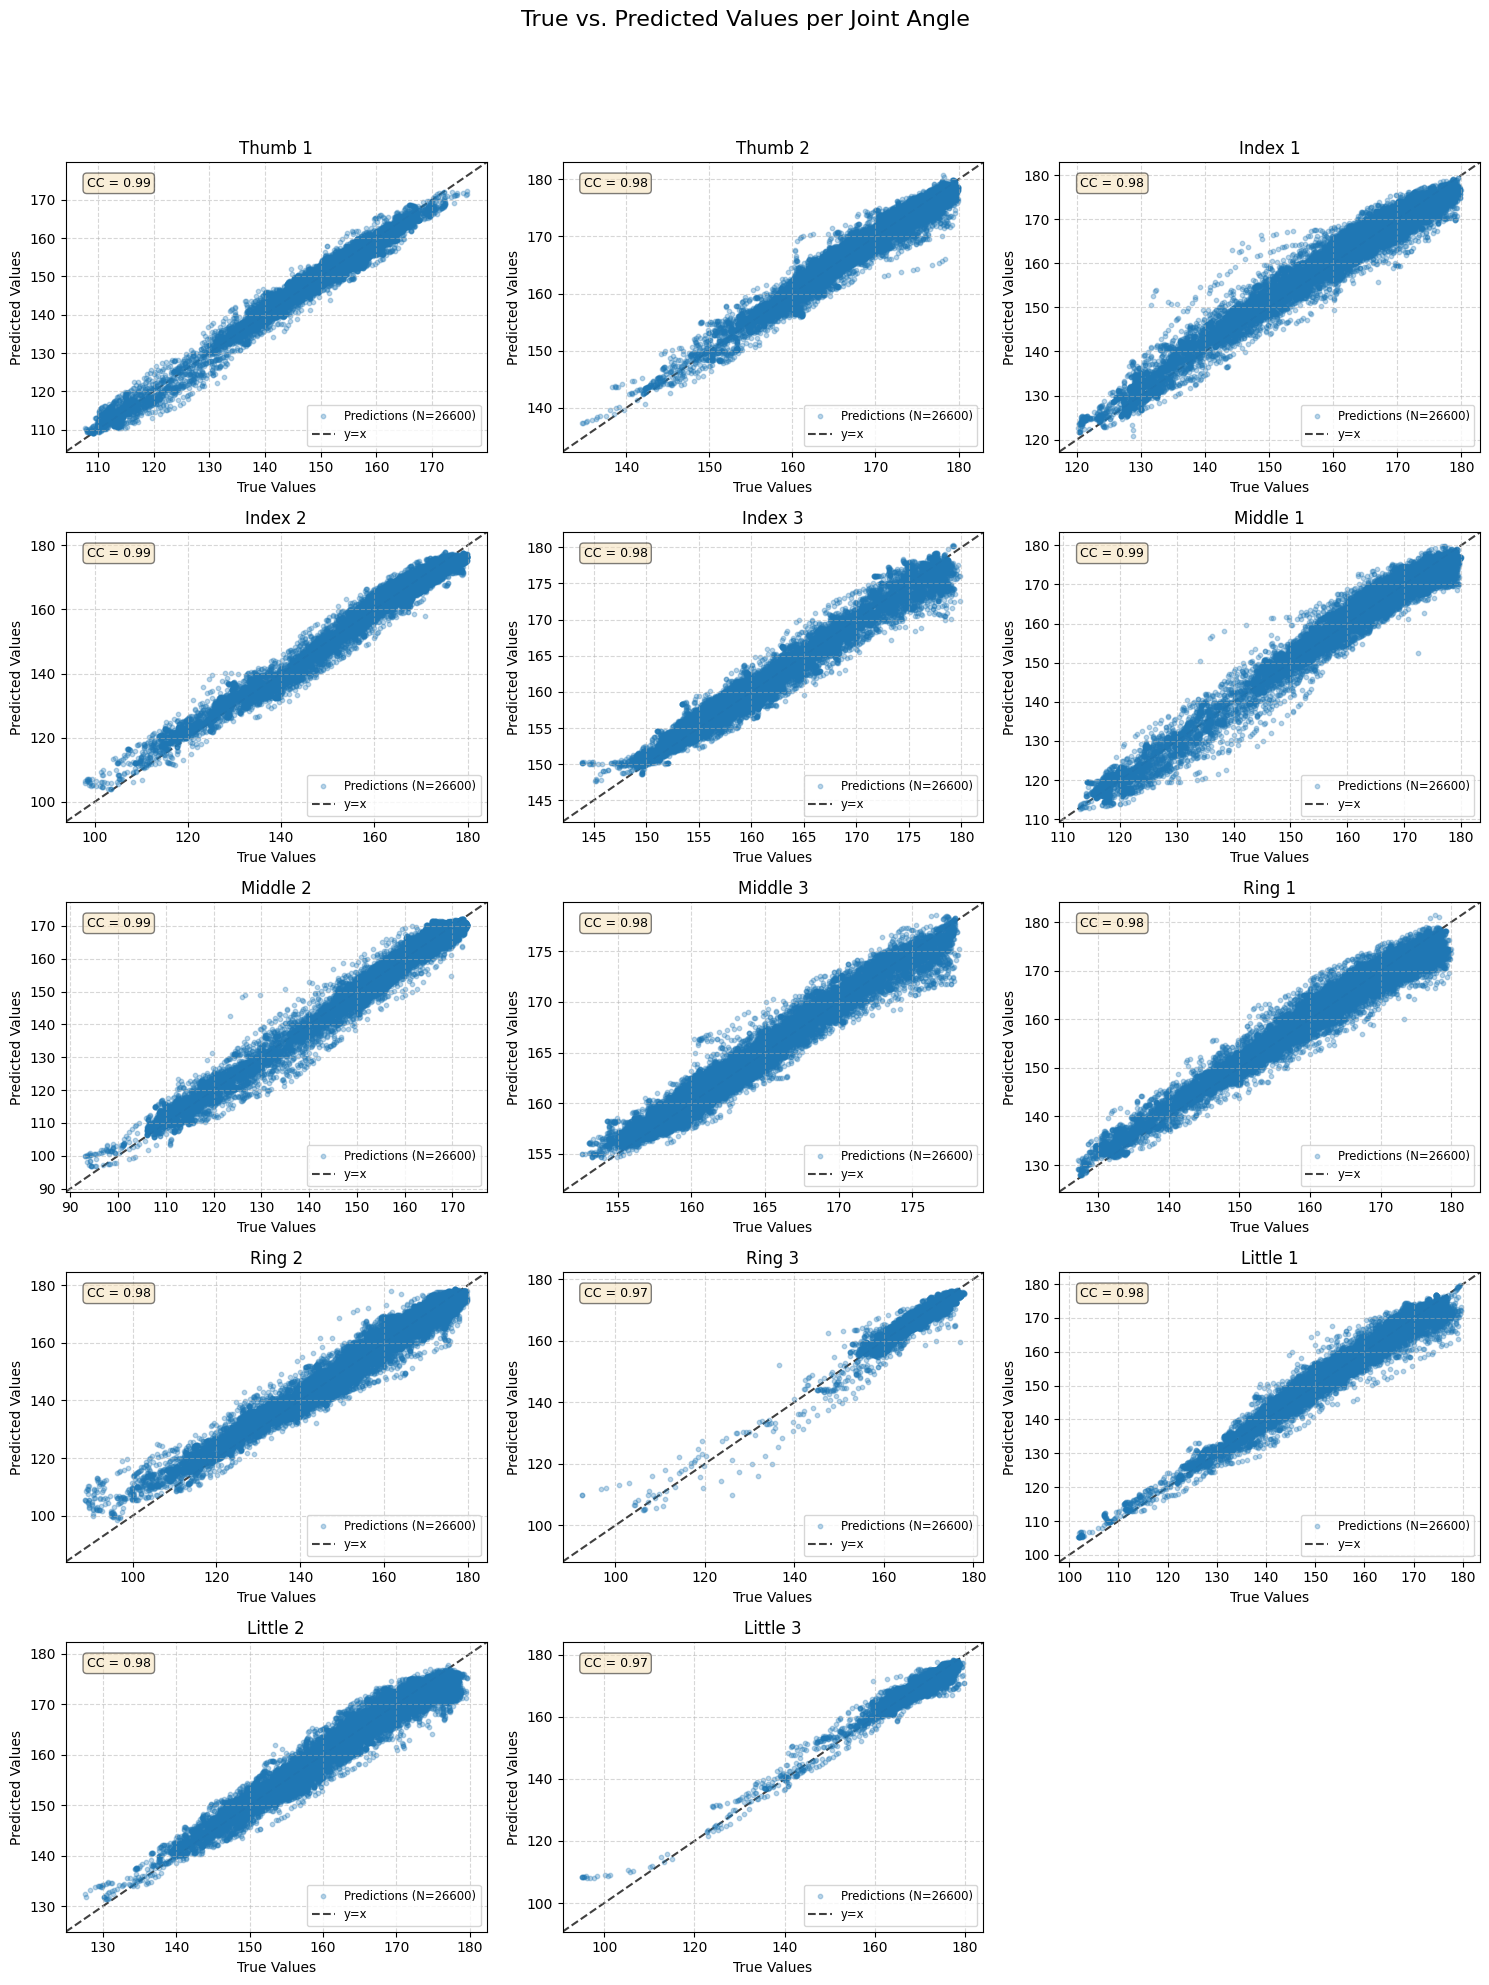


--- Detailed MHA Attention Visualization (Sample Windows) ---
Visualizing MHA attention heatmaps for the first 2 validation sample windows...

--- Visualizing MHA Attention Heatmap for Validation Sample Index 0 ---


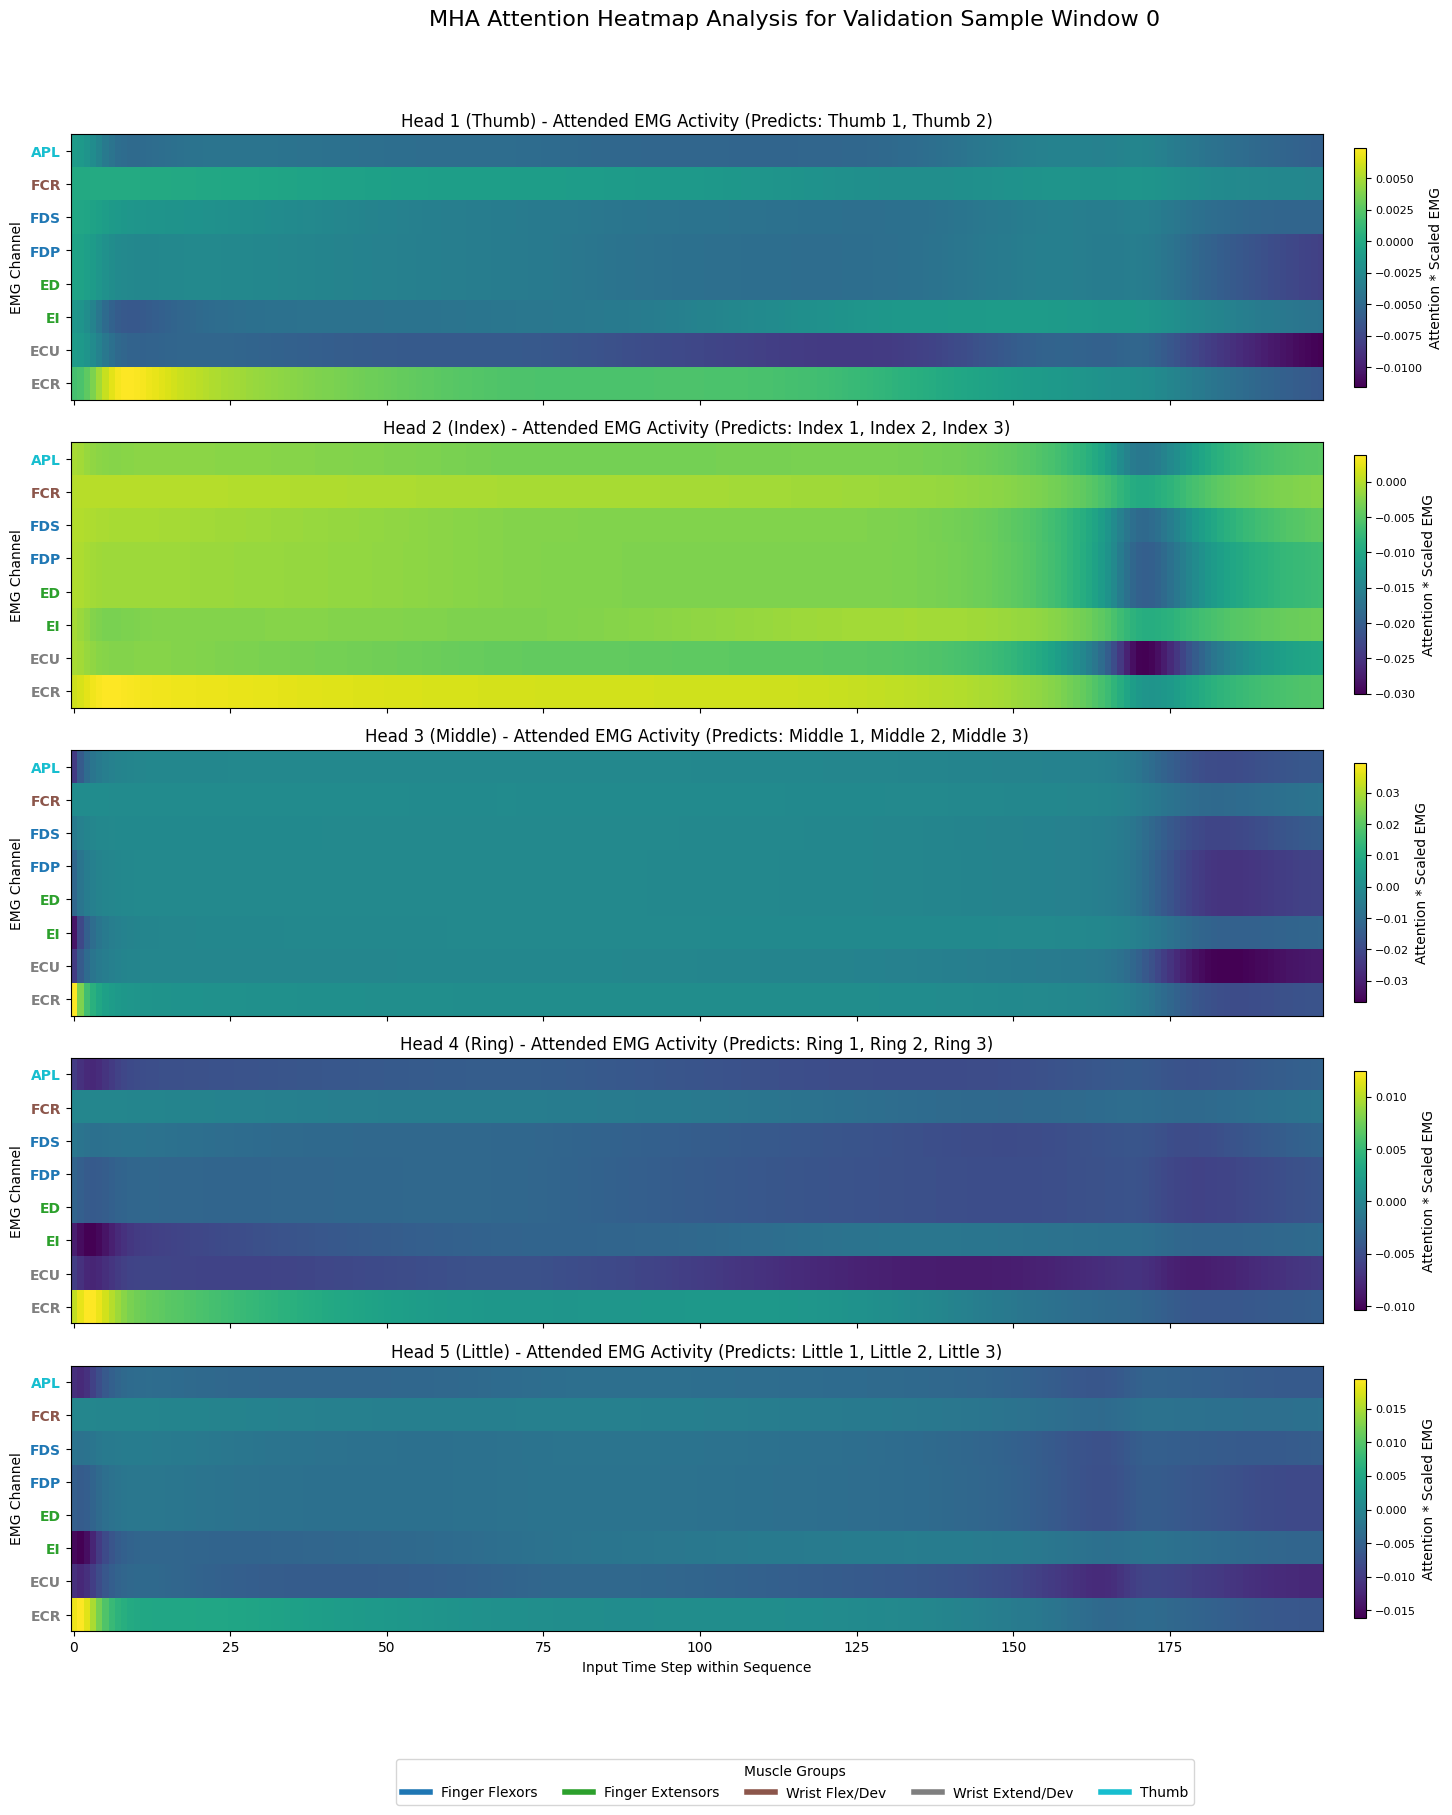


--- Visualizing MHA Attention Heatmap for Validation Sample Index 1 ---


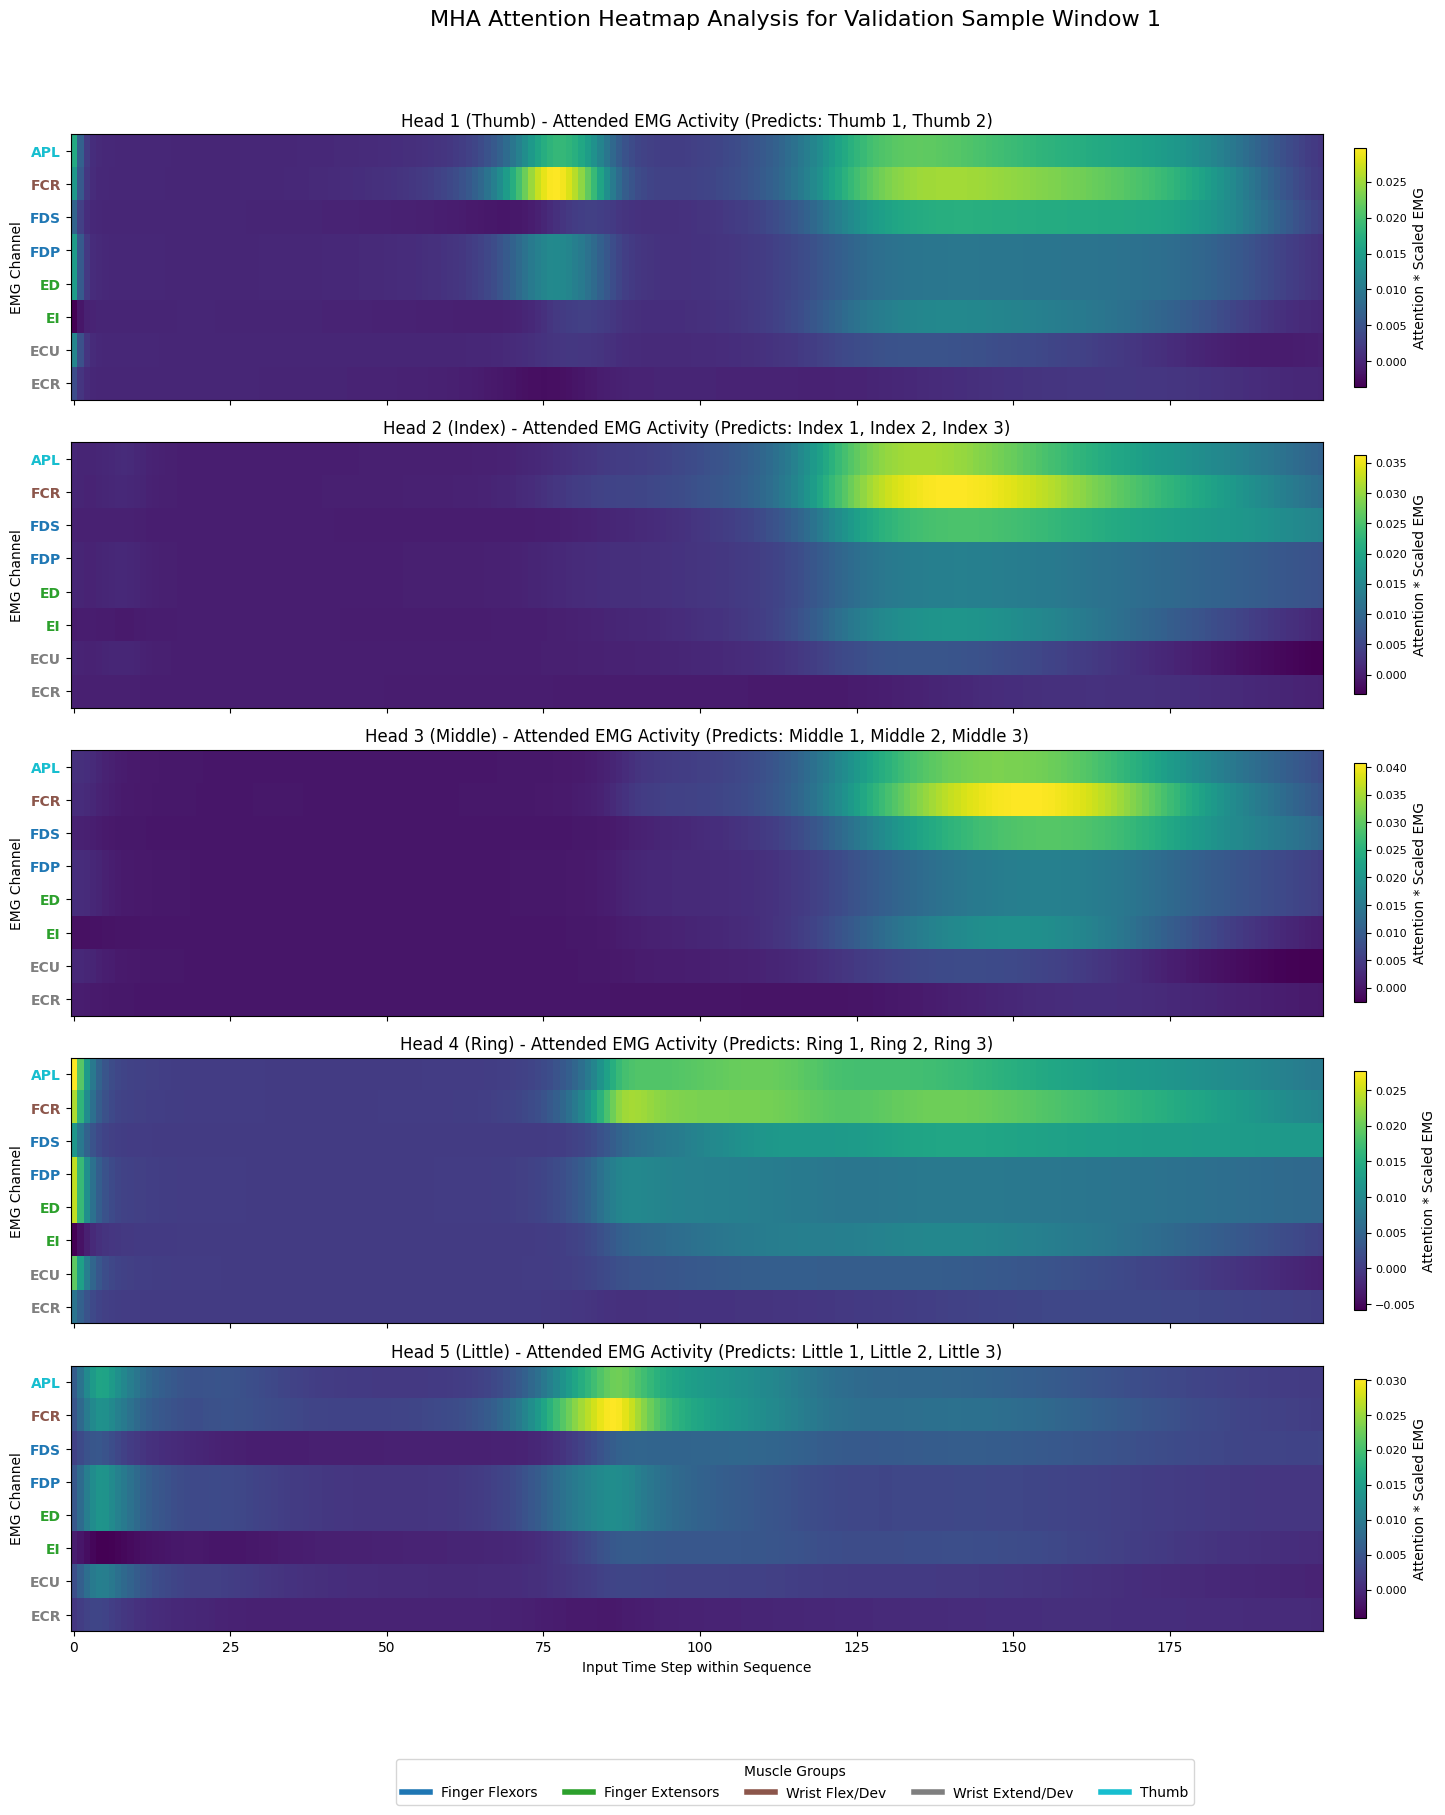

Getting attention weights for all validation samples (for summary)...

--- Dynamic Trial Simulation Visualization (EMG/Angle/Attention) ---
Visualizing dynamics simulation for the first 1 original trials...

--- Plotting Dynamics Simulation for Trial: T1_Task1 with Attention Highlighting ---
Running model prediction for simulation...
Identified 212 high attention periods (above 75th percentile: 0.005)
Peak mean attention occurs at window index: 17


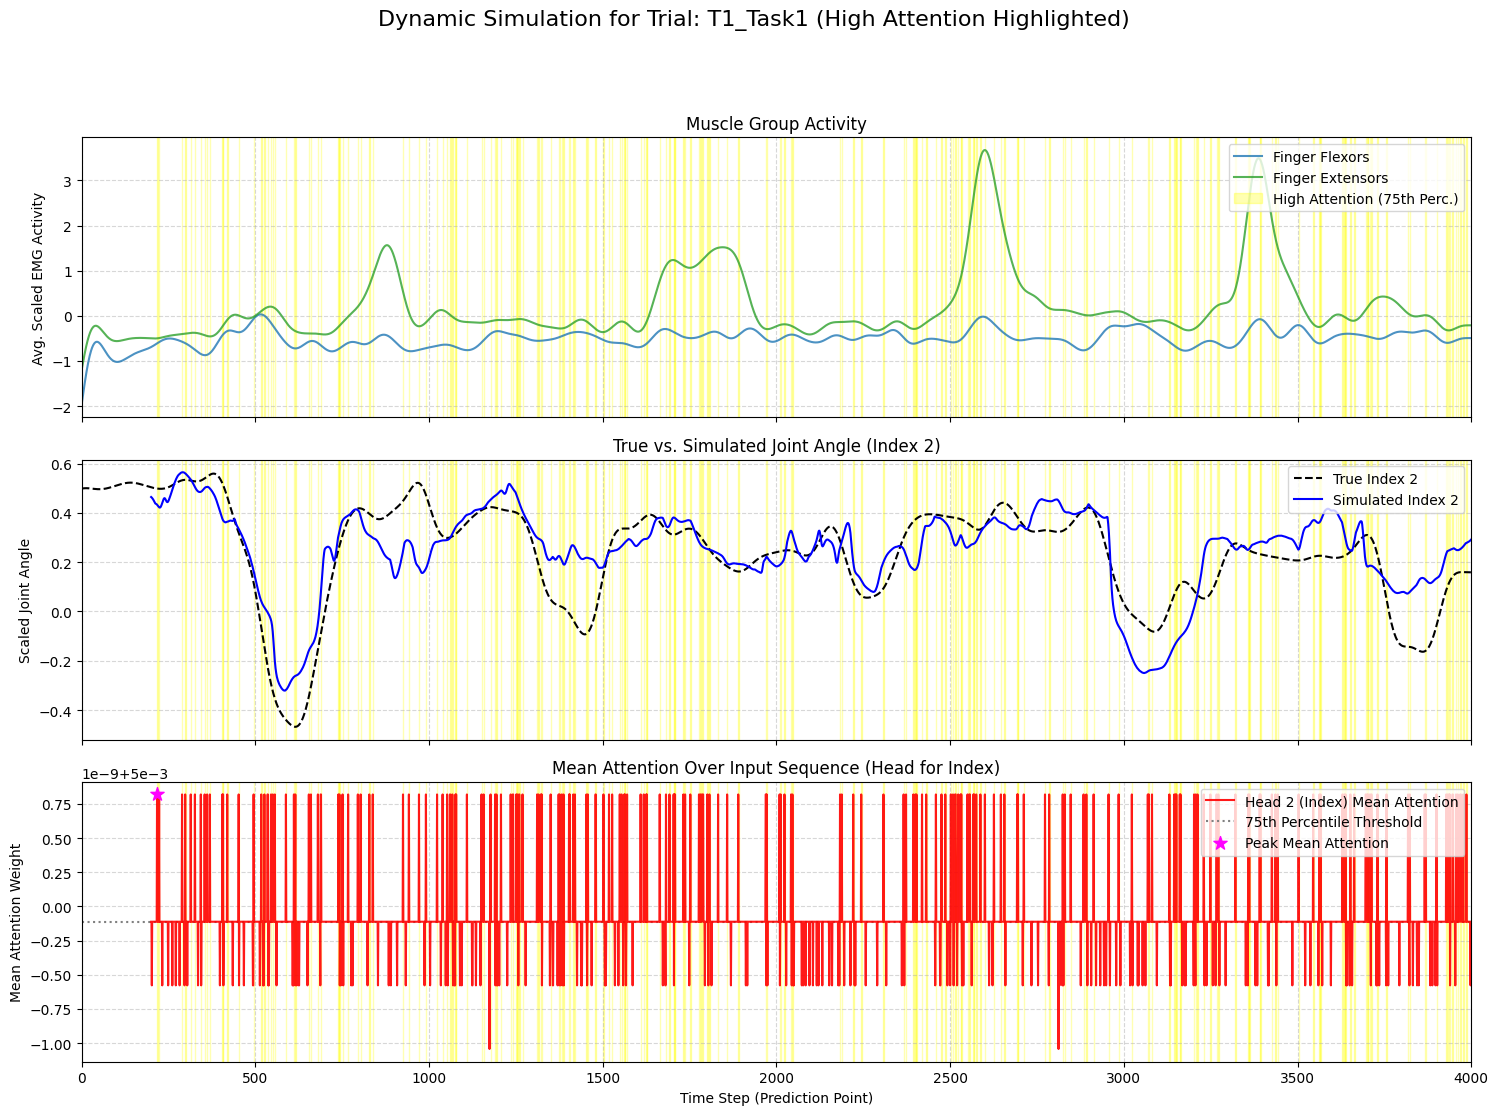


--- Integrated Gradients XAI Visualization ---
Calculating Integrated Gradients for the first 2 validation sample(s)...

--- Explaining Validation Sample Index 0 with Integrated Gradients ---
Explaining prediction for: Index 2 (Index 3)


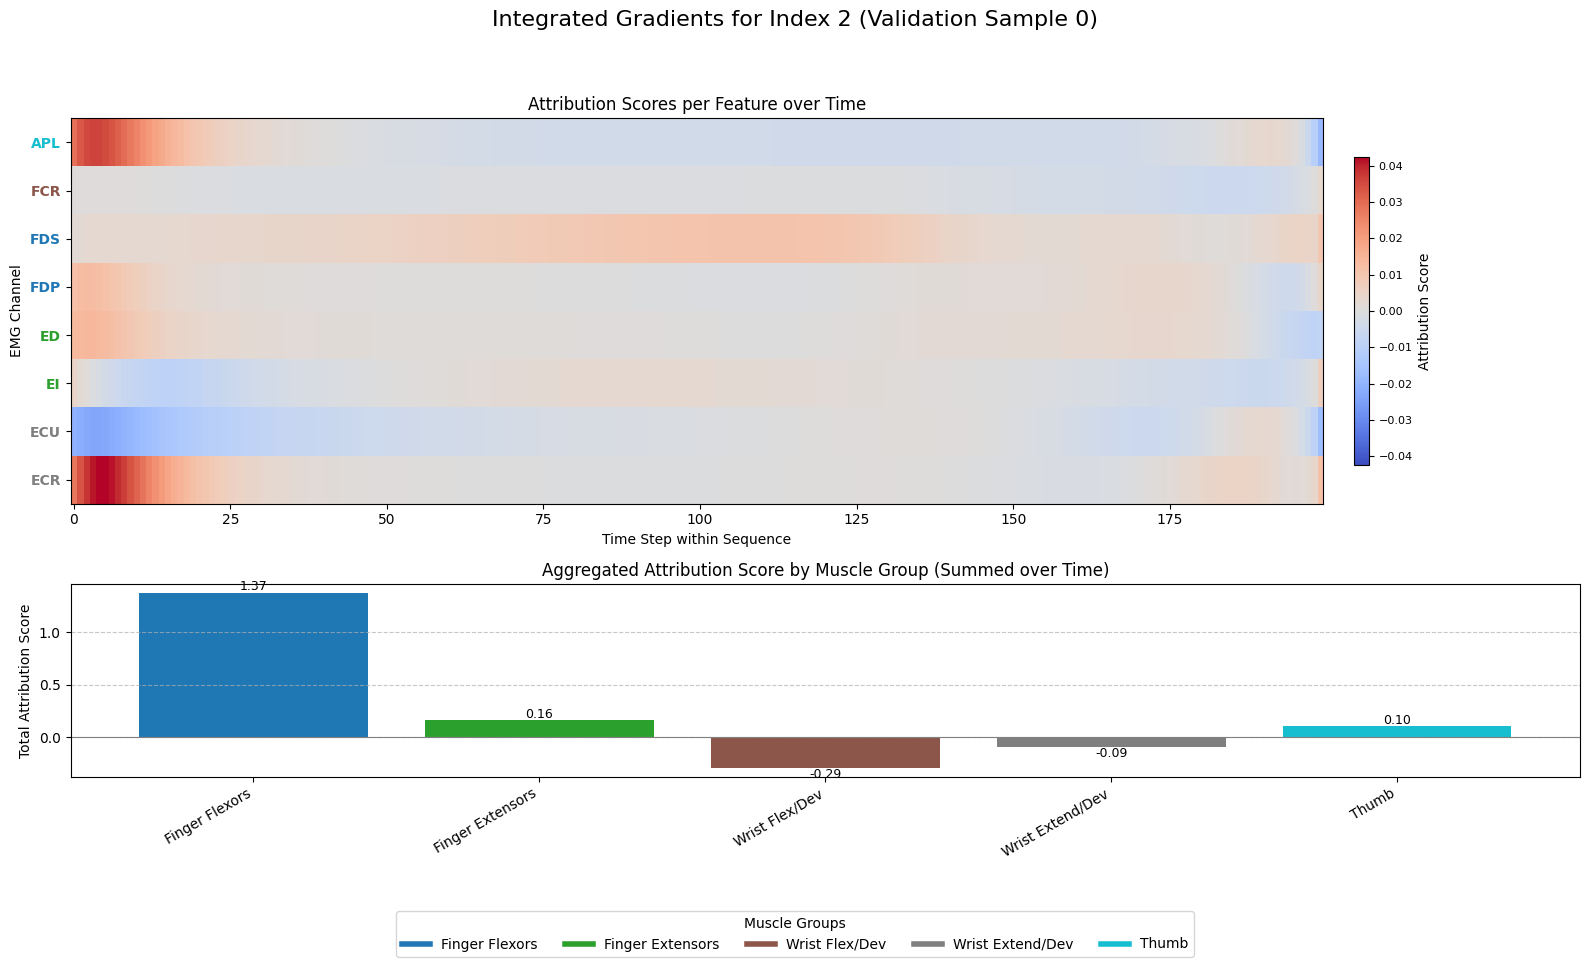


--- Explaining Validation Sample Index 1 with Integrated Gradients ---
Explaining prediction for: Index 2 (Index 3)


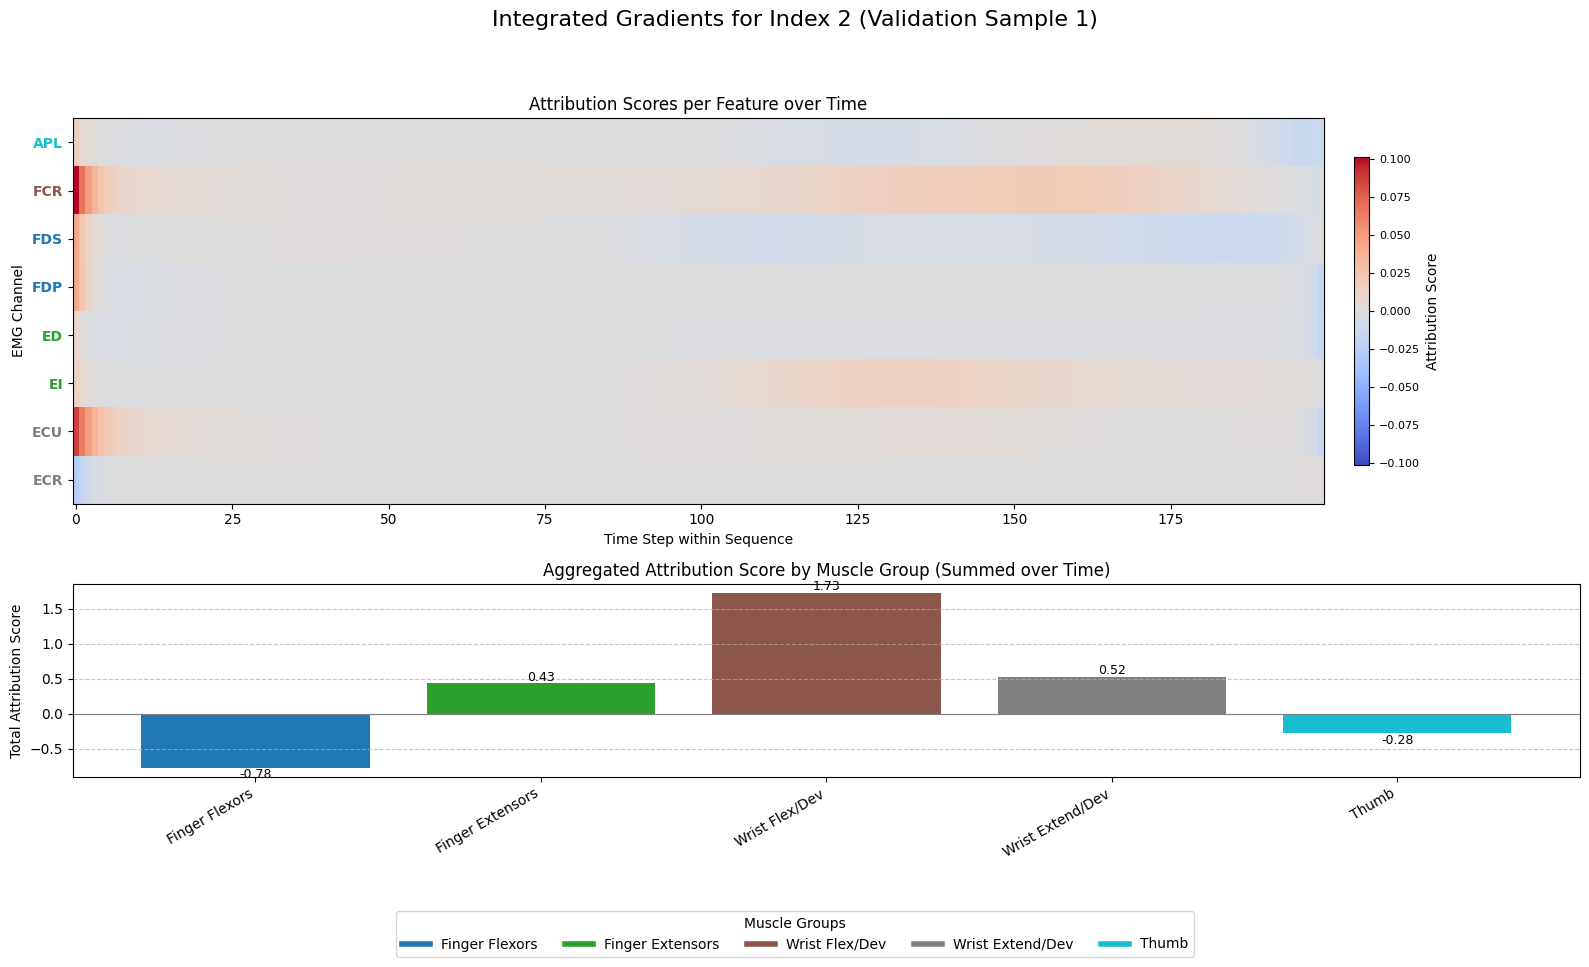


--- SHAP XAI Visualization ---
Calculating SHAP values using 50 background samples from X_train...
Explaining the first 2 validation samples...
Explaining prediction for: Index 2 (Index 3)

--- Calculating SHAP values for target angle index: 3 ---
Error during SHAP calculation: <class 'function'> is not currently a supported model type!
Skipping SHAP visualization due to calculation error.

--- EMG Activation vs. Angle Relationship Visualization ---

--- Plotting EMG vs Angle Relationship for FDS and Index 2 ---


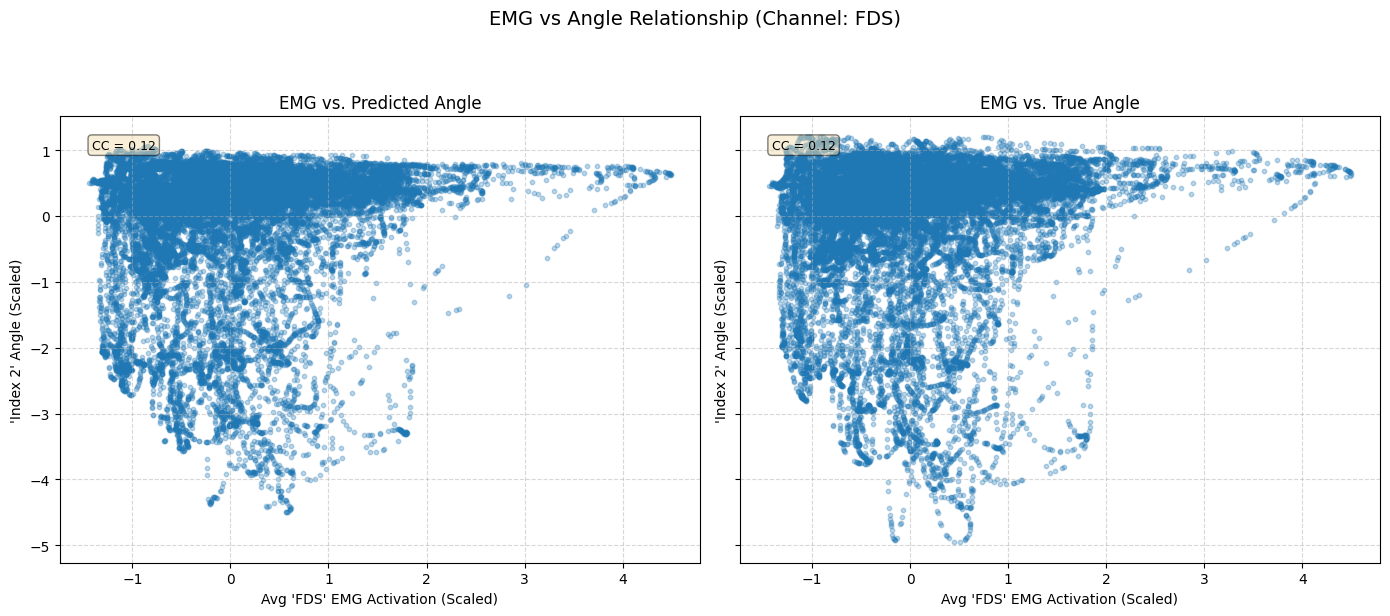


--- Plotting EMG vs Angle Relationship for Finger Flexors and Index 2 ---


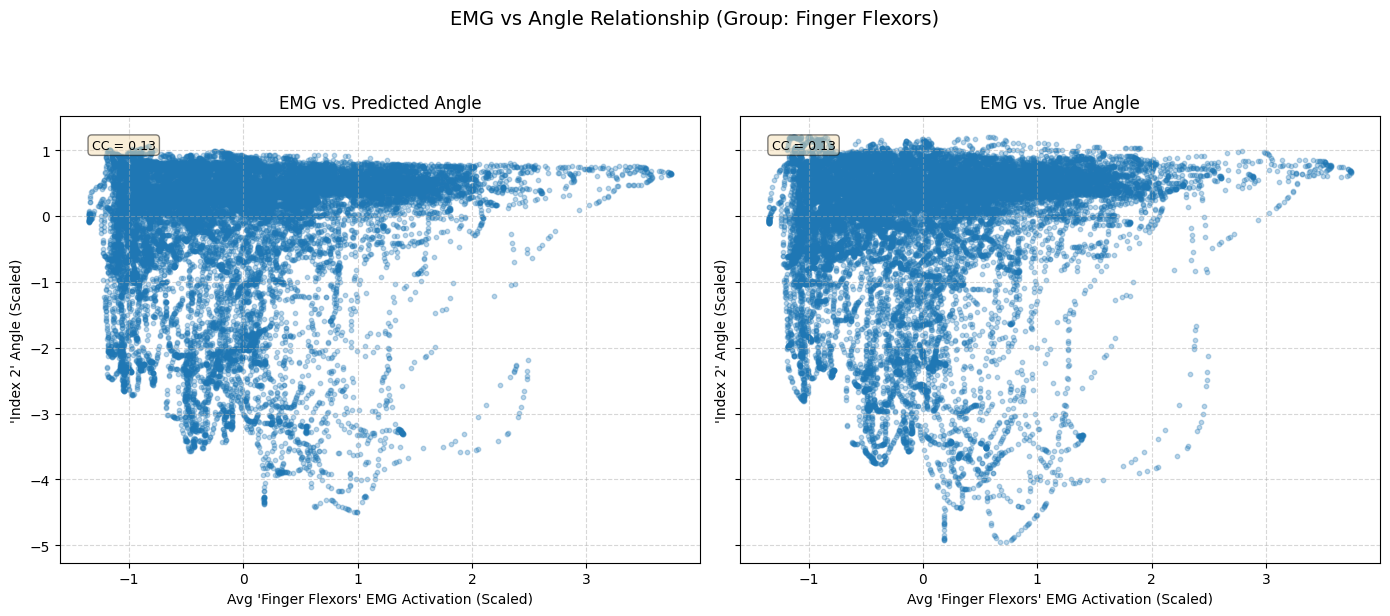


--- MHA Attention Contribution Summary Table ---
Average attention weight magnitude per head (averaged over time and samples):
Finger (Head)  Avg. Attention Weight
        Thumb                  0.005
        Index                  0.005
       Middle                  0.005
         Ring                  0.005
       Little                  0.005

Note: The table above shows the overall average attention weight magnitude per head.
The MHA heatmaps provide a more detailed view of attention distribution over time.

--- Attention-Weighted EMG Snapshot Visualization ---

--- Plotting Attention-Weighted EMG Snapshot for T1_Task1, Window 17, Head 'Index' ---


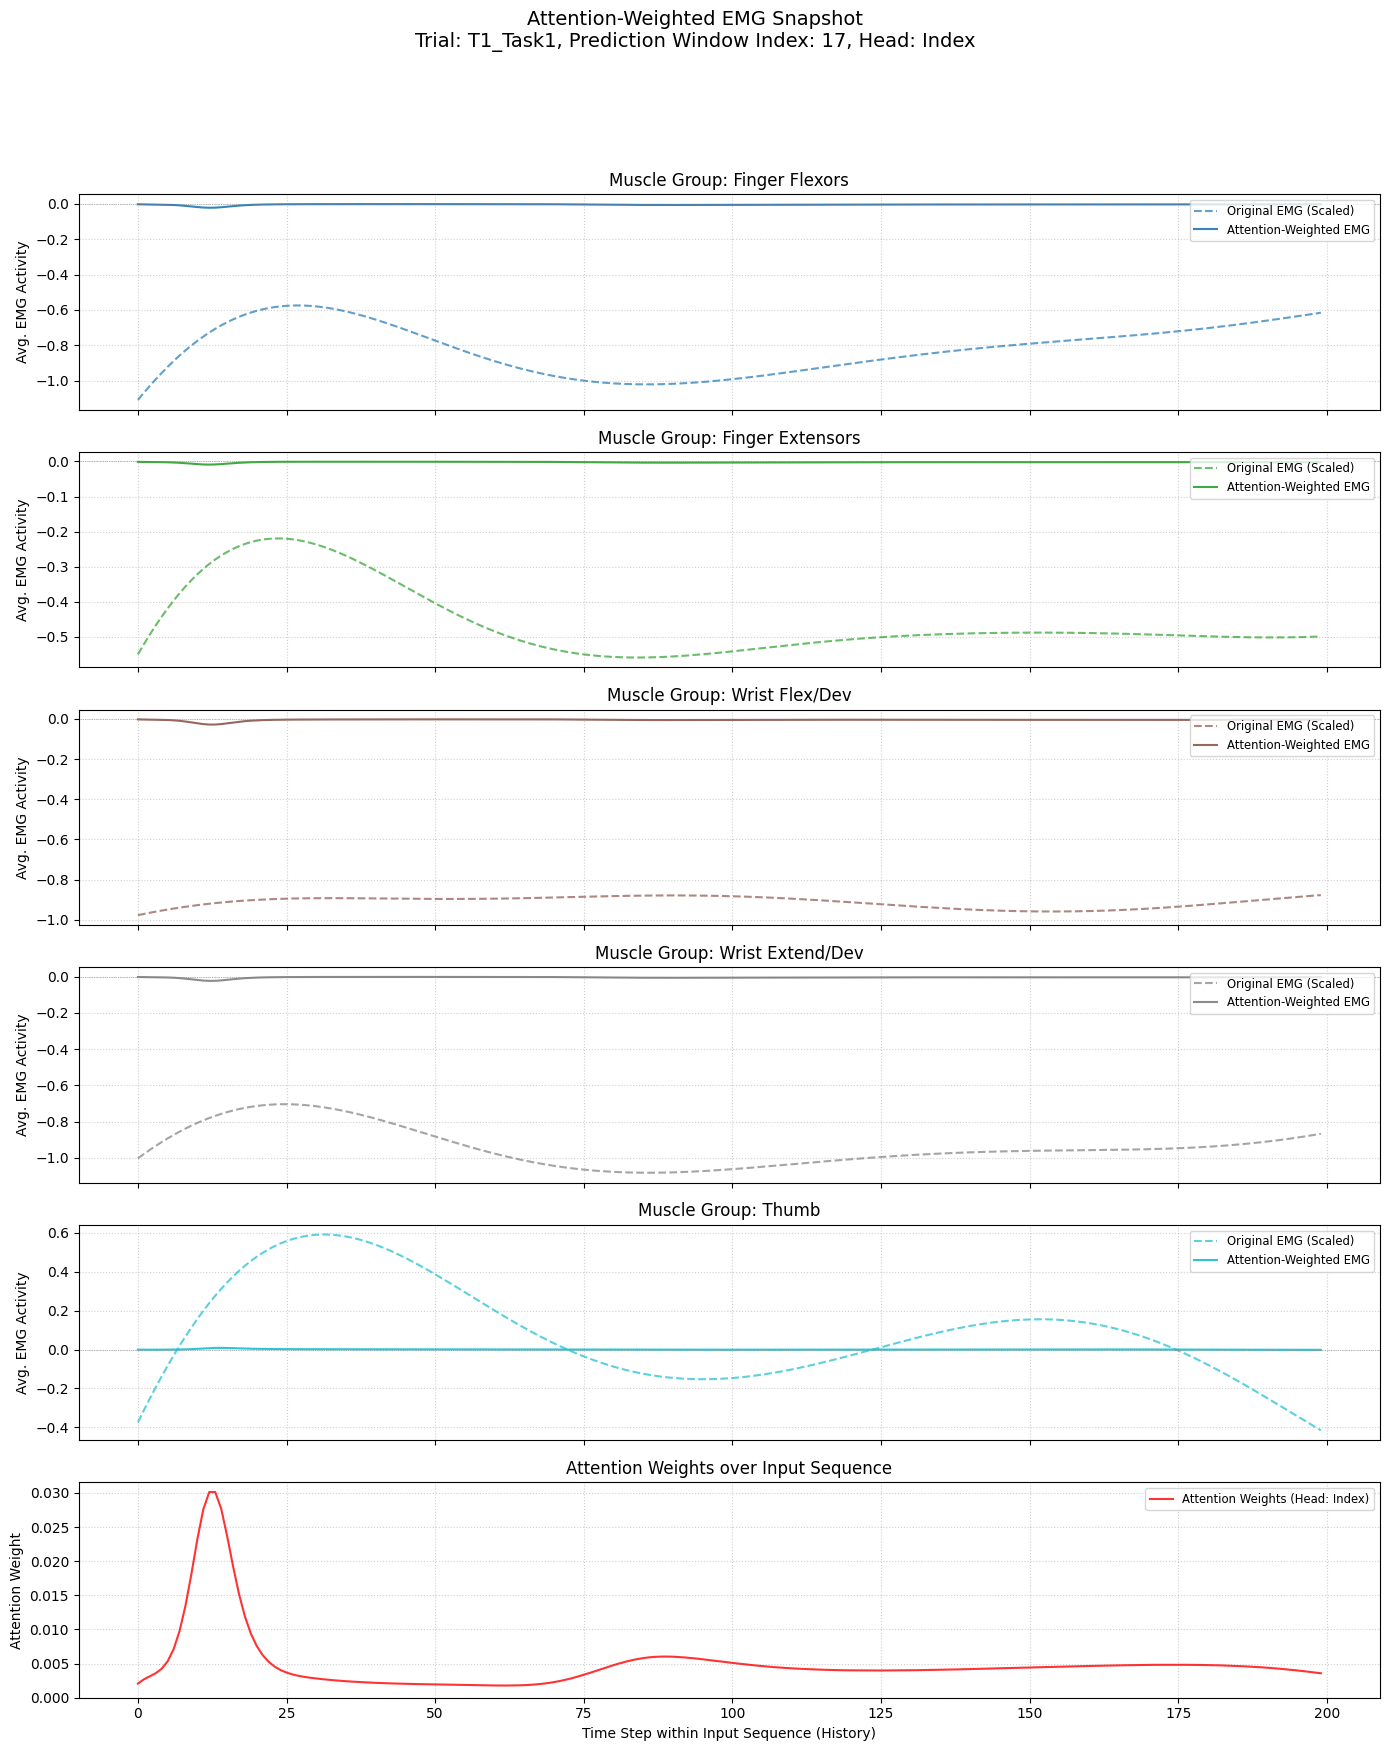


--- Script Execution Finished ---


In [4]:
# -*- coding: utf-8 -*-
"""
Python script for predicting finger kinematics from EMG using a
Multi-Head Attention (MHA) LSTM model with specific EMG preprocessing,
Integrated Gradients, SHAP for XAI, and additional insight visualizations.

Includes:
- Custom MHA model with separate finger heads.
- R2/CC score plotting.
- Regression correlation scatter plots.
- MHA Attention Heatmap visualization (per head, normalized).
- Dynamic Simulation plot (EMG/True Angle/Predicted Angle/Attention)
  with highlighting based on attention levels. <- MODIFIED to return peak attn idx
- Integrated Gradients calculation and visualization.
- SHAP value calculation and visualization.
- EMG Activation vs. Predicted Angle scatter plots.
- MHA Attention Contribution Summary Table.
- Attention-Weighted EMG Snapshot plot (NEW Section 12). <- NEW

Requires: tensorflow, numpy, scipy, matplotlib, scikit-learn, pandas, shap
Install missing libraries: pip install tensorflow numpy scipy matplotlib scikit-learn pandas shap
"""

import numpy as np
import scipy.io
import scipy.stats
# Removed: from scipy.signal import butter, sosfiltfilt # For filtering
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Layer, Dropout, Lambda, LayerNormalization, MultiHeadAttention,
    Concatenate
)
from tensorflow.keras import backend as K
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # Using StandardScaler for consistency
from sklearn.metrics import r2_score
import os
import warnings
import math
import pandas as pd # Added for table summary
import shap # Added for SHAP XAI

# --- Configuration ---
MAT_FILE_PATH = 's4_full.mat' # <<<--- Example path, UPDATE FOR YOUR ENVIRONMENT
SEQUENCE_LENGTH = 200
PREDICTION_HORIZON = 1 # Keep as 1 for current model structure
BATCH_SIZE = 128
EPOCHS = 10 # Adjust as needed (increase for better performance)
LSTM_UNITS = 128
VALIDATION_SPLIT = 0.2
MAX_SAMPLES_TO_VIZ_MHA = 2 # Limit detailed MHA heatmap visualization output
NUM_TRIALS_TO_PLOT_DYNAMICS = 1 # Limit dynamic plot output
NUM_SAMPLES_FOR_XAI = 2 # How many samples to run XAI (IG & SHAP) on
MAX_SAMPLES_TO_VIZ = 2 # Limit detailed visualization output (used by MHA, IG, SHAP, EMG-Angle plots)
NUM_SHAP_BACKGROUND_SAMPLES = 50 # Number of background samples for SHAP explainer
ATTENTION_HIGHLIGHT_THRESHOLD_PERCENTILE = 75 # Percentile for highlighting high attention
PLOT_ATTN_WEIGHTED_SNAPSHOT = True # Flag to enable the new plot

# MHA Configuration
NUM_ATTENTION_HEADS = 5
D_MODEL = LSTM_UNITS
if D_MODEL % NUM_ATTENTION_HEADS != 0:
     D_MODEL = math.ceil(D_MODEL / NUM_ATTENTION_HEADS) * NUM_ATTENTION_HEADS
     print(f"Adjusting D_MODEL to {D_MODEL} to be divisible by {NUM_ATTENTION_HEADS} heads.")

# Integrated Gradients Config
IG_STEPS = 50 # Number of steps for approximation

# EMG Channel Names (Ensure this matches your .mat file)
EMG_CHANNEL_NAMES = ['APL', 'FCR', 'FDS', 'FDP', 'ED', 'EI', 'ECU', 'ECR']
# Joint Angle Names (Ensure this matches your .mat file)
JOINT_ANGLE_NAMES = [
    'Thumb 1', 'Thumb 2', 'Index 1', 'Index 2', 'Index 3', 'Middle 1', 'Middle 2', 'Middle 3',
    'Ring 1', 'Ring 2', 'Ring 3', 'Little 1', 'Little 2', 'Little 3'
]
# Finger to Joint Mapping (Ensure this matches your angle setup)
FINGER_JOINT_INDICES = {
    'Thumb': list(range(0, 2)), 'Index': list(range(2, 5)), 'Middle': list(range(5, 8)),
    'Ring': list(range(8, 11)), 'Little': list(range(11, 14))
}
FINGER_NAMES = list(FINGER_JOINT_INDICES.keys())

# --- Muscle Group Definitions ---
MUSCLE_GROUPS = {
    'Finger Flexors': [EMG_CHANNEL_NAMES.index(name) for name in ['FDS', 'FDP'] if name in EMG_CHANNEL_NAMES],
    'Finger Extensors': [EMG_CHANNEL_NAMES.index(name) for name in ['ED', 'EI'] if name in EMG_CHANNEL_NAMES],
    'Wrist Flex/Dev': [EMG_CHANNEL_NAMES.index(name) for name in ['FCR'] if name in EMG_CHANNEL_NAMES],
    'Wrist Extend/Dev': [EMG_CHANNEL_NAMES.index(name) for name in ['ECU', 'ECR'] if name in EMG_CHANNEL_NAMES],
    'Thumb': [EMG_CHANNEL_NAMES.index(name) for name in ['APL'] if name in EMG_CHANNEL_NAMES]
}
# Assign colors
try: cmap = plt.colormaps.get_cmap('tab10')
except AttributeError: cmap = plt.cm.get_cmap('tab10')
GROUP_COLORS = cmap(np.linspace(0, 1, len(MUSCLE_GROUPS)))
MUSCLE_GROUP_VIS_INFO = {name: {'indices': indices, 'color': GROUP_COLORS[i]}
                         for i, (name, indices) in enumerate(MUSCLE_GROUPS.items()) if indices} # Only include groups with found channels
print("Defined Muscle Groups (Indices):", MUSCLE_GROUPS)

# --- Custom Multi-Head Attention Layer ---
# (Definition remains the same)
class CustomMultiHeadAttentionSeparateOutput(Layer):
    """ Custom MHA layer returning separate context vectors per head. """
    def __init__(self, num_heads, d_model, **kwargs):
        super().__init__(**kwargs)
        if d_model % num_heads != 0: raise ValueError(f"d_model ({d_model}) must be divisible by num_heads ({num_heads})")
        self.num_heads = num_heads; self.d_model = d_model; self.depth = d_model // num_heads
        self.wq = Dense(d_model, name='q_proj'); self.wk = Dense(d_model, name='k_proj'); self.wv = Dense(d_model, name='v_proj')

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def scaled_dot_product_attention(self, q, k, v, mask=None):
        matmul_qk = tf.matmul(q, k, transpose_b=True)
        dk = tf.cast(tf.shape(k)[-1], tf.float32)
        scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)
        if mask is not None: scaled_attention_logits += (mask * -1e9)
        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
        output = tf.matmul(attention_weights, v)
        return output, attention_weights

    def call(self, query, value, key, mask=None, return_attention_scores=False):
        batch_size = tf.shape(query)[0]
        q = self.wq(query); k = self.wk(key); v = self.wv(value)
        q = self.split_heads(q, batch_size); k = self.split_heads(k, batch_size); v = self.split_heads(v, batch_size)
        scaled_attention, attention_weights = self.scaled_dot_product_attention(q, k, v, mask)
        scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])
        # Output shape per head: (batch_size, query_seq_len, depth)
        head_outputs = [scaled_attention[:, :, i, :] for i in range(self.num_heads)]
        # Squeeze if query_seq_len is 1 (as in this model's decoder-like step)
        if query.shape[1] == 1: head_outputs_squeezed = [tf.squeeze(head, axis=1) for head in head_outputs]
        else: head_outputs_squeezed = head_outputs
        # Attention weights shape: (batch_size, num_heads, query_seq_len, key_seq_len)
        # Squeeze if query_seq_len is 1
        if query.shape[1] == 1: squeezed_attention_weights = tf.squeeze(attention_weights, axis=2)
        else: squeezed_attention_weights = attention_weights # Should not happen here

        if return_attention_scores: return head_outputs_squeezed, squeezed_attention_weights
        else: return head_outputs_squeezed

    def get_config(self):
        config = super().get_config()
        config.update({'num_heads': self.num_heads, 'd_model': self.d_model})
        return config

# --- 1. Data Loading ---
# (Definition remains the same)
def load_mat_data(filepath):
    """Loads EMG and joint angle data from the specified .mat file."""
    print(f"Loading data from: {filepath}")
    if not os.path.exists(filepath): print(f"Error: File not found at {filepath}"); return None, None, None
    try:
        mat_data = scipy.io.loadmat(filepath)
        # Adjust keys based on your actual .mat file structure if needed
        emg_data_cells = mat_data.get('dsfilt_emg', mat_data.get('emg_data'))
        joint_angles_cells = mat_data.get('joint_angles', mat_data.get('angle_data'))
        kinematics_data = mat_data.get('finger_kinematics', None) # Optional
        if emg_data_cells is None or joint_angles_cells is None:
             raise ValueError("Could not find 'dsfilt_emg'/'emg_data' or 'joint_angles'/'angle_data' keys in MAT file.")
        print("Data loaded successfully.")
        return emg_data_cells, joint_angles_cells, kinematics_data
    except Exception as e: print(f"An error occurred during loading: {e}"); return None, None, None

# --- 2. Data Preprocessing ---
# (Definition remains the same - No filtering)
def preprocess_data(emg_data_cells, joint_angles_cells, sequence_length, prediction_horizon):
    """ Preprocesses data: flattens, creates sequences, normalizes, splits. (No filtering) """
    print("Preprocessing data (No explicit filtering)...")
    all_emg_sequences, all_angle_targets = [], []
    original_scaled_trials = []
    num_trials, num_tasks = emg_data_cells.shape
    emg_scaler, angle_scaler = StandardScaler(), StandardScaler()
    temp_emg_list, temp_angle_list = [], []

    # --- Fit scalers first (on raw data) ---
    print("Fitting scalers...")
    emg_list_for_scaling = []
    angle_list_for_scaling = []
    valid_trial_count = 0
    for i in range(num_trials):
        for j in range(num_tasks):
            # Check if data exists and is numpy array
            emg_trial = emg_data_cells[i, j]
            angle_trial = joint_angles_cells[i, j]
            if isinstance(emg_trial, np.ndarray) and emg_trial.ndim == 2 and emg_trial.shape[0] > 0 and \
               isinstance(angle_trial, np.ndarray) and angle_trial.ndim == 2 and angle_trial.shape[0] > 0:
                # Ensure consistent number of channels/angles
                if emg_trial.shape[1] != len(EMG_CHANNEL_NAMES):
                    # print(f"Warning: Trial T{i+1}_Task{j+1} EMG channel mismatch ({emg_trial.shape[1]} vs {len(EMG_CHANNEL_NAMES)} expected). Skipping.")
                    continue
                if angle_trial.shape[1] != len(JOINT_ANGLE_NAMES):
                     # print(f"Warning: Trial T{i+1}_Task{j+1} Angle mismatch ({angle_trial.shape[1]} vs {len(JOINT_ANGLE_NAMES)} expected). Skipping.")
                     continue

                min_len = min(emg_trial.shape[0], angle_trial.shape[0])
                if min_len >= sequence_length + prediction_horizon:
                    trial_emg = emg_trial[:min_len, :] # Use raw EMG
                    trial_angle = angle_trial[:min_len, :]
                    # --- Filtering Removed ---
                    emg_list_for_scaling.append(trial_emg) # Append raw EMG
                    angle_list_for_scaling.append(trial_angle)
                    valid_trial_count += 1
                # else: print(f"Info: Trial T{i+1}_Task{j+1} too short ({min_len} steps). Skipping.") # Optional: uncomment for details
            # else: print(f"Info: Invalid data type or empty array for Trial T{i+1}_Task{j+1}. Skipping.") # Optional: uncomment for details


    if not emg_list_for_scaling: print("Error: No valid data/trials long enough found."); return None, None, None, None, None, None, None
    full_emg_data = np.vstack(emg_list_for_scaling); full_angle_data = np.vstack(angle_list_for_scaling)
    if np.any(np.isnan(full_emg_data)) or np.any(np.isinf(full_emg_data)) or \
       np.any(np.isnan(full_angle_data)) or np.any(np.isinf(full_angle_data)): raise ValueError("NaN or Inf detected in data before scaling.")
    emg_scaler.fit(full_emg_data); angle_scaler.fit(full_angle_data); print("Scalers fitted.")

    # --- Create sequences and store original scaled trials ---
    print(f"Creating sequences from {valid_trial_count} valid trials...")
    trial_count = 0
    # Store mapping from sequence index to trial/window info
    sequence_metadata = []
    global_sequence_idx = 0

    for i in range(num_trials):
        for j in range(num_tasks):
             emg_trial = emg_data_cells[i, j]
             angle_trial = joint_angles_cells[i, j]
             if isinstance(emg_trial, np.ndarray) and emg_trial.ndim == 2 and emg_trial.shape[0] > 0 and \
               isinstance(angle_trial, np.ndarray) and angle_trial.ndim == 2 and angle_trial.shape[0] > 0 and \
               emg_trial.shape[1] == len(EMG_CHANNEL_NAMES) and angle_trial.shape[1] == len(JOINT_ANGLE_NAMES): # Re-check validity

                min_len = min(emg_trial.shape[0], angle_trial.shape[0])
                if min_len >= sequence_length + prediction_horizon:
                    trial_id_str = f"T{i+1}_Task{j+1}"
                    trial_emg = emg_trial[:min_len, :] # Raw EMG
                    trial_angle = angle_trial[:min_len, :]
                    # --- Filtering Removed ---
                    # Scale the full raw trial
                    trial_emg_scaled = emg_scaler.transform(trial_emg) # Scale raw EMG
                    trial_angle_scaled = angle_scaler.transform(trial_angle)
                    original_scaled_trials.append({'emg': trial_emg_scaled, 'angle': trial_angle_scaled, 'id': trial_id_str})
                    # Create sequences from this scaled trial
                    num_windows_in_trial = len(trial_emg_scaled) - sequence_length - prediction_horizon + 1
                    for k in range(num_windows_in_trial):
                        emg_sequence = trial_emg_scaled[k : k + sequence_length]
                        angle_target = trial_angle_scaled[k + sequence_length : k + sequence_length + prediction_horizon]
                        if prediction_horizon == 1: angle_target = angle_target.squeeze(axis=0) # Shape (num_angles,)
                        else: angle_target = angle_target.reshape(-1) # Flatten if horizon > 1 (adjust model output accordingly if needed)

                        # Check for NaNs/Infs in sequences/targets before adding
                        if not np.any(np.isnan(emg_sequence)) and not np.any(np.isinf(emg_sequence)) and \
                           not np.any(np.isnan(angle_target)) and not np.any(np.isinf(angle_target)):
                            all_emg_sequences.append(emg_sequence)
                            all_angle_targets.append(angle_target)
                            # Store metadata: global index, trial id, window start index k
                            sequence_metadata.append({'global_idx': global_sequence_idx, 'trial_id': trial_id_str, 'window_start_idx': k})
                            global_sequence_idx += 1
                        # else: print(f"Warning: NaN/Inf detected in sequence/target at {trial_id_str}, index {k}. Skipping sequence.")

                    trial_count += 1

    if not all_emg_sequences: print("Error: Could not create any valid sequences."); return None, None, None, None, None, None, None, None
    X = np.array(all_emg_sequences); y = np.array(all_angle_targets); print(f"Created {X.shape[0]} sequences from {trial_count} trials.")

    # Split data and metadata together
    indices = np.arange(X.shape[0])
    train_indices, val_indices, _, _ = train_test_split(indices, indices, test_size=VALIDATION_SPLIT, random_state=42, shuffle=True)

    X_train, X_val = X[train_indices], X[val_indices]
    y_train, y_val = y[train_indices], y[val_indices]
    train_metadata = [sequence_metadata[i] for i in train_indices]
    val_metadata = [sequence_metadata[i] for i in val_indices]


    print(f"Train size: {X_train.shape[0]}, Validation size: {X_val.shape[0]}")
    # Return metadata as well
    return X_train, X_val, y_train, y_val, emg_scaler, angle_scaler, original_scaled_trials, train_metadata, val_metadata


# --- 3. Model Architecture (MHA Redesign) ---
# (Definition remains the same)
def build_finger_mha_lstm(sequence_length, num_emg_features, num_angle_features,
                          lstm_units, d_model, num_heads, finger_joint_indices):
    """ Builds LSTM with Custom MHA and separate finger prediction heads. """
    print("Building MHA model...")
    if num_heads != len(finger_joint_indices): raise ValueError("Number of heads must match number of fingers defined.")
    encoder_inputs = Input(shape=(sequence_length, num_emg_features), name='emg_input')
    # Encoder LSTM processes the input sequence
    encoder_lstm = LSTM(lstm_units, return_sequences=True, return_state=True, name='encoder_lstm')
    if d_model != lstm_units: print(f"Warning: d_model({d_model}) != lstm_units({lstm_units}). Ensure consistency.")
    encoder_outputs, state_h, state_c = encoder_lstm(encoder_inputs) # outputs: (batch, seq, units), state_h/c: (batch, units)

    # Normalize LSTM outputs and state for stability before attention
    encoder_outputs_norm = LayerNormalization(epsilon=1e-6)(encoder_outputs)
    state_h_norm = LayerNormalization(epsilon=1e-6)(state_h)

    # Prepare query, key, value for MHA
    # Query: Use the final hidden state (represents summary of sequence) - needs expansion for seq dim
    query = Lambda(lambda x: tf.expand_dims(x, axis=1), name='expand_query_dim')(state_h_norm) # Shape: (batch, 1, units)
    # Key/Value: Use the entire sequence output from LSTM
    value = encoder_outputs_norm # Shape: (batch, seq, units)
    key = encoder_outputs_norm   # Shape: (batch, seq, units)

    # Custom MHA layer
    mha_layer = CustomMultiHeadAttentionSeparateOutput(num_heads=num_heads, d_model=d_model, name='custom_mha')
    # Get separate context vector per head and attention weights
    # head_context_vectors is a list of tensors, each (batch, depth)
    # attention_weights shape: (batch, num_heads, key_seq_len) -> (batch, 5, 200)
    head_context_vectors, attention_weights = mha_layer(query=query, value=value, key=key, return_attention_scores=True)

    # Create separate output dense layers for each finger, connected to the corresponding head's context vector
    finger_outputs = []
    finger_names = list(finger_joint_indices.keys())
    for i in range(num_heads):
        finger_name = finger_names[i]
        num_finger_joints = len(finger_joint_indices[finger_name])
        head_context = head_context_vectors[i] # Shape: (batch, depth)

        # Dense layers specific to this finger
        finger_dense1 = Dense(32, activation='relu', name=f'{finger_name}_dense1')(head_context)
        finger_dropout = Dropout(0.2, name=f'{finger_name}_dropout')(finger_dense1)
        finger_output = Dense(num_finger_joints, activation='linear', name=f'{finger_name}_output')(finger_dropout)
        finger_outputs.append(finger_output)

    # Concatenate all finger outputs to form the final prediction vector
    final_output = Concatenate(axis=-1, name='final_concatenated_output')(finger_outputs) # Shape: (batch, num_total_angles)

    # Define the main training model
    model = Model(inputs=encoder_inputs, outputs=final_output, name='Finger_MHA_Training_Model')

    # Define a separate model to easily extract attention weights
    # Input: EMG sequence, Output: Attention weights from the MHA layer
    attention_model = Model(inputs=encoder_inputs, outputs=attention_weights, name='Finger_MHA_Attention_Model')

    print("MHA models built successfully.")
    return model, attention_model

# --- 4. Training ---
# (Definition remains the same)
def train_model(model, X_train, y_train, X_val, y_val, epochs, batch_size):
    """ Compiles and trains the model. """
    print("Compiling model...")
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    print("Starting training...")
    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_val, y_val), callbacks=[early_stopping], verbose=1)
    print("Training finished.")
    return history

# --- 5. Performance Evaluation & Visualization ---
# (Definitions remain the same)
def calculate_performance_scores(y_true, y_pred):
    """ Calculates R2 and CC scores for each output feature. """
    if y_true.shape != y_pred.shape: raise ValueError(f"Shape mismatch: y_true {y_true.shape}, y_pred {y_pred.shape}")
    if y_true.ndim != 2: raise ValueError(f"Expected 2D arrays, got shapes: y_true {y_true.shape}, y_pred {y_pred.shape}")
    num_features = y_true.shape[1]
    r2_scores, cc_scores, cc_pvalues = [], [], []
    for i in range(num_features):
        r2 = r2_score(y_true[:, i], y_pred[:, i])
        r2_scores.append(r2)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning) # Ignore warnings for constant columns
            cc, p_value = scipy.stats.pearsonr(y_true[:, i], y_pred[:, i])
            if np.isnan(cc): cc, p_value = 0.0, 1.0 # Handle NaN case (e.g., constant prediction)
        cc_scores.append(cc); cc_pvalues.append(p_value)
    return np.array(r2_scores), np.array(cc_scores), np.array(cc_pvalues)

def plot_performance_scores(r2_scores, cc_scores, angle_names):
    """ Creates bar plots for R2 and CC scores. """
    num_angles = len(angle_names); x = np.arange(num_angles); width = 0.35
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True) # Increased width
    rects1 = ax1.bar(x, r2_scores, width, label='R²', color='skyblue')
    ax1.set_ylabel('R² Score'); ax1.set_title('R² Score per Joint Angle')
    ax1.set_ylim(min(0, np.min(r2_scores)-0.1 if r2_scores.size > 0 else 0), 1.05); ax1.axhline(0, color='grey', lw=0.8)
    ax1.legend(); ax1.grid(axis='y', linestyle='--', alpha=0.7)
    rects2 = ax2.bar(x, cc_scores, width, label='CC', color='lightcoral')
    ax2.set_ylabel('Pearson CC Score'); ax2.set_title('Correlation Coefficient (CC) per Joint Angle')
    ax2.set_xticks(x); ax2.set_xticklabels(angle_names, rotation=45, ha='right')
    ax2.set_ylim(min(-1.05, np.min(cc_scores)-0.1 if cc_scores.size > 0 else -1.05), 1.05); ax2.axhline(0, color='grey', lw=0.8) # Adjust ylim dynamically
    ax2.legend(); ax2.grid(axis='y', linestyle='--', alpha=0.7)
    fig.tight_layout(); plt.show()

def plot_regression_correlation(y_true, y_pred, angle_names, cc_scores=None):
    """ Creates scatter plots for true vs predicted values for each angle. """
    num_angles = y_true.shape[1]
    if num_angles != len(angle_names): angle_names = [f"Angle {i+1}" for i in range(num_angles)]
    ncols = 3; nrows = math.ceil(num_angles / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharex=False, sharey=False)
    axes = axes.flatten()
    for i in range(num_angles):
        ax = axes[i]; true_vals = y_true[:, i]; pred_vals = y_pred[:, i]
        ax.scatter(true_vals, pred_vals, alpha=0.3, s=10, label=f'Predictions (N={len(true_vals)})')
        min_val = min(np.min(true_vals), np.min(pred_vals)); max_val = max(np.max(true_vals), np.max(pred_vals))
        padding = (max_val - min_val) * 0.05; lims = [min_val - padding, max_val + padding]
        ax.plot(lims, lims, 'k--', alpha=0.75, zorder=0, label='y=x'); ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_xlabel("True Values"); ax.set_ylabel("Predicted Values"); ax.set_title(f"{angle_names[i]}")
        ax.grid(True, linestyle='--', alpha=0.5)
        if cc_scores is not None and i < len(cc_scores): cc = cc_scores[i]; ax.text(0.05, 0.95, f'CC = {cc:.2f}', transform=ax.transAxes, fontsize=9, va='top', bbox=dict(boxstyle='round,pad=0.3', fc='wheat', alpha=0.5))
        ax.legend(loc='lower right', fontsize='small')
    for j in range(num_angles, len(axes)): fig.delaxes(axes[j]) # Remove empty subplots
    fig.suptitle("True vs. Predicted Values per Joint Angle", fontsize=16, y=1.02)
    fig.tight_layout(rect=[0, 0.03, 1, 0.98]); plt.show()


# --- 6. Attention Visualization (MHA Redesign - Updated) ---
# (Definitions remain the same)
def get_mha_attention_weights(input_data, attention_model):
    """ Extracts MHA attention weights (batch, heads, seq_len). """
    try:
        # Ensure input is float32 for TensorFlow
        input_data_float32 = input_data.astype(np.float32)
        # Predict attention weights using the dedicated attention model
        # Output shape: (batch_size, num_heads, key_sequence_length) -> (batch, 5, 200)
        attention_weights = attention_model.predict(input_data_float32, verbose=0)
        return attention_weights
    except Exception as e:
        print(f"Error during MHA attention weight prediction: {e}")
        return None

def plot_mha_attention_heatmap(input_emg_sequence, attention_weights_sample,
                               emg_channels, muscle_group_info, finger_names,
                               title="MHA Attention Analysis"):
    """ Plots one heatmap per head showing attended EMG activity (Normalized Per Head). """
    # attention_weights_sample shape: (num_heads, seq_len) -> (5, 200)
    num_heads, seq_len = attention_weights_sample.shape
    num_emg = len(emg_channels)
    # input_emg_sequence shape: (seq_len, num_emg) -> (200, 8)
    if input_emg_sequence is None or input_emg_sequence.shape != (seq_len, num_emg):
        print(f"Cannot plot: Input EMG sequence shape mismatch ({input_emg_sequence.shape if input_emg_sequence is not None else 'None'}) or is None. Expected ({seq_len}, {num_emg}).")
        return

    fig, axes = plt.subplots(num_heads, 1, figsize=(16, 3.5 * num_heads), sharex=True)
    if num_heads == 1: axes = [axes] # Ensure axes is iterable
    fig.suptitle(title, fontsize=16, y=1.01) # Adjust title position

    # Calculate attended EMG activity: attention_weight * emg_value
    # Resulting heatmap_data shape: (num_heads, num_emg, seq_len)
    heatmap_data = np.zeros((num_heads, num_emg, seq_len))
    for h in range(num_heads):
        for t in range(seq_len):
            for c in range(num_emg):
                # Element-wise multiplication: attention at time t for head h * EMG value at time t for channel c
                heatmap_data[h, c, t] = attention_weights_sample[h, t] * input_emg_sequence[t, c]

    # Plot heatmap for each head
    for h in range(num_heads):
        ax = axes[h]
        head_data = heatmap_data[h, :, :] # Shape (num_emg, seq_len)
        # Determine color limits per head for better contrast
        vmin_head = np.min(head_data); vmax_head = np.max(head_data)
        # Handle cases where data range is very small (avoiding errors in imshow)
        if abs(vmax_head - vmin_head) < 1e-6: vmin_head -= 0.01; vmax_head += 0.01

        im = ax.imshow(head_data, aspect='auto', cmap='viridis', vmin=vmin_head, vmax=vmax_head)
        ax.set_yticks(np.arange(num_emg))
        ax.set_yticklabels(emg_channels)
        # Construct detailed title for each head
        finger_name = finger_names[h]
        joint_indices = FINGER_JOINT_INDICES.get(finger_name, [])
        joint_names_str = ', '.join([JOINT_ANGLE_NAMES[idx] for idx in joint_indices if idx < len(JOINT_ANGLE_NAMES)])
        ax.set_title(f"Head {h+1} ({finger_name}) - Attended EMG Activity (Predicts: {joint_names_str})")
        ax.set_ylabel("EMG Channel")

        # Color EMG channel labels based on muscle groups
        for group_name, info in muscle_group_info.items():
            for idx in info['indices']:
                if 0 <= idx < len(ax.get_yticklabels()):
                    ax.get_yticklabels()[idx].set_color(info['color'])
                    ax.get_yticklabels()[idx].set_fontweight('bold')

        # Add colorbar for each heatmap
        cbar = fig.colorbar(im, ax=ax, label='Attention * Scaled EMG', shrink=0.9, pad=0.02)
        cbar.ax.tick_params(labelsize=8)

    # Set common x-axis label
    axes[-1].set_xlabel("Input Time Step within Sequence")

    # Add a common legend for muscle groups at the bottom
    legend_elements = [plt.Line2D([0], [0], color=info['color'], lw=4, label=name)
                       for name, info in muscle_group_info.items()]
    fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=len(muscle_group_info), title="Muscle Groups")

    plt.tight_layout(rect=[0, 0.05, 1, 0.98]) # Adjust layout to prevent overlap
    plt.show()


# --- 7. Dynamic EMG/Angle Simulation Plot (MODIFIED to return peak attention index) ---
def plot_trial_dynamics_simulation(
    trial_emg_scaled, trial_angles_scaled, # True angle data for comparison
    model, attention_model, # Trained models
    emg_channels, joint_angle_names, muscle_group_info,
    finger_names, finger_joint_indices, sequence_length,
    prediction_horizon, # Argument needed for time axis alignment
    trial_id="Unknown Trial",
    attention_threshold_percentile=ATTENTION_HIGHLIGHT_THRESHOLD_PERCENTILE): # Added threshold parameter
    """
    Visualizes EMG group activity, true vs. SIMULATED joint angles, and attention.
    Highlights periods of high attention on EMG and Angle plots.
    Returns the index of the window with peak mean attention for the selected head,
    the selected head index, and the calculated mean attention array. Returns (None, None, None) on error.
    """
    print(f"\n--- Plotting Dynamics Simulation for Trial: {trial_id} with Attention Highlighting ---")
    peak_attention_window_idx = None # Initialize return value
    selected_head_idx = None # Initialize return value
    mean_attention_over_time = None # Initialize return value

    trial_len = trial_emg_scaled.shape[0]
    if trial_len < sequence_length:
        print(f"Trial too short ({trial_len} steps, need {sequence_length}). Skipping dynamics plot.")
        return peak_attention_window_idx, selected_head_idx, mean_attention_over_time # Return None tuple

    # Create sliding windows of EMG data for the entire trial
    num_windows = trial_len - sequence_length + 1
    X_windows = np.array([trial_emg_scaled[k:k + sequence_length] for k in range(num_windows)])
    X_windows_float32 = X_windows.astype(np.float32)

    # Get MHA attention weights for each window
    # mha_attention_weights shape: (num_windows, num_heads, seq_len) -> (e.g., 801, 5, 200)
    mha_attention_weights = get_mha_attention_weights(X_windows_float32, attention_model)
    if mha_attention_weights is None:
        print("Could not get attention weights. Skipping dynamics plot.")
        return peak_attention_window_idx, selected_head_idx, mean_attention_over_time # Return None tuple
    num_heads, seq_len_attn = mha_attention_weights.shape[1], mha_attention_weights.shape[2] # Get num_heads and seq_len from weights

    # Predict joint angles for each window
    print("Running model prediction for simulation...")
    # y_pred_windows_scaled shape: (num_windows, num_angles) -> (e.g., 801, 14)
    y_pred_windows_scaled = model.predict(X_windows_float32, verbose=0)

    # --- Plotting Setup ---
    # Select muscle groups and a specific joint angle to plot
    groups_to_plot = ['Finger Flexors', 'Finger Extensors'] # Example groups
    group_indices_to_plot = {name: muscle_group_info[name]['indices'] for name in groups_to_plot if name in muscle_group_info}
    group_colors_to_plot = {name: muscle_group_info[name]['color'] for name in groups_to_plot if name in muscle_group_info}

    angle_name_to_plot = 'Index 2' # Example joint angle
    try:
        angle_idx_to_plot = JOINT_ANGLE_NAMES.index(angle_name_to_plot)
    except ValueError:
        print(f"Warning: Angle '{angle_name_to_plot}' not found. Defaulting to index 0.")
        angle_idx_to_plot = 0
        angle_name_to_plot = JOINT_ANGLE_NAMES[0]

    # Find the attention head responsible for the selected angle
    head_idx_to_plot = -1
    head_name_to_plot = "N/A"
    for head_i, (finger, indices) in enumerate(FINGER_JOINT_INDICES.items()):
        if angle_idx_to_plot in indices:
            head_idx_to_plot = head_i
            head_name_to_plot = finger
            break
    if head_idx_to_plot == -1: # Fallback if angle not found in mapping
        print(f"Warning: Could not map angle '{angle_name_to_plot}' to a specific head. Using Head 0.")
        head_idx_to_plot = 0
        head_name_to_plot = finger_names[0] if finger_names else "Head 0"
    selected_head_idx = head_idx_to_plot # Store for return

    # --- Calculate Mean Attention Over Sequence ---
    # Calculate the mean attention weight across the sequence length for the relevant head at each prediction step.
    # Shape: (num_windows,)
    if seq_len_attn > 0: # Ensure sequence length is valid
        mean_attention_over_time = np.mean(mha_attention_weights[:, head_idx_to_plot, :], axis=-1)
    else:
        print("Warning: Attention sequence length is zero. Cannot calculate mean attention.")
        mean_attention_over_time = np.zeros(num_windows) # Fallback

    # --- Identify High Attention Periods & Peak ---
    high_attention_periods = []
    if len(mean_attention_over_time) > 0:
        # Calculate the threshold based on the specified percentile
        attention_threshold = np.percentile(mean_attention_over_time, attention_threshold_percentile)
        # Find indices where attention exceeds the threshold
        high_attention_indices = np.where(mean_attention_over_time > attention_threshold)[0]

        # Find contiguous blocks of high attention
        if len(high_attention_indices) > 0:
            start_block = high_attention_indices[0]
            for i in range(1, len(high_attention_indices)):
                if high_attention_indices[i] != high_attention_indices[i-1] + 1:
                    # End of a block
                    high_attention_periods.append((start_block, high_attention_indices[i-1]))
                    # Start of a new block
                    start_block = high_attention_indices[i]
            # Add the last block
            high_attention_periods.append((start_block, high_attention_indices[-1]))
        print(f"Identified {len(high_attention_periods)} high attention periods (above {attention_threshold_percentile}th percentile: {attention_threshold:.3f})")

        # Find the index of the window with the maximum mean attention
        peak_attention_window_idx = np.argmax(mean_attention_over_time)
        print(f"Peak mean attention occurs at window index: {peak_attention_window_idx}")

    else:
         print("No attention data to analyze for highlighting or peak finding.")


    # --- Create Figure ---
    fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True) # Increased height slightly
    fig.suptitle(f"Dynamic Simulation for Trial: {trial_id} (High Attention Highlighted)", fontsize=16, y=1.01)

    # Time axes
    time_axis_full = np.arange(trial_len) # For EMG and true angles
    # Time axis for predictions starts after the first sequence length
    time_axis_pred_start = sequence_length + prediction_horizon - 1
    time_axis_pred = np.arange(time_axis_pred_start, time_axis_pred_start + num_windows)
    # Time axis for mean attention (aligns with predictions)
    time_axis_attention = time_axis_pred


    # Plot 1: Muscle Group Activity
    ax1 = axes[0]
    for name, indices in group_indices_to_plot.items():
        if indices: # Check if group has channels
            group_activity = np.mean(trial_emg_scaled[:, indices], axis=1)
            ax1.plot(time_axis_full, group_activity, label=name, color=group_colors_to_plot[name], alpha=0.8, zorder=2) # Ensure lines are above highlight
    ax1.set_ylabel("Avg. Scaled EMG Activity")
    ax1.set_title("Muscle Group Activity")
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Plot 2: True vs. Simulated Joint Angle
    ax2 = axes[1]
    ax2.plot(time_axis_full, trial_angles_scaled[:, angle_idx_to_plot], label=f'True {angle_name_to_plot}', color='black', linestyle='--', zorder=2)
    if len(time_axis_pred) == y_pred_windows_scaled.shape[0]:
        ax2.plot(time_axis_pred, y_pred_windows_scaled[:, angle_idx_to_plot], label=f'Simulated {angle_name_to_plot}', color='blue', linestyle='-', zorder=2)
    else:
        print(f"Warning: Cannot plot simulated angle due to time axis mismatch (Pred axis len: {len(time_axis_pred)}, Pred data len: {y_pred_windows_scaled.shape[0]}).")
    ax2.set_ylabel("Scaled Joint Angle")
    ax2.set_title(f"True vs. Simulated Joint Angle ({angle_name_to_plot})")
    ax2.grid(True, linestyle='--', alpha=0.5)


    # Plot 3: Mean Attention Over Time for the relevant head
    ax3 = axes[2]
    highlight_label_added = False
    if len(time_axis_attention) == len(mean_attention_over_time):
        ax3.plot(time_axis_attention, mean_attention_over_time, label=f'Head {head_idx_to_plot+1} ({head_name_to_plot}) Mean Attention', color='red', alpha=0.9, zorder=2)
        # Add horizontal line for the threshold
        if len(mean_attention_over_time) > 0:
             ax3.axhline(attention_threshold, color='grey', linestyle=':', label=f'{attention_threshold_percentile}th Percentile Threshold', zorder=1)

        # --- Add Highlighting to Plots 1, 2, and 3 ---
        highlight_color = 'yellow'
        highlight_alpha = 0.3
        for start_idx, end_idx in high_attention_periods:
             # Map window indices to the prediction time axis
             start_time = time_axis_pred[start_idx] if start_idx < len(time_axis_pred) else time_axis_pred[0]
             # Add 1 to end_idx because axvspan end is exclusive for time alignment
             end_time = time_axis_pred[end_idx] + 1 if end_idx < len(time_axis_pred) else time_axis_pred[-1] + 1

             # Label only the first span to avoid legend clutter
             label = f'High Attention ({attention_threshold_percentile}th Perc.)' if not highlight_label_added else None
             highlight_label_added = True

             ax1.axvspan(start_time, end_time, color=highlight_color, alpha=highlight_alpha, zorder=1, label=label)
             ax2.axvspan(start_time, end_time, color=highlight_color, alpha=highlight_alpha, zorder=1)
             ax3.axvspan(start_time, end_time, color=highlight_color, alpha=highlight_alpha, zorder=1)

        # Highlight the peak attention point
        if peak_attention_window_idx is not None and peak_attention_window_idx < len(time_axis_attention):
            peak_time = time_axis_attention[peak_attention_window_idx]
            peak_value = mean_attention_over_time[peak_attention_window_idx]
            ax3.scatter(peak_time, peak_value, color='magenta', s=100, zorder=3, label='Peak Mean Attention', marker='*')


    else:
         print(f"Warning: Cannot plot mean attention due to time axis mismatch (Attn axis len: {len(time_axis_attention)}, Attn data len: {len(mean_attention_over_time)}).")

    ax3.set_ylabel("Mean Attention Weight")
    ax3.set_title(f"Mean Attention Over Input Sequence (Head for {head_name_to_plot})")
    ax3.set_xlabel("Time Step (Prediction Point)")
    ax3.grid(True, linestyle='--', alpha=0.5)

    # Add legends
    ax1.legend(loc='upper right')
    ax2.legend(loc='upper right')
    ax3.legend(loc='upper right')

    # Set common x-axis limits
    # Find the overall min/max time across all relevant axes
    min_time = 0
    max_time_emg = time_axis_full[-1] if len(time_axis_full) > 0 else 0
    max_time_pred = time_axis_pred[-1] if len(time_axis_pred) > 0 else 0
    max_time = max(max_time_emg, max_time_pred)
    ax3.set_xlim(min_time, max_time)

    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout
    plt.show()

    # Return the index of the peak attention window, the head index, and the weights/data needed for the snapshot plot
    return peak_attention_window_idx, selected_head_idx, X_windows, mha_attention_weights


# --- 8. Integrated Gradients XAI ---
# (Definitions remain the same)
@tf.function # Decorator for potential performance improvement
def get_gradients(model, input_tensor, target_angle_index):
    """Calculates gradients of the target output angle w.r.t. input tensor."""
    # Ensure input is float32
    input_tensor = tf.cast(input_tensor, dtype=tf.float32)

    with tf.GradientTape() as tape:
        # Watch the input tensor to compute gradients against it
        tape.watch(input_tensor)
        # Forward pass through the model
        predictions = model(input_tensor, training=False) # Ensure model is in inference mode
        # Select the specific output angle we are interested in
        # Assumes predictions shape is (batch, num_angles)
        target_output = predictions[:, target_angle_index]

    # Compute gradients of the target output with respect to the input tensor
    gradients = tape.gradient(target_output, input_tensor)
    return gradients

def get_integrated_gradients(model, baseline, input_sample, target_angle_index, num_steps=50):
    """Calculates Integrated Gradients attributions."""
    # Ensure tensors are float32
    input_sample = tf.convert_to_tensor(input_sample, dtype=tf.float32)
    if baseline is None:
        # Use a zero baseline if none provided
        baseline = tf.zeros_like(input_sample, dtype=tf.float32)
    else:
        baseline = tf.convert_to_tensor(baseline, dtype=tf.float32)

    # Verify shapes match
    if input_sample.shape != baseline.shape:
        raise ValueError(f"Input shape {input_sample.shape} must match baseline shape {baseline.shape}")

    # Generate interpolated inputs along the path from baseline to input
    # Shape: (num_steps + 1, batch_dim, seq_len, features) -> needs adjustment if batch_dim=1
    interpolated_inputs_list = [baseline + (float(i) / num_steps) * (input_sample - baseline) for i in range(num_steps + 1)]
    interpolated_inputs = tf.stack(interpolated_inputs_list)

    # If the original input had a batch dimension of 1, the stack adds an extra dimension.
    # We need to reshape to (num_steps + 1, seq_len, features) for the gradient function.
    if input_sample.shape[0] == 1:
         # Original shape (1, seq, feat) -> Stacked (steps+1, 1, seq, feat) -> Squeezed (steps+1, seq, feat)
         interpolated_inputs = tf.squeeze(interpolated_inputs, axis=1)
    # Else: Original shape (batch, seq, feat) -> Stacked (steps+1, batch, seq, feat) - gradient function handles batch

    # Calculate gradients for all interpolated inputs
    try:
        grads = get_gradients(model, interpolated_inputs, target_angle_index)
        if grads is None:
            print("Error: Gradients calculation returned None.")
            return None
    except Exception as e:
        print(f"Error calculating gradients during IG: {e}")
        # Optional: Add retry logic without tf.function if needed
        return None

    # Approximate the integral using the trapezoidal rule (average adjacent gradients)
    # grads shape: (steps+1, [batch,] seq, feat)
    grads = (grads[:-1] + grads[1:]) / 2.0 # Shape: (steps, [batch,] seq, feat)

    # Average the gradients across the steps dimension
    # avg_grads shape: ([batch,] seq, feat)
    avg_grads = tf.reduce_mean(grads, axis=0)

    # Squeeze batch dim if it was 1 initially for element-wise multiplication
    if input_sample.shape[0] == 1:
        input_squeezed = tf.squeeze(input_sample, axis=0) # Shape: (seq, feat)
        baseline_squeezed = tf.squeeze(baseline, axis=0) # Shape: (seq, feat)
        # avg_grads is already (seq, feat) in this case
    else:
        # If batch > 1, shapes should already align
        input_squeezed = input_sample
        baseline_squeezed = baseline
        # avg_grads is (batch, seq, feat)

    # Calculate Integrated Gradients: (input - baseline) * avg_gradients
    integrated_gradients = (input_squeezed - baseline_squeezed) * avg_grads

    # Return as numpy array
    return integrated_gradients.numpy()


def visualize_attributions(attributions, emg_channels, muscle_group_info, title="Feature Attributions"):
    """Visualizes attributions using a heatmap and aggregated bars."""
    # attributions shape: (seq_len, num_emg)
    if attributions is None or attributions.ndim != 2:
        print(f"Skipping attribution visualization: Invalid attributions shape ({attributions.shape if attributions is not None else 'None'}). Expected (seq_len, num_emg).")
        return
    seq_len, num_emg = attributions.shape

    fig, axes = plt.subplots(2, 1, figsize=(16, 9), gridspec_kw={'height_ratios': [2, 1]}) # Adjusted size
    fig.suptitle(title, fontsize=16, y=1.01)

    # --- Heatmap of Attributions over Time ---
    ax1 = axes[0]
    # Determine symmetric color limits centered around zero
    max_abs_val = np.max(np.abs(attributions))
    vmin, vmax = -max_abs_val, max_abs_val
    cmap = 'coolwarm' # Diverging colormap (red=positive, blue=negative)

    im = ax1.imshow(attributions.T, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax) # Transpose for (emg, time) view
    ax1.set_yticks(np.arange(num_emg))
    ax1.set_yticklabels(emg_channels)
    ax1.set_ylabel("EMG Channel")
    ax1.set_xlabel("Time Step within Sequence")
    ax1.set_title("Attribution Scores per Feature over Time")

    # Color EMG channel labels based on muscle groups
    for group_name, info in muscle_group_info.items():
        for idx in info['indices']:
            if 0 <= idx < len(ax1.get_yticklabels()):
                ax1.get_yticklabels()[idx].set_color(info['color'])
                ax1.get_yticklabels()[idx].set_fontweight('bold')

    # Add colorbar
    cbar = fig.colorbar(im, ax=ax1, label='Attribution Score', shrink=0.8, pad=0.02)
    cbar.ax.tick_params(labelsize=8)

    # --- Bar Chart of Aggregated Attributions by Muscle Group ---
    ax2 = axes[1]
    group_names = list(muscle_group_info.keys())
    # Sum attributions over time for each channel
    total_channel_attribution = np.sum(attributions, axis=0) # Shape: (num_emg,)

    # Aggregate scores per muscle group
    aggregated_scores = {name: 0.0 for name in group_names}
    for group_name, info in muscle_group_info.items():
        if info['indices']: # Check if group has channels
            # Sum the total attributions for channels belonging to this group
            aggregated_scores[group_name] = np.sum(total_channel_attribution[info['indices']])

    x_groups = np.arange(len(group_names))
    colors = [muscle_group_info[name]['color'] for name in group_names]

    bars = ax2.bar(x_groups, [aggregated_scores[name] for name in group_names], color=colors)
    ax2.set_ylabel('Total Attribution Score')
    ax2.set_title('Aggregated Attribution Score by Muscle Group (Summed over Time)')
    ax2.set_xticks(x_groups)
    ax2.set_xticklabels(group_names, rotation=30, ha='right')
    ax2.grid(axis='y', linestyle='--', alpha=0.7)
    ax2.axhline(0, color='grey', lw=0.8) # Zero line

    # Add text labels on bars
    for bar in bars:
        yval = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}',
                 va='bottom' if yval >=0 else 'top', ha='center', fontsize=9)

    # Add common legend for muscle groups below the plots
    legend_elements = [plt.Line2D([0], [0], color=info['color'], lw=4, label=name)
                       for name, info in muscle_group_info.items()]
    fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=len(muscle_group_info), title="Muscle Groups")

    plt.tight_layout(rect=[0, 0.05, 1, 0.97]) # Adjust layout
    plt.show()


# --- 9. SHAP XAI (NEW) ---
# (Definitions remain the same)
def explain_with_shap(model, background_data, data_to_explain, target_angle_index, feature_names):
    """ Calculates and visualizes SHAP values. """
    print(f"\n--- Calculating SHAP values for target angle index: {target_angle_index} ---")
    # Use GradientExplainer - often faster for TF models than DeepExplainer
    # It requires a background dataset to represent expected values.
    # Using a subset of training data is common.
    try:
        # SHAP expects model output for the specific target index
        # We wrap the model to select the desired output index
        model_output_wrapper = lambda x: model(x)[:, target_angle_index]

        explainer = shap.GradientExplainer(model_output_wrapper, background_data)
        print(f"Calculating SHAP values for {data_to_explain.shape[0]} samples...")
        # SHAP values will have the same shape as data_to_explain: (num_samples, seq_len, num_features)
        shap_values = explainer.shap_values(data_to_explain)
        print("SHAP values calculated.")
        return shap_values
    except Exception as e:
        print(f"Error during SHAP calculation: {e}")
        return None

def visualize_shap_summary(shap_values, data_to_explain, feature_names, title="SHAP Summary"):
    """ Visualizes SHAP summary plot (feature importance). """
    if shap_values is None:
        print("Skipping SHAP summary visualization: No SHAP values.")
        return
    print(f"\n--- Visualizing SHAP Summary Plot ---")
    try:
        # SHAP summary plots often work best with 2D data (samples, features).
        # We need to aggregate SHAP values across the time dimension.
        # Option 1: Average absolute SHAP values over time
        shap_aggregated = np.mean(np.abs(shap_values), axis=1) # Shape: (num_samples, num_features)
        # Option 2: Sum SHAP values over time (less common for summary)
        # shap_aggregated = np.sum(shap_values, axis=1)

        # We also need corresponding feature values, aggregated similarly if needed, or use mean/last time step.
        # Let's use the mean feature value across time for color coding in the plot.
        features_aggregated = np.mean(data_to_explain, axis=1) # Shape: (num_samples, num_features)

        plt.figure() # Create a new figure context for SHAP plot
        shap.summary_plot(shap_aggregated, features=features_aggregated, feature_names=feature_names, show=False)
        plt.title(title)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error during SHAP summary visualization: {e}")

# --- 10. EMG Activation vs. Angle Relationship Plot (NEW) ---
# (Definitions remain the same)
def plot_emg_angle_relationship(X_val, y_pred_scaled, y_val_scaled, emg_scaler, angle_scaler,
                                emg_channel_name, joint_angle_name,
                                use_muscle_group=False, muscle_group_info=None,
                                title_suffix=""):
    """ Plots scatter of EMG activation vs predicted/true joint angle. """
    print(f"\n--- Plotting EMG vs Angle Relationship for {emg_channel_name} and {joint_angle_name} ---")

    try:
        target_angle_idx = JOINT_ANGLE_NAMES.index(joint_angle_name)
    except ValueError:
        print(f"Error: Joint angle '{joint_angle_name}' not found in JOINT_ANGLE_NAMES. Skipping plot.")
        return

    emg_values = None
    plot_label = ""

    if use_muscle_group:
        if muscle_group_info is None or emg_channel_name not in muscle_group_info:
            print(f"Error: Muscle group '{emg_channel_name}' not defined or has no channels. Skipping plot.")
            return
        group_indices = muscle_group_info[emg_channel_name]['indices']
        if not group_indices:
             print(f"Error: Muscle group '{emg_channel_name}' has no associated channels. Skipping plot.")
             return
        # Average EMG across channels in the group AND across time sequence for simplicity
        emg_values = np.mean(X_val[:, :, group_indices], axis=(1, 2)) # Average over time and channels
        plot_label = f"Avg '{emg_channel_name}' EMG Activation (Scaled)"
    else:
        try:
            emg_channel_idx = EMG_CHANNEL_NAMES.index(emg_channel_name)
            # Average EMG across the time sequence for simplicity
            emg_values = np.mean(X_val[:, :, emg_channel_idx], axis=1) # Average over time
            plot_label = f"Avg '{emg_channel_name}' EMG Activation (Scaled)"
        except ValueError:
            print(f"Error: EMG channel '{emg_channel_name}' not found in EMG_CHANNEL_NAMES. Skipping plot.")
            return

    # Get corresponding predicted and true angle values
    # Ensure y_pred_scaled and y_val_scaled have the correct shape (samples, angles)
    if y_pred_scaled.ndim == 1: y_pred_scaled = y_pred_scaled.reshape(-1, 1)
    if y_val_scaled.ndim == 1: y_val_scaled = y_val_scaled.reshape(-1, 1)

    if target_angle_idx >= y_pred_scaled.shape[1] or target_angle_idx >= y_val_scaled.shape[1]:
         print(f"Error: target_angle_idx {target_angle_idx} is out of bounds for prediction/validation data. Skipping plot.")
         return

    pred_angle_values = y_pred_scaled[:, target_angle_idx]
    true_angle_values = y_val_scaled[:, target_angle_idx]

    # Ensure lengths match after potential index errors
    min_len_scatter = min(len(emg_values), len(pred_angle_values), len(true_angle_values))
    emg_values = emg_values[:min_len_scatter]
    pred_angle_values = pred_angle_values[:min_len_scatter]
    true_angle_values = true_angle_values[:min_len_scatter]

    if min_len_scatter < 2: # Need at least 2 points for correlation
        print("Warning: Not enough data points (< 2) for EMG vs Angle plot. Skipping.")
        return


    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    fig.suptitle(f"EMG vs Angle Relationship ({title_suffix})", fontsize=14, y=1.02)

    # Plot EMG vs Predicted Angle
    ax1.scatter(emg_values, pred_angle_values, alpha=0.3, s=10)
    ax1.set_xlabel(plot_label)
    ax1.set_ylabel(f"'{joint_angle_name}' Angle (Scaled)")
    ax1.set_title("EMG vs. Predicted Angle")
    ax1.grid(True, linestyle='--', alpha=0.5)
    # Add correlation coefficient
    with warnings.catch_warnings(): # Ignore warnings if std dev is zero
        warnings.simplefilter("ignore", RuntimeWarning)
        cc_pred, _ = scipy.stats.pearsonr(emg_values, pred_angle_values)
        if np.isnan(cc_pred): cc_pred = 0.0
    ax1.text(0.05, 0.95, f'CC = {cc_pred:.2f}', transform=ax1.transAxes, fontsize=9, va='top', bbox=dict(boxstyle='round,pad=0.3', fc='wheat', alpha=0.5))


    # Plot EMG vs True Angle
    ax2.scatter(emg_values, true_angle_values, alpha=0.3, s=10)
    ax2.set_xlabel(plot_label)
    ax2.set_ylabel(f"'{joint_angle_name}' Angle (Scaled)")
    ax2.set_title("EMG vs. True Angle")
    ax2.grid(True, linestyle='--', alpha=0.5)
    # Add correlation coefficient
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        cc_true, _ = scipy.stats.pearsonr(emg_values, true_angle_values)
        if np.isnan(cc_true): cc_true = 0.0
    ax2.text(0.05, 0.95, f'CC = {cc_true:.2f}', transform=ax2.transAxes, fontsize=9, va='top', bbox=dict(boxstyle='round,pad=0.3', fc='wheat', alpha=0.5))

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


# --- 11. MHA Attention Summary Table (NEW) ---
# (Definitions remain the same)
def summarize_mha_attention(attention_weights_all_samples, emg_channels, finger_names):
    """ Calculates and prints a summary table of average attention weights. """
    # attention_weights_all_samples shape: (num_samples, num_heads, seq_len)
    if attention_weights_all_samples is None or attention_weights_all_samples.ndim != 3:
        print("Skipping MHA summary table: Invalid attention weights shape.")
        return

    print("\n--- MHA Attention Contribution Summary Table ---")
    num_samples, num_heads, seq_len = attention_weights_all_samples.shape
    num_emg = len(emg_channels)

    # This simple model's attention weights don't directly map input EMG channels to output heads.
    # The weights show how much the model attended to each *input time step* when generating the context vector for each head.
    # To get a proxy for EMG channel importance *per head*, we can calculate the weighted average of EMG signals using attention weights.
    # However, the request asks for contribution *of each muscle* to *each output head*.
    # The current attention weights (batch, head, seq_len) show attention over the *input sequence* for each head.
    # A simple summary: Average attention weight across time and samples for each head. This doesn't link directly to EMG channels.

    # Alternative Interpretation: Average attention weight assigned to each *time step* by each *head*.
    # This still doesn't directly say "Muscle X contributed Y to Head Z".

    # Let's provide the average attention weight per head across all time steps and samples.
    # This gives a sense of the overall magnitude of attention for each head.
    if num_samples > 0 and seq_len > 0:
        avg_attention_per_head = np.mean(attention_weights_all_samples, axis=(0, 2)) # Average over samples and time -> shape (num_heads,)
    else:
        print("Warning: Cannot compute average attention due to zero samples or sequence length.")
        avg_attention_per_head = np.zeros(num_heads)


    # --- Simpler Summary: Average attention weight per head ---
    print("Average attention weight magnitude per head (averaged over time and samples):")
    summary_simple = pd.DataFrame({'Finger (Head)': finger_names, 'Avg. Attention Weight': avg_attention_per_head})
    print(summary_simple.to_string(index=False))

    # --- More Detailed (but still indirect) Summary: Average attention per time-step per head ---
    # if num_samples > 0:
    #     avg_attention_time_head = np.mean(attention_weights_all_samples, axis=0) # Avg over samples -> shape (head, seq_len)
    #     print("\nAverage attention weight per time-step per head (averaged over samples):")
    #     df_time_head = pd.DataFrame(avg_attention_time_head.T, columns=[f"Head_{i+1} ({name})" for i, name in enumerate(finger_names)])
    #     print(df_time_head.head()) # Print first few time steps
    # else:
    #     print("\nCannot compute average attention per time-step (zero samples).")


    print("\nNote: The table above shows the overall average attention weight magnitude per head.")
    print("The MHA heatmaps provide a more detailed view of attention distribution over time.")


# --- 12. Attention-Weighted EMG Snapshot Plot (NEW) ---
def plot_attention_weighted_emg_snapshot(emg_window, attention_weights_head,
                                         muscle_group_info, sequence_length,
                                         head_name, window_idx, trial_id):
    """
    Plots a snapshot comparing original EMG vs attention-weighted EMG
    for a specific prediction window and attention head.

    Args:
        emg_window (np.ndarray): Scaled EMG input sequence for the window (seq_len, num_emg).
        attention_weights_head (np.ndarray): Attention weights for the specific head for this window (seq_len,).
        muscle_group_info (dict): Dictionary mapping group names to indices and colors.
        sequence_length (int): Length of the input sequence.
        head_name (str): Name of the attention head being visualized.
        window_idx (int): Index of the prediction window within the trial.
        trial_id (str): Identifier for the trial.
    """
    print(f"\n--- Plotting Attention-Weighted EMG Snapshot for {trial_id}, Window {window_idx}, Head '{head_name}' ---")

    if emg_window.shape[0] != sequence_length or attention_weights_head.shape[0] != sequence_length:
        print(f"Error: Shape mismatch. EMG window shape {emg_window.shape}, Attention weights shape {attention_weights_head.shape}. Expected sequence length {sequence_length}.")
        return

    num_emg = emg_window.shape[1]

    # Calculate attention-weighted EMG: emg * attention (broadcasted)
    # Reshape attention to (seq_len, 1) for broadcasting across EMG channels
    attention_reshaped = attention_weights_head[:, np.newaxis]
    weighted_emg = emg_window * attention_reshaped # Shape: (seq_len, num_emg)

    # Select groups to plot (can be customized)
    groups_to_plot = list(muscle_group_info.keys())
    num_groups = len(groups_to_plot)
    if num_groups == 0:
        print("Warning: No muscle groups defined to plot.")
        return

    fig, axes = plt.subplots(num_groups + 1, 1, figsize=(14, 3 * (num_groups + 1)), sharex=True)
    fig.suptitle(f"Attention-Weighted EMG Snapshot\nTrial: {trial_id}, Prediction Window Index: {window_idx}, Head: {head_name}", fontsize=14, y=1.0)

    time_axis_seq = np.arange(sequence_length)

    # Plot original vs weighted EMG for each group
    for i, group_name in enumerate(groups_to_plot):
        ax = axes[i]
        info = muscle_group_info[group_name]
        indices = info['indices']
        color = info['color']

        if not indices: # Skip if group has no channels
            ax.set_title(f"{group_name} (No Channels)")
            ax.text(0.5, 0.5, "No channels defined for this group", ha='center', va='center', transform=ax.transAxes)
            continue

        # Calculate mean original and weighted EMG for the group
        original_group_emg = np.mean(emg_window[:, indices], axis=1)
        weighted_group_emg = np.mean(weighted_emg[:, indices], axis=1)

        ax.plot(time_axis_seq, original_group_emg, label=f'Original EMG (Scaled)', color=color, linestyle='--', alpha=0.7)
        ax.plot(time_axis_seq, weighted_group_emg, label=f'Attention-Weighted EMG', color=color, linestyle='-', alpha=0.9)
        ax.set_ylabel("Avg. EMG Activity")
        ax.set_title(f"Muscle Group: {group_name}")
        ax.legend(loc='upper right', fontsize='small')
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.axhline(0, color='grey', lw=0.5, linestyle=':') # Zero line

    # Plot attention weights on the last subplot
    ax_attn = axes[num_groups]
    ax_attn.plot(time_axis_seq, attention_weights_head, label=f'Attention Weights (Head: {head_name})', color='red', alpha=0.8)
    ax_attn.set_ylabel("Attention Weight")
    ax_attn.set_title("Attention Weights over Input Sequence")
    ax_attn.legend(loc='upper right', fontsize='small')
    ax_attn.grid(True, linestyle=':', alpha=0.6)
    ax_attn.set_ylim(bottom=0) # Attention weights are non-negative (softmax)

    axes[-1].set_xlabel("Time Step within Input Sequence (History)")
    fig.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout
    plt.show()


# --- Main Execution ---
if __name__ == "__main__":
    # 1. Load Data
    emg_data_cells, joint_angles_cells, _ = load_mat_data(MAT_FILE_PATH)

    if emg_data_cells is not None and joint_angles_cells is not None:
        # 2. Preprocess Data
        # Now returns metadata as well
        X_train, X_val, y_train, y_val, emg_scaler, angle_scaler, original_scaled_trials, train_metadata, val_metadata = preprocess_data(
            emg_data_cells, joint_angles_cells, SEQUENCE_LENGTH, PREDICTION_HORIZON
        )

        if X_train is not None:
            num_emg_features = X_train.shape[2]
            num_angle_features = y_train.shape[1]

            # Sanity check dimensions
            if num_emg_features != len(EMG_CHANNEL_NAMES):
                exit(f"FATAL Error: Number of EMG features in data ({num_emg_features}) does not match EMG_CHANNEL_NAMES length ({len(EMG_CHANNEL_NAMES)}). Please check data loading and channel names.")
            if num_angle_features != len(JOINT_ANGLE_NAMES):
                exit(f"FATAL Error: Number of angle features in data ({num_angle_features}) does not match JOINT_ANGLE_NAMES length ({len(JOINT_ANGLE_NAMES)}). Please check data loading and angle names.")
            if NUM_ATTENTION_HEADS != len(FINGER_NAMES):
                 exit(f"FATAL Error: NUM_ATTENTION_HEADS ({NUM_ATTENTION_HEADS}) must match the number of fingers defined in FINGER_JOINT_INDICES ({len(FINGER_NAMES)}).")


            # 3. Build MHA Models
            model, attention_model = build_finger_mha_lstm(
                SEQUENCE_LENGTH, num_emg_features, num_angle_features,
                LSTM_UNITS, D_MODEL, NUM_ATTENTION_HEADS, FINGER_JOINT_INDICES
            )
            print("\n--- Training Model Summary ---")
            model.summary(line_length=150)
            # Optional: Plot model architecture
            # try:
            #     tf.keras.utils.plot_model(model, to_file='mha_model_plot.png', show_shapes=True, show_layer_names=True)
            #     print("\nModel architecture plot saved to mha_model_plot.png")
            # except Exception as e:
            #     print(f"\nCould not plot model architecture: {e}")

            # 4. Train Model
            history = train_model(model, X_train, y_train, X_val, y_val, EPOCHS, BATCH_SIZE)

            # Plot training history
            plt.figure(figsize=(10, 4))
            plt.subplot(1, 2, 1); plt.plot(history.history['loss'], label='Train Loss'); plt.plot(history.history['val_loss'], label='Val Loss'); plt.title('Loss'); plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.legend(); plt.grid(True)
            plt.subplot(1, 2, 2); plt.plot(history.history['mae'], label='Train MAE'); plt.plot(history.history['val_mae'], label='Val MAE'); plt.title('MAE'); plt.xlabel('Epoch'); plt.ylabel('MAE'); plt.legend(); plt.grid(True)
            plt.suptitle("Training History")
            plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

            # 5. Evaluate & Plot Performance Scores
            print("\n--- Performance Evaluation on Validation Set ---")
            y_pred_scaled_all = model.predict(X_val)
            cc_scores = None # Initialize
            if hasattr(angle_scaler, 'mean_') and angle_scaler.mean_ is not None and hasattr(angle_scaler, 'scale_') and angle_scaler.scale_ is not None:
                 try:
                     y_val_rescaled = angle_scaler.inverse_transform(y_val)
                     y_pred_rescaled_all = angle_scaler.inverse_transform(y_pred_scaled_all)
                     r2_scores, cc_scores, _ = calculate_performance_scores(y_val_rescaled, y_pred_rescaled_all)
                     print(f"Average R2 Score (Rescaled): {np.mean(r2_scores):.3f}")
                     print(f"Average CC Score (Rescaled): {np.mean(cc_scores):.3f}")
                     plot_performance_scores(r2_scores, cc_scores, JOINT_ANGLE_NAMES)
                     plot_regression_correlation(y_val_rescaled, y_pred_rescaled_all, JOINT_ANGLE_NAMES, cc_scores)
                 except ValueError as e:
                     print(f"Error during rescaling or performance calculation: {e}")
                     print("Evaluating on scaled data instead.")
                     loss, mae = model.evaluate(X_val, y_val, verbose=0)
                     print(f"Scaled Validation Loss (MSE): {loss:.4f}, Scaled Validation MAE: {mae:.4f}")
                     # Still plot correlation on scaled data
                     plot_regression_correlation(y_val, y_pred_scaled_all, [f"{name} (Scaled)" for name in JOINT_ANGLE_NAMES])

            else:
                 print("Warning: Angle scaler not fitted properly. Cannot evaluate/plot performance on original scale.")
                 loss, mae = model.evaluate(X_val, y_val, verbose=0)
                 print(f"Scaled Validation Loss (MSE): {loss:.4f}, Scaled Validation MAE: {mae:.4f}")
                 # Plot correlation on scaled data
                 plot_regression_correlation(y_val, y_pred_scaled_all, [f"{name} (Scaled)" for name in JOINT_ANGLE_NAMES])


            # --- 6. MHA Attention Visualization (Heatmaps per sample window) ---
            print("\n--- Detailed MHA Attention Visualization (Sample Windows) ---")
            num_samples_to_viz_mha = min(MAX_SAMPLES_TO_VIZ, X_val.shape[0])
            mha_attention_weights_all_val = None # Initialize weights for all validation samples
            if num_samples_to_viz_mha > 0:
                print(f"Visualizing MHA attention heatmaps for the first {num_samples_to_viz_mha} validation sample windows...")
                X_val_subset_mha = X_val[:num_samples_to_viz_mha]
                # Get attention weights for the subset
                mha_attention_weights_subset = get_mha_attention_weights(X_val_subset_mha, attention_model)

                if mha_attention_weights_subset is not None and mha_attention_weights_subset.shape[0] == num_samples_to_viz_mha:
                    for i in range(num_samples_to_viz_mha):
                        print(f"\n--- Visualizing MHA Attention Heatmap for Validation Sample Index {i} ---")
                        plot_mha_attention_heatmap(
                            X_val_subset_mha[i], # Single EMG sequence (seq_len, num_emg)
                            mha_attention_weights_subset[i], # Corresponding attention weights (num_heads, seq_len)
                            EMG_CHANNEL_NAMES, MUSCLE_GROUP_VIS_INFO, FINGER_NAMES,
                            title=f"MHA Attention Heatmap Analysis for Validation Sample Window {i}"
                        )
                    # Get weights for all validation samples for summary table later
                    print("Getting attention weights for all validation samples (for summary)...")
                    mha_attention_weights_all_val = get_mha_attention_weights(X_val, attention_model)

                else: print("\nCould not extract MHA attention weights for the specified samples. Skipping heatmaps and summary.")
            else: print("Skipping MHA Heatmap visualization.")


            # --- 7. Dynamic Trial Simulation Visualization ---
            print("\n--- Dynamic Trial Simulation Visualization (EMG/Angle/Attention) ---")
            num_trials_to_plot = min(NUM_TRIALS_TO_PLOT_DYNAMICS, len(original_scaled_trials))
            # Store data needed for snapshot plot
            snapshot_data = {'trial_idx': None, 'peak_window_idx': None, 'head_idx': None, 'X_windows': None, 'mha_weights': None}

            if num_trials_to_plot > 0 and 'attention_model' in locals() and 'model' in locals() and original_scaled_trials:
                 print(f"Visualizing dynamics simulation for the first {num_trials_to_plot} original trials...")
                 for i in range(num_trials_to_plot):
                     trial_data = original_scaled_trials[i]
                     # Call the MODIFIED function - it now returns peak info
                     peak_idx, head_idx, trial_X_windows, trial_mha_weights = plot_trial_dynamics_simulation(
                         trial_emg_scaled=trial_data['emg'], trial_angles_scaled=trial_data['angle'],
                         model=model, attention_model=attention_model,
                         emg_channels=EMG_CHANNEL_NAMES, joint_angle_names=JOINT_ANGLE_NAMES,
                         muscle_group_info=MUSCLE_GROUP_VIS_INFO, finger_names=FINGER_NAMES,
                         finger_joint_indices=FINGER_JOINT_INDICES, sequence_length=SEQUENCE_LENGTH,
                         prediction_horizon=PREDICTION_HORIZON,
                         trial_id=trial_data['id']
                     )
                     # Store info from the first plotted trial for the snapshot plot
                     if i == 0 and peak_idx is not None:
                         snapshot_data['trial_idx'] = i
                         snapshot_data['peak_window_idx'] = peak_idx
                         snapshot_data['head_idx'] = head_idx
                         snapshot_data['X_windows'] = trial_X_windows # Store all windows for this trial
                         snapshot_data['mha_weights'] = trial_mha_weights # Store all weights for this trial

            else: print("Skipping dynamic trial plotting (no trials found, or models not available).")


            # --- 8. Integrated Gradients XAI Visualization ---
            print("\n--- Integrated Gradients XAI Visualization ---")
            num_samples_to_explain_ig = min(MAX_SAMPLES_TO_VIZ, X_val.shape[0]) # Use MAX_SAMPLES_TO_VIZ
            if num_samples_to_explain_ig > 0:
                print(f"Calculating Integrated Gradients for the first {num_samples_to_explain_ig} validation sample(s)...")
                # Use zero baseline (common practice)
                baseline = np.zeros((1, SEQUENCE_LENGTH, num_emg_features)).astype(np.float32)
                X_explain_ig = X_val[:num_samples_to_explain_ig]

                for i in range(num_samples_to_explain_ig):
                    print(f"\n--- Explaining Validation Sample Index {i} with Integrated Gradients ---")
                    input_sample = X_explain_ig[i:i+1] # Keep batch dimension

                    # Select a target angle to explain (e.g., 'Index 2')
                    target_angle_name_ig = 'Index 2'
                    try: target_angle_index_ig = JOINT_ANGLE_NAMES.index(target_angle_name_ig)
                    except ValueError: target_angle_index_ig = 0; target_angle_name_ig = JOINT_ANGLE_NAMES[0] # Fallback
                    print(f"Explaining prediction for: {target_angle_name_ig} (Index {target_angle_index_ig})")

                    # Calculate IG attributions
                    ig_attributions = get_integrated_gradients(
                        model=model, baseline=baseline, input_sample=input_sample,
                        target_angle_index=target_angle_index_ig, num_steps=IG_STEPS
                    )

                    # Visualize IG attributions (if calculation succeeded)
                    # ig_attributions shape should be (seq_len, num_emg) if batch size was 1
                    if ig_attributions is not None:
                        # If input_sample had batch > 1, ig_attributions might have batch dim. Select first sample.
                        if ig_attributions.ndim == 3 and ig_attributions.shape[0] > 1:
                             ig_attributions_sample = ig_attributions[0]
                        else:
                             ig_attributions_sample = ig_attributions

                        visualize_attributions(
                            attributions=ig_attributions_sample, # Pass single sample's attributions
                            emg_channels=EMG_CHANNEL_NAMES,
                            muscle_group_info=MUSCLE_GROUP_VIS_INFO,
                            title=f"Integrated Gradients for {target_angle_name_ig} (Validation Sample {i})"
                        )
                    else: print(f"Skipping IG visualization for sample {i} due to calculation error.")
            else: print("Skipping Integrated Gradients visualization.")


            # --- 9. SHAP XAI Visualization ---
            print("\n--- SHAP XAI Visualization ---")
            num_samples_to_explain_shap = min(MAX_SAMPLES_TO_VIZ, X_val.shape[0]) # Use MAX_SAMPLES_TO_VIZ
            num_background = min(NUM_SHAP_BACKGROUND_SAMPLES, X_train.shape[0])

            if num_samples_to_explain_shap > 0 and num_background > 0:
                print(f"Calculating SHAP values using {num_background} background samples from X_train...")
                print(f"Explaining the first {num_samples_to_explain_shap} validation samples...")

                # Prepare background and explanation data
                background_data = X_train[:num_background].astype(np.float32)
                X_explain_shap = X_val[:num_samples_to_explain_shap].astype(np.float32)

                # Select a target angle to explain (can be the same or different from IG)
                target_angle_name_shap = 'Index 2'
                try: target_angle_index_shap = JOINT_ANGLE_NAMES.index(target_angle_name_shap)
                except ValueError: target_angle_index_shap = 0; target_angle_name_shap = JOINT_ANGLE_NAMES[0] # Fallback
                print(f"Explaining prediction for: {target_angle_name_shap} (Index {target_angle_index_shap})")

                # Calculate SHAP values
                shap_values = explain_with_shap(
                    model, background_data, X_explain_shap, target_angle_index_shap, EMG_CHANNEL_NAMES
                )

                # Visualize SHAP summary plot (feature importance across samples)
                if shap_values is not None:
                    visualize_shap_summary(
                        shap_values, X_explain_shap, EMG_CHANNEL_NAMES,
                        title=f"SHAP Summary for {target_angle_name_shap}"
                    )
                    # Optional: Add other SHAP plots like dependence plots or force plots for individual samples if needed
                    # e.g., shap.force_plot(explainer.expected_value, shap_values[0], X_explain_shap[0], feature_names=EMG_CHANNEL_NAMES)
                else: print("Skipping SHAP visualization due to calculation error.")

            else: print(f"Skipping SHAP visualization (Need >0 samples to explain and >0 background samples).")


            # --- 10. EMG Activation vs. Angle Relationship Plot ---
            print("\n--- EMG Activation vs. Angle Relationship Visualization ---")
            num_samples_for_relation = X_val.shape[0] # Use all validation samples for scatter plot
            if num_samples_for_relation > 0:
                # Example 1: Single EMG channel vs. Joint Angle
                plot_emg_angle_relationship(
                    X_val, y_pred_scaled_all, y_val, # Use all validation data
                    emg_scaler, angle_scaler,
                    emg_channel_name='FDS', # Example EMG channel
                    joint_angle_name='Index 2', # Example Joint Angle
                    use_muscle_group=False,
                    title_suffix="Channel: FDS"
                )

                # Example 2: Muscle Group vs. Joint Angle
                plot_emg_angle_relationship(
                    X_val, y_pred_scaled_all, y_val, # Use all validation data
                    emg_scaler, angle_scaler,
                    emg_channel_name='Finger Flexors', # Example Muscle Group
                    joint_angle_name='Index 2', # Example Joint Angle
                    use_muscle_group=True,
                    muscle_group_info=MUSCLE_GROUP_VIS_INFO,
                    title_suffix="Group: Finger Flexors"
                )
            else: print("Skipping EMG vs. Angle relationship plot (No validation data).")


            # --- 11. MHA Attention Summary Table ---
            # Uses mha_attention_weights_all_val calculated in section 6
            if mha_attention_weights_all_val is not None:
                 summarize_mha_attention(mha_attention_weights_all_val, EMG_CHANNEL_NAMES, FINGER_NAMES)
            else:
                 print("\nSkipping MHA Attention Summary Table (Attention weights not available).")


            # --- 12. Attention-Weighted EMG Snapshot Plot (NEW) ---
            if PLOT_ATTN_WEIGHTED_SNAPSHOT:
                print("\n--- Attention-Weighted EMG Snapshot Visualization ---")
                # Check if we have the necessary data from the dynamic plot
                if snapshot_data['peak_window_idx'] is not None and \
                   snapshot_data['head_idx'] is not None and \
                   snapshot_data['X_windows'] is not None and \
                   snapshot_data['mha_weights'] is not None:

                    peak_window_idx = snapshot_data['peak_window_idx']
                    head_idx = snapshot_data['head_idx']
                    trial_X_windows = snapshot_data['X_windows']
                    trial_mha_weights = snapshot_data['mha_weights']
                    trial_idx = snapshot_data['trial_idx']
                    trial_id_str = original_scaled_trials[trial_idx]['id'] if trial_idx < len(original_scaled_trials) else f"Trial {trial_idx}"
                    head_name = FINGER_NAMES[head_idx] if head_idx < len(FINGER_NAMES) else f"Head {head_idx}"

                    # Ensure indices are valid
                    if peak_window_idx < trial_X_windows.shape[0] and head_idx < trial_mha_weights.shape[1]:
                        # Extract the specific EMG window
                        emg_snapshot = trial_X_windows[peak_window_idx] # Shape: (seq_len, num_emg)
                        # Extract the attention weights for the specific head and window
                        attention_snapshot = trial_mha_weights[peak_window_idx, head_idx, :] # Shape: (seq_len,)

                        plot_attention_weighted_emg_snapshot(
                            emg_window=emg_snapshot,
                            attention_weights_head=attention_snapshot,
                            muscle_group_info=MUSCLE_GROUP_VIS_INFO,
                            sequence_length=SEQUENCE_LENGTH,
                            head_name=head_name,
                            window_idx=peak_window_idx,
                            trial_id=trial_id_str
                        )
                    else:
                        print(f"Error: Invalid indices for snapshot plot. Peak window: {peak_window_idx}, Head: {head_idx}. Skipping.")

                else:
                    print("Skipping Attention-Weighted EMG Snapshot plot (required data not collected from dynamic simulation).")
            else:
                print("Skipping Attention-Weighted EMG Snapshot plot (disabled by flag).")


        else:
            print("Preprocessing failed. Exiting.")
    else:
        print("Data loading failed. Exiting.")

    print("\n--- Script Execution Finished ---")



In [ ]:
# -*- coding: utf-8 -*-
"""
Python script for predicting finger kinematics from EMG using a
Multi-Head Attention (MHA) LSTM model with specific EMG preprocessing,
Integrated Gradients, SHAP for XAI, and additional insight visualizations.

Includes:
- Custom MHA model with separate finger heads.
- R2/CC score plotting.
- Regression correlation scatter plots.
- MHA Attention Heatmap visualization (per head, normalized).
- Dynamic Simulation plot (EMG/True Angle/Predicted Angle/Attention)
  with highlighting based on attention levels.
- Integrated Gradients calculation and visualization.
- SHAP value calculation and visualization.
- EMG Activation vs. Predicted Angle scatter plots.
- MHA Attention Contribution Summary Table.
- Attention-Weighted EMG Snapshot plot.
- Activation Simulation: EMG -> Muscle Group -> Finger -> Angle Pred (NEW Section 13). <- NEW

Requires: tensorflow, numpy, scipy, matplotlib, scikit-learn, pandas, shap
Install missing libraries: pip install tensorflow numpy scipy matplotlib scikit-learn pandas shap
"""

import numpy as np
import scipy.io
import scipy.stats
# Removed: from scipy.signal import butter, sosfiltfilt # For filtering
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Layer, Dropout, Lambda, LayerNormalization, MultiHeadAttention,
    Concatenate
)
from tensorflow.keras import backend as K
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # Using StandardScaler for consistency
from sklearn.metrics import r2_score
import os
import warnings
import math
import pandas as pd # Added for table summary
import shap # Added for SHAP XAI
from textwrap import wrap # For wrapping text in plots

# --- Configuration ---
MAT_FILE_PATH = 's4_full.mat' # <<<--- Example path, UPDATE FOR YOUR ENVIRONMENT
SEQUENCE_LENGTH = 200
PREDICTION_HORIZON = 1 # Keep as 1 for current model structure
BATCH_SIZE = 128
EPOCHS = 10 # Adjust as needed (increase for better performance)
LSTM_UNITS = 128
VALIDATION_SPLIT = 0.2
MAX_SAMPLES_TO_VIZ_MHA = 1 # Limit detailed MHA heatmap visualization output
NUM_TRIALS_TO_PLOT_DYNAMICS = 1 # Limit dynamic plot output
NUM_SAMPLES_FOR_XAI = 2 # How many samples to run XAI (IG & SHAP) on
MAX_SAMPLES_TO_VIZ = 2 # Limit detailed visualization output (used by MHA, IG, SHAP, EMG-Angle plots)
NUM_SHAP_BACKGROUND_SAMPLES = 50 # Number of background samples for SHAP explainer
ATTENTION_HIGHLIGHT_THRESHOLD_PERCENTILE = 75 # Percentile for highlighting high attention
PLOT_ATTN_WEIGHTED_SNAPSHOT = True # Flag to enable the attention-weighted EMG plot
RUN_ACTIVATION_SIMULATION = True # Flag to enable the new activation simulation
MUSCLE_ACTIVATION_THRESHOLD = 0.8 # Threshold (in std dev) for considering a muscle group active in simulation

# MHA Configuration
NUM_ATTENTION_HEADS = 5
D_MODEL = LSTM_UNITS
if D_MODEL % NUM_ATTENTION_HEADS != 0:
     D_MODEL = math.ceil(D_MODEL / NUM_ATTENTION_HEADS) * NUM_ATTENTION_HEADS
     print(f"Adjusting D_MODEL to {D_MODEL} to be divisible by {NUM_ATTENTION_HEADS} heads.")

# Integrated Gradients Config
IG_STEPS = 50 # Number of steps for approximation

# EMG Channel Names (Ensure this matches your .mat file)
EMG_CHANNEL_NAMES = ['APL', 'FCR', 'FDS', 'FDP', 'ED', 'EI', 'ECU', 'ECR']
# Joint Angle Names (Ensure this matches your .mat file)
JOINT_ANGLE_NAMES = [
    'Thumb 1', 'Thumb 2', 'Index 1', 'Index 2', 'Index 3', 'Middle 1', 'Middle 2', 'Middle 3',
    'Ring 1', 'Ring 2', 'Ring 3', 'Little 1', 'Little 2', 'Little 3'
]
# Finger to Joint Mapping (Ensure this matches your angle setup)
FINGER_JOINT_INDICES = {
    'Thumb': list(range(0, 2)), 'Index': list(range(2, 5)), 'Middle': list(range(5, 8)),
    'Ring': list(range(8, 11)), 'Little': list(range(11, 14))
}
FINGER_NAMES = list(FINGER_JOINT_INDICES.keys())

# --- Muscle Group Definitions ---
MUSCLE_GROUPS = {
    'Finger Flexors': [EMG_CHANNEL_NAMES.index(name) for name in ['FDS', 'FDP'] if name in EMG_CHANNEL_NAMES],
    'Finger Extensors': [EMG_CHANNEL_NAMES.index(name) for name in ['ED', 'EI'] if name in EMG_CHANNEL_NAMES],
    'Wrist Flex/Dev': [EMG_CHANNEL_NAMES.index(name) for name in ['FCR'] if name in EMG_CHANNEL_NAMES],
    'Wrist Extend/Dev': [EMG_CHANNEL_NAMES.index(name) for name in ['ECU', 'ECR'] if name in EMG_CHANNEL_NAMES],
    'Thumb': [EMG_CHANNEL_NAMES.index(name) for name in ['APL'] if name in EMG_CHANNEL_NAMES]
}
# Assign colors
try: cmap = plt.colormaps.get_cmap('tab10')
except AttributeError: cmap = plt.cm.get_cmap('tab10')
GROUP_COLORS = cmap(np.linspace(0, 1, len(MUSCLE_GROUPS)))
MUSCLE_GROUP_VIS_INFO = {name: {'indices': indices, 'color': GROUP_COLORS[i]}
                         for i, (name, indices) in enumerate(MUSCLE_GROUPS.items()) if indices} # Only include groups with found channels
print("Defined Muscle Groups (Indices):", MUSCLE_GROUPS)

# --- Heuristic Mapping for Simulation (NEW) ---
# Simplified mapping from active muscle group to likely activated finger(s)
# This is a very basic heuristic for comparison purposes.
MUSCLE_TO_FINGER_HEURISTIC = {
    'Finger Flexors': ['Index', 'Middle', 'Ring', 'Little'],
    'Finger Extensors': ['Index', 'Middle', 'Ring', 'Little'],
    'Thumb': ['Thumb'],
    'Wrist Flex/Dev': [], # Primarily wrist, ignore for direct finger heuristic
    'Wrist Extend/Dev': [], # Primarily wrist, ignore for direct finger heuristic
}


# --- Custom Multi-Head Attention Layer ---
# (Definition remains the same)
class CustomMultiHeadAttentionSeparateOutput(Layer):
    """ Custom MHA layer returning separate context vectors per head. """
    def __init__(self, num_heads, d_model, **kwargs):
        super().__init__(**kwargs)
        if d_model % num_heads != 0: raise ValueError(f"d_model ({d_model}) must be divisible by num_heads ({num_heads})")
        self.num_heads = num_heads; self.d_model = d_model; self.depth = d_model // num_heads
        self.wq = Dense(d_model, name='q_proj'); self.wk = Dense(d_model, name='k_proj'); self.wv = Dense(d_model, name='v_proj')

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def scaled_dot_product_attention(self, q, k, v, mask=None):
        matmul_qk = tf.matmul(q, k, transpose_b=True)
        dk = tf.cast(tf.shape(k)[-1], tf.float32)
        scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)
        if mask is not None: scaled_attention_logits += (mask * -1e9)
        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
        output = tf.matmul(attention_weights, v)
        return output, attention_weights

    def call(self, query, value, key, mask=None, return_attention_scores=False):
        batch_size = tf.shape(query)[0]
        q = self.wq(query); k = self.wk(key); v = self.wv(value)
        q = self.split_heads(q, batch_size); k = self.split_heads(k, batch_size); v = self.split_heads(v, batch_size)
        scaled_attention, attention_weights = self.scaled_dot_product_attention(q, k, v, mask)
        scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])
        # Output shape per head: (batch_size, query_seq_len, depth)
        head_outputs = [scaled_attention[:, :, i, :] for i in range(self.num_heads)]
        # Squeeze if query_seq_len is 1 (as in this model's decoder-like step)
        if query.shape[1] == 1: head_outputs_squeezed = [tf.squeeze(head, axis=1) for head in head_outputs]
        else: head_outputs_squeezed = head_outputs
        # Attention weights shape: (batch_size, num_heads, query_seq_len, key_seq_len)
        # Squeeze if query_seq_len is 1
        if query.shape[1] == 1: squeezed_attention_weights = tf.squeeze(attention_weights, axis=2)
        else: squeezed_attention_weights = attention_weights # Should not happen here

        if return_attention_scores: return head_outputs_squeezed, squeezed_attention_weights
        else: return head_outputs_squeezed

    def get_config(self):
        config = super().get_config()
        config.update({'num_heads': self.num_heads, 'd_model': self.d_model})
        return config

# --- 1. Data Loading ---
# (Definition remains the same)
def load_mat_data(filepath):
    """Loads EMG and joint angle data from the specified .mat file."""
    print(f"Loading data from: {filepath}")
    if not os.path.exists(filepath): print(f"Error: File not found at {filepath}"); return None, None, None
    try:
        mat_data = scipy.io.loadmat(filepath)
        # Adjust keys based on your actual .mat file structure if needed
        emg_data_cells = mat_data.get('dsfilt_emg', mat_data.get('emg_data'))
        joint_angles_cells = mat_data.get('joint_angles', mat_data.get('angle_data'))
        kinematics_data = mat_data.get('finger_kinematics', None) # Optional
        if emg_data_cells is None or joint_angles_cells is None:
             raise ValueError("Could not find 'dsfilt_emg'/'emg_data' or 'joint_angles'/'angle_data' keys in MAT file.")
        print("Data loaded successfully.")
        return emg_data_cells, joint_angles_cells, kinematics_data
    except Exception as e: print(f"An error occurred during loading: {e}"); return None, None, None

# --- 2. Data Preprocessing ---
# (Definition remains the same - No filtering, returns metadata)
def preprocess_data(emg_data_cells, joint_angles_cells, sequence_length, prediction_horizon):
    """ Preprocesses data: flattens, creates sequences, normalizes, splits. (No filtering) """
    print("Preprocessing data (No explicit filtering)...")
    all_emg_sequences, all_angle_targets = [], []
    original_scaled_trials = []
    num_trials, num_tasks = emg_data_cells.shape
    emg_scaler, angle_scaler = StandardScaler(), StandardScaler()
    temp_emg_list, temp_angle_list = [], []

    # --- Fit scalers first (on raw data) ---
    print("Fitting scalers...")
    emg_list_for_scaling = []
    angle_list_for_scaling = []
    valid_trial_count = 0
    for i in range(num_trials):
        for j in range(num_tasks):
            # Check if data exists and is numpy array
            emg_trial = emg_data_cells[i, j]
            angle_trial = joint_angles_cells[i, j]
            if isinstance(emg_trial, np.ndarray) and emg_trial.ndim == 2 and emg_trial.shape[0] > 0 and \
               isinstance(angle_trial, np.ndarray) and angle_trial.ndim == 2 and angle_trial.shape[0] > 0:
                # Ensure consistent number of channels/angles
                if emg_trial.shape[1] != len(EMG_CHANNEL_NAMES):
                    # print(f"Warning: Trial T{i+1}_Task{j+1} EMG channel mismatch ({emg_trial.shape[1]} vs {len(EMG_CHANNEL_NAMES)} expected). Skipping.")
                    continue
                if angle_trial.shape[1] != len(JOINT_ANGLE_NAMES):
                     # print(f"Warning: Trial T{i+1}_Task{j+1} Angle mismatch ({angle_trial.shape[1]} vs {len(JOINT_ANGLE_NAMES)} expected). Skipping.")
                     continue

                min_len = min(emg_trial.shape[0], angle_trial.shape[0])
                if min_len >= sequence_length + prediction_horizon:
                    trial_emg = emg_trial[:min_len, :] # Use raw EMG
                    trial_angle = angle_trial[:min_len, :]
                    # --- Filtering Removed ---
                    emg_list_for_scaling.append(trial_emg) # Append raw EMG
                    angle_list_for_scaling.append(trial_angle)
                    valid_trial_count += 1
                # else: print(f"Info: Trial T{i+1}_Task{j+1} too short ({min_len} steps). Skipping.") # Optional: uncomment for details
            # else: print(f"Info: Invalid data type or empty array for Trial T{i+1}_Task{j+1}. Skipping.") # Optional: uncomment for details


    if not emg_list_for_scaling: print("Error: No valid data/trials long enough found."); return None, None, None, None, None, None, None, None
    full_emg_data = np.vstack(emg_list_for_scaling); full_angle_data = np.vstack(angle_list_for_scaling)
    if np.any(np.isnan(full_emg_data)) or np.any(np.isinf(full_emg_data)) or \
       np.any(np.isnan(full_angle_data)) or np.any(np.isinf(full_angle_data)): raise ValueError("NaN or Inf detected in data before scaling.")
    emg_scaler.fit(full_emg_data); angle_scaler.fit(full_angle_data); print("Scalers fitted.")

    # --- Create sequences and store original scaled trials ---
    print(f"Creating sequences from {valid_trial_count} valid trials...")
    trial_count = 0
    # Store mapping from sequence index to trial/window info
    sequence_metadata = []
    global_sequence_idx = 0

    for i in range(num_trials):
        for j in range(num_tasks):
             emg_trial = emg_data_cells[i, j]
             angle_trial = joint_angles_cells[i, j]
             if isinstance(emg_trial, np.ndarray) and emg_trial.ndim == 2 and emg_trial.shape[0] > 0 and \
               isinstance(angle_trial, np.ndarray) and angle_trial.ndim == 2 and angle_trial.shape[0] > 0 and \
               emg_trial.shape[1] == len(EMG_CHANNEL_NAMES) and angle_trial.shape[1] == len(JOINT_ANGLE_NAMES): # Re-check validity

                min_len = min(emg_trial.shape[0], angle_trial.shape[0])
                if min_len >= sequence_length + prediction_horizon:
                    trial_id_str = f"T{i+1}_Task{j+1}"
                    trial_emg = emg_trial[:min_len, :] # Raw EMG
                    trial_angle = angle_trial[:min_len, :]
                    # --- Filtering Removed ---
                    # Scale the full raw trial
                    trial_emg_scaled = emg_scaler.transform(trial_emg) # Scale raw EMG
                    trial_angle_scaled = angle_scaler.transform(trial_angle)
                    original_scaled_trials.append({'emg': trial_emg_scaled, 'angle': trial_angle_scaled, 'id': trial_id_str})
                    # Create sequences from this scaled trial
                    num_windows_in_trial = len(trial_emg_scaled) - sequence_length - prediction_horizon + 1
                    for k in range(num_windows_in_trial):
                        emg_sequence = trial_emg_scaled[k : k + sequence_length]
                        angle_target = trial_angle_scaled[k + sequence_length : k + sequence_length + prediction_horizon]
                        if prediction_horizon == 1: angle_target = angle_target.squeeze(axis=0) # Shape (num_angles,)
                        else: angle_target = angle_target.reshape(-1) # Flatten if horizon > 1 (adjust model output accordingly if needed)

                        # Check for NaNs/Infs in sequences/targets before adding
                        if not np.any(np.isnan(emg_sequence)) and not np.any(np.isinf(emg_sequence)) and \
                           not np.any(np.isnan(angle_target)) and not np.any(np.isinf(angle_target)):
                            all_emg_sequences.append(emg_sequence)
                            all_angle_targets.append(angle_target)
                            # Store metadata: global index, trial id, window start index k
                            sequence_metadata.append({'global_idx': global_sequence_idx, 'trial_id': trial_id_str, 'window_start_idx': k})
                            global_sequence_idx += 1
                        # else: print(f"Warning: NaN/Inf detected in sequence/target at {trial_id_str}, index {k}. Skipping sequence.")

                    trial_count += 1

    if not all_emg_sequences: print("Error: Could not create any valid sequences."); return None, None, None, None, None, None, None, None
    X = np.array(all_emg_sequences); y = np.array(all_angle_targets); print(f"Created {X.shape[0]} sequences from {trial_count} trials.")

    # Split data and metadata together
    indices = np.arange(X.shape[0])
    train_indices, val_indices, _, _ = train_test_split(indices, indices, test_size=VALIDATION_SPLIT, random_state=42, shuffle=True)

    X_train, X_val = X[train_indices], X[val_indices]
    y_train, y_val = y[train_indices], y[val_indices]
    train_metadata = [sequence_metadata[i] for i in train_indices]
    val_metadata = [sequence_metadata[i] for i in val_indices]


    print(f"Train size: {X_train.shape[0]}, Validation size: {X_val.shape[0]}")
    # Return metadata as well
    return X_train, X_val, y_train, y_val, emg_scaler, angle_scaler, original_scaled_trials, train_metadata, val_metadata


# --- 3. Model Architecture (MHA Redesign) ---
# (Definition remains the same)
def build_finger_mha_lstm(sequence_length, num_emg_features, num_angle_features,
                          lstm_units, d_model, num_heads, finger_joint_indices):
    """ Builds LSTM with Custom MHA and separate finger prediction heads. """
    print("Building MHA model...")
    if num_heads != len(finger_joint_indices): raise ValueError("Number of heads must match number of fingers defined.")
    encoder_inputs = Input(shape=(sequence_length, num_emg_features), name='emg_input')
    # Encoder LSTM processes the input sequence
    encoder_lstm = LSTM(lstm_units, return_sequences=True, return_state=True, name='encoder_lstm')
    if d_model != lstm_units: print(f"Warning: d_model({d_model}) != lstm_units({lstm_units}). Ensure consistency.")
    encoder_outputs, state_h, state_c = encoder_lstm(encoder_inputs) # outputs: (batch, seq, units), state_h/c: (batch, units)

    # Normalize LSTM outputs and state for stability before attention
    encoder_outputs_norm = LayerNormalization(epsilon=1e-6)(encoder_outputs)
    state_h_norm = LayerNormalization(epsilon=1e-6)(state_h)

    # Prepare query, key, value for MHA
    # Query: Use the final hidden state (represents summary of sequence) - needs expansion for seq dim
    query = Lambda(lambda x: tf.expand_dims(x, axis=1), name='expand_query_dim')(state_h_norm) # Shape: (batch, 1, units)
    # Key/Value: Use the entire sequence output from LSTM
    value = encoder_outputs_norm # Shape: (batch, seq, units)
    key = encoder_outputs_norm   # Shape: (batch, seq, units)

    # Custom MHA layer
    mha_layer = CustomMultiHeadAttentionSeparateOutput(num_heads=num_heads, d_model=d_model, name='custom_mha')
    # Get separate context vector per head and attention weights
    # head_context_vectors is a list of tensors, each (batch, depth)
    # attention_weights shape: (batch, num_heads, key_seq_len) -> (batch, 5, 200)
    head_context_vectors, attention_weights = mha_layer(query=query, value=value, key=key, return_attention_scores=True)

    # Create separate output dense layers for each finger, connected to the corresponding head's context vector
    finger_outputs = []
    finger_names = list(finger_joint_indices.keys())
    for i in range(num_heads):
        finger_name = finger_names[i]
        num_finger_joints = len(finger_joint_indices[finger_name])
        head_context = head_context_vectors[i] # Shape: (batch, depth)

        # Dense layers specific to this finger
        finger_dense1 = Dense(32, activation='relu', name=f'{finger_name}_dense1')(head_context)
        finger_dropout = Dropout(0.2, name=f'{finger_name}_dropout')(finger_dense1)
        finger_output = Dense(num_finger_joints, activation='linear', name=f'{finger_name}_output')(finger_dropout)
        finger_outputs.append(finger_output)

    # Concatenate all finger outputs to form the final prediction vector
    final_output = Concatenate(axis=-1, name='final_concatenated_output')(finger_outputs) # Shape: (batch, num_total_angles)

    # Define the main training model
    model = Model(inputs=encoder_inputs, outputs=final_output, name='Finger_MHA_Training_Model')

    # Define a separate model to easily extract attention weights
    # Input: EMG sequence, Output: Attention weights from the MHA layer
    attention_model = Model(inputs=encoder_inputs, outputs=attention_weights, name='Finger_MHA_Attention_Model')

    print("MHA models built successfully.")
    return model, attention_model

# --- 4. Training ---
# (Definition remains the same)
def train_model(model, X_train, y_train, X_val, y_val, epochs, batch_size):
    """ Compiles and trains the model. """
    print("Compiling model...")
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    print("Starting training...")
    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_val, y_val), callbacks=[early_stopping], verbose=1)
    print("Training finished.")
    return history

# --- 5. Performance Evaluation & Visualization ---
# (Definitions remain the same)
def calculate_performance_scores(y_true, y_pred):
    """ Calculates R2 and CC scores for each output feature. """
    if y_true.shape != y_pred.shape: raise ValueError(f"Shape mismatch: y_true {y_true.shape}, y_pred {y_pred.shape}")
    if y_true.ndim != 2: raise ValueError(f"Expected 2D arrays, got shapes: y_true {y_true.shape}, y_pred {y_pred.shape}")
    num_features = y_true.shape[1]
    r2_scores, cc_scores, cc_pvalues = [], [], []
    for i in range(num_features):
        r2 = r2_score(y_true[:, i], y_pred[:, i])
        r2_scores.append(r2)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning) # Ignore warnings for constant columns
            cc, p_value = scipy.stats.pearsonr(y_true[:, i], y_pred[:, i])
            if np.isnan(cc): cc, p_value = 0.0, 1.0 # Handle NaN case (e.g., constant prediction)
        cc_scores.append(cc); cc_pvalues.append(p_value)
    return np.array(r2_scores), np.array(cc_scores), np.array(cc_pvalues)

def plot_performance_scores(r2_scores, cc_scores, angle_names):
    """ Creates bar plots for R2 and CC scores. """
    num_angles = len(angle_names); x = np.arange(num_angles); width = 0.35
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True) # Increased width
    rects1 = ax1.bar(x, r2_scores, width, label='R²', color='skyblue')
    ax1.set_ylabel('R² Score'); ax1.set_title('R² Score per Joint Angle')
    ax1.set_ylim(min(0, np.min(r2_scores)-0.1 if r2_scores.size > 0 else 0), 1.05); ax1.axhline(0, color='grey', lw=0.8)
    ax1.legend(); ax1.grid(axis='y', linestyle='--', alpha=0.7)
    rects2 = ax2.bar(x, cc_scores, width, label='CC', color='lightcoral')
    ax2.set_ylabel('Pearson CC Score'); ax2.set_title('Correlation Coefficient (CC) per Joint Angle')
    ax2.set_xticks(x); ax2.set_xticklabels(angle_names, rotation=45, ha='right')
    ax2.set_ylim(min(-1.05, np.min(cc_scores)-0.1 if cc_scores.size > 0 else -1.05), 1.05); ax2.axhline(0, color='grey', lw=0.8) # Adjust ylim dynamically
    ax2.legend(); ax2.grid(axis='y', linestyle='--', alpha=0.7)
    fig.tight_layout(); plt.show()

def plot_regression_correlation(y_true, y_pred, angle_names, cc_scores=None):
    """ Creates scatter plots for true vs predicted values for each angle. """
    num_angles = y_true.shape[1]
    if num_angles != len(angle_names): angle_names = [f"Angle {i+1}" for i in range(num_angles)]
    ncols = 3; nrows = math.ceil(num_angles / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharex=False, sharey=False)
    axes = axes.flatten()
    for i in range(num_angles):
        ax = axes[i]; true_vals = y_true[:, i]; pred_vals = y_pred[:, i]
        ax.scatter(true_vals, pred_vals, alpha=0.3, s=10, label=f'Predictions (N={len(true_vals)})')
        min_val = min(np.min(true_vals), np.min(pred_vals)); max_val = max(np.max(true_vals), np.max(pred_vals))
        padding = (max_val - min_val) * 0.05; lims = [min_val - padding, max_val + padding]
        ax.plot(lims, lims, 'k--', alpha=0.75, zorder=0, label='y=x'); ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_xlabel("True Values"); ax.set_ylabel("Predicted Values"); ax.set_title(f"{angle_names[i]}")
        ax.grid(True, linestyle='--', alpha=0.5)
        if cc_scores is not None and i < len(cc_scores): cc = cc_scores[i]; ax.text(0.05, 0.95, f'CC = {cc:.2f}', transform=ax.transAxes, fontsize=9, va='top', bbox=dict(boxstyle='round,pad=0.3', fc='wheat', alpha=0.5))
        ax.legend(loc='lower right', fontsize='small')
    for j in range(num_angles, len(axes)): fig.delaxes(axes[j]) # Remove empty subplots
    fig.suptitle("True vs. Predicted Values per Joint Angle", fontsize=16, y=1.02)
    fig.tight_layout(rect=[0, 0.03, 1, 0.98]); plt.show()


# --- 6. Attention Visualization (MHA Redesign - Updated) ---
# (Definitions remain the same)
def get_mha_attention_weights(input_data, attention_model):
    """ Extracts MHA attention weights (batch, heads, seq_len). """
    try:
        # Ensure input is float32 for TensorFlow
        input_data_float32 = input_data.astype(np.float32)
        # Predict attention weights using the dedicated attention model
        # Output shape: (batch_size, num_heads, key_sequence_length) -> (batch, 5, 200)
        attention_weights = attention_model.predict(input_data_float32, verbose=0)
        return attention_weights
    except Exception as e:
        print(f"Error during MHA attention weight prediction: {e}")
        return None

def plot_mha_attention_heatmap(input_emg_sequence, attention_weights_sample,
                               emg_channels, muscle_group_info, finger_names,
                               title="MHA Attention Analysis"):
    """ Plots one heatmap per head showing attended EMG activity (Normalized Per Head). """
    # attention_weights_sample shape: (num_heads, seq_len) -> (5, 200)
    num_heads, seq_len = attention_weights_sample.shape
    num_emg = len(emg_channels)
    # input_emg_sequence shape: (seq_len, num_emg) -> (200, 8)
    if input_emg_sequence is None or input_emg_sequence.shape != (seq_len, num_emg):
        print(f"Cannot plot: Input EMG sequence shape mismatch ({input_emg_sequence.shape if input_emg_sequence is not None else 'None'}) or is None. Expected ({seq_len}, {num_emg}).")
        return

    fig, axes = plt.subplots(num_heads, 1, figsize=(16, 3.5 * num_heads), sharex=True)
    if num_heads == 1: axes = [axes] # Ensure axes is iterable
    fig.suptitle(title, fontsize=16, y=1.01) # Adjust title position

    # Calculate attended EMG activity: attention_weight * emg_value
    # Resulting heatmap_data shape: (num_heads, num_emg, seq_len)
    heatmap_data = np.zeros((num_heads, num_emg, seq_len))
    for h in range(num_heads):
        for t in range(seq_len):
            for c in range(num_emg):
                # Element-wise multiplication: attention at time t for head h * EMG value at time t for channel c
                heatmap_data[h, c, t] = attention_weights_sample[h, t] * input_emg_sequence[t, c]

    # Plot heatmap for each head
    for h in range(num_heads):
        ax = axes[h]
        head_data = heatmap_data[h, :, :] # Shape (num_emg, seq_len)
        # Determine color limits per head for better contrast
        vmin_head = np.min(head_data); vmax_head = np.max(head_data)
        # Handle cases where data range is very small (avoiding errors in imshow)
        if abs(vmax_head - vmin_head) < 1e-6: vmin_head -= 0.01; vmax_head += 0.01

        im = ax.imshow(head_data, aspect='auto', cmap='viridis', vmin=vmin_head, vmax=vmax_head)
        ax.set_yticks(np.arange(num_emg))
        ax.set_yticklabels(emg_channels)
        # Construct detailed title for each head
        finger_name = finger_names[h]
        joint_indices = FINGER_JOINT_INDICES.get(finger_name, [])
        joint_names_str = ', '.join([JOINT_ANGLE_NAMES[idx] for idx in joint_indices if idx < len(JOINT_ANGLE_NAMES)])
        ax.set_title(f"Head {h+1} ({finger_name}) - Attended EMG Activity (Predicts: {joint_names_str})")
        ax.set_ylabel("EMG Channel")

        # Color EMG channel labels based on muscle groups
        for group_name, info in muscle_group_info.items():
            for idx in info['indices']:
                if 0 <= idx < len(ax.get_yticklabels()):
                    ax.get_yticklabels()[idx].set_color(info['color'])
                    ax.get_yticklabels()[idx].set_fontweight('bold')

        # Add colorbar for each heatmap
        cbar = fig.colorbar(im, ax=ax, label='Attention * Scaled EMG', shrink=0.9, pad=0.02)
        cbar.ax.tick_params(labelsize=8)

    # Set common x-axis label
    axes[-1].set_xlabel("Input Time Step within Sequence")

    # Add a common legend for muscle groups at the bottom
    legend_elements = [plt.Line2D([0], [0], color=info['color'], lw=4, label=name)
                       for name, info in muscle_group_info.items()]
    fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=len(muscle_group_info), title="Muscle Groups")

    plt.tight_layout(rect=[0, 0.05, 1, 0.98]) # Adjust layout to prevent overlap
    plt.show()


# --- 7. Dynamic EMG/Angle Simulation Plot (MODIFIED to return peak attention index) ---
def plot_trial_dynamics_simulation(
    trial_emg_scaled, trial_angles_scaled, # True angle data for comparison
    model, attention_model, # Trained models
    emg_channels, joint_angle_names, muscle_group_info,
    finger_names, finger_joint_indices, sequence_length,
    prediction_horizon, # Argument needed for time axis alignment
    trial_id="Unknown Trial",
    attention_threshold_percentile=ATTENTION_HIGHLIGHT_THRESHOLD_PERCENTILE): # Added threshold parameter
    """
    Visualizes EMG group activity, true vs. SIMULATED joint angles, and attention.
    Highlights periods of high attention on EMG and Angle plots.
    Returns the index of the window with peak mean attention for the selected head,
    the selected head index, the input EMG windows (X_windows), and the attention weights (mha_attention_weights).
    Returns (None, None, None, None) on error.
    """
    print(f"\n--- Plotting Dynamics Simulation for Trial: {trial_id} with Attention Highlighting ---")
    peak_attention_window_idx = None # Initialize return value
    selected_head_idx = None # Initialize return value
    mean_attention_over_time = None # Initialize return value
    X_windows = None # Initialize return value
    mha_attention_weights = None # Initialize return value

    trial_len = trial_emg_scaled.shape[0]
    if trial_len < sequence_length:
        print(f"Trial too short ({trial_len} steps, need {sequence_length}). Skipping dynamics plot.")
        return peak_attention_window_idx, selected_head_idx, X_windows, mha_attention_weights # Return None tuple

    # Create sliding windows of EMG data for the entire trial
    num_windows = trial_len - sequence_length + 1
    X_windows = np.array([trial_emg_scaled[k:k + sequence_length] for k in range(num_windows)])
    X_windows_float32 = X_windows.astype(np.float32)

    # Get MHA attention weights for each window
    # mha_attention_weights shape: (num_windows, num_heads, seq_len) -> (e.g., 801, 5, 200)
    mha_attention_weights = get_mha_attention_weights(X_windows_float32, attention_model)
    if mha_attention_weights is None:
        print("Could not get attention weights. Skipping dynamics plot.")
        return peak_attention_window_idx, selected_head_idx, X_windows, mha_attention_weights # Return None tuple
    num_heads, seq_len_attn = mha_attention_weights.shape[1], mha_attention_weights.shape[2] # Get num_heads and seq_len from weights

    # Predict joint angles for each window
    print("Running model prediction for simulation...")
    # y_pred_windows_scaled shape: (num_windows, num_angles) -> (e.g., 801, 14)
    y_pred_windows_scaled = model.predict(X_windows_float32, verbose=0)

    # --- Plotting Setup ---
    # Select muscle groups and a specific joint angle to plot
    groups_to_plot = ['Finger Flexors', 'Finger Extensors'] # Example groups
    group_indices_to_plot = {name: muscle_group_info[name]['indices'] for name in groups_to_plot if name in muscle_group_info}
    group_colors_to_plot = {name: muscle_group_info[name]['color'] for name in groups_to_plot if name in muscle_group_info}

    angle_name_to_plot = 'Index 2' # Example joint angle
    try:
        angle_idx_to_plot = JOINT_ANGLE_NAMES.index(angle_name_to_plot)
    except ValueError:
        print(f"Warning: Angle '{angle_name_to_plot}' not found. Defaulting to index 0.")
        angle_idx_to_plot = 0
        angle_name_to_plot = JOINT_ANGLE_NAMES[0]

    # Find the attention head responsible for the selected angle
    head_idx_to_plot = -1
    head_name_to_plot = "N/A"
    for head_i, (finger, indices) in enumerate(FINGER_JOINT_INDICES.items()):
        if angle_idx_to_plot in indices:
            head_idx_to_plot = head_i
            head_name_to_plot = finger
            break
    if head_idx_to_plot == -1: # Fallback if angle not found in mapping
        print(f"Warning: Could not map angle '{angle_name_to_plot}' to a specific head. Using Head 0.")
        head_idx_to_plot = 0
        head_name_to_plot = finger_names[0] if finger_names else "Head 0"
    selected_head_idx = head_idx_to_plot # Store for return

    # --- Calculate Mean Attention Over Sequence ---
    # Calculate the mean attention weight across the sequence length for the relevant head at each prediction step.
    # Shape: (num_windows,)
    if seq_len_attn > 0: # Ensure sequence length is valid
        mean_attention_over_time = np.mean(mha_attention_weights[:, head_idx_to_plot, :], axis=-1)
    else:
        print("Warning: Attention sequence length is zero. Cannot calculate mean attention.")
        mean_attention_over_time = np.zeros(num_windows) # Fallback

    # --- Identify High Attention Periods & Peak ---
    high_attention_periods = []
    attention_threshold = -np.inf # Initialize
    if len(mean_attention_over_time) > 0:
        # Calculate the threshold based on the specified percentile
        attention_threshold = np.percentile(mean_attention_over_time, attention_threshold_percentile)
        # Find indices where attention exceeds the threshold
        high_attention_indices = np.where(mean_attention_over_time > attention_threshold)[0]

        # Find contiguous blocks of high attention
        if len(high_attention_indices) > 0:
            start_block = high_attention_indices[0]
            for i in range(1, len(high_attention_indices)):
                if high_attention_indices[i] != high_attention_indices[i-1] + 1:
                    # End of a block
                    high_attention_periods.append((start_block, high_attention_indices[i-1]))
                    # Start of a new block
                    start_block = high_attention_indices[i]
            # Add the last block
            high_attention_periods.append((start_block, high_attention_indices[-1]))
        print(f"Identified {len(high_attention_periods)} high attention periods (above {attention_threshold_percentile}th percentile: {attention_threshold:.3f})")

        # Find the index of the window with the maximum mean attention
        peak_attention_window_idx = np.argmax(mean_attention_over_time)
        print(f"Peak mean attention occurs at window index: {peak_attention_window_idx}")

    else:
         print("No attention data to analyze for highlighting or peak finding.")


    # --- Create Figure ---
    fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True) # Increased height slightly
    fig.suptitle(f"Dynamic Simulation for Trial: {trial_id} (High Attention Highlighted)", fontsize=16, y=1.01)

    # Time axes
    time_axis_full = np.arange(trial_len) # For EMG and true angles
    # Time axis for predictions starts after the first sequence length
    time_axis_pred_start = sequence_length + prediction_horizon - 1
    time_axis_pred = np.arange(time_axis_pred_start, time_axis_pred_start + num_windows)
    # Time axis for mean attention (aligns with predictions)
    time_axis_attention = time_axis_pred


    # Plot 1: Muscle Group Activity
    ax1 = axes[0]
    for name, indices in group_indices_to_plot.items():
        if indices: # Check if group has channels
            group_activity = np.mean(trial_emg_scaled[:, indices], axis=1)
            ax1.plot(time_axis_full, group_activity, label=name, color=group_colors_to_plot[name], alpha=0.8, zorder=2) # Ensure lines are above highlight
    ax1.set_ylabel("Avg. Scaled EMG Activity")
    ax1.set_title("Muscle Group Activity")
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Plot 2: True vs. Simulated Joint Angle
    ax2 = axes[1]
    ax2.plot(time_axis_full, trial_angles_scaled[:, angle_idx_to_plot], label=f'True {angle_name_to_plot}', color='black', linestyle='--', zorder=2)
    if len(time_axis_pred) == y_pred_windows_scaled.shape[0]:
        ax2.plot(time_axis_pred, y_pred_windows_scaled[:, angle_idx_to_plot], label=f'Simulated {angle_name_to_plot}', color='blue', linestyle='-', zorder=2)
    else:
        print(f"Warning: Cannot plot simulated angle due to time axis mismatch (Pred axis len: {len(time_axis_pred)}, Pred data len: {y_pred_windows_scaled.shape[0]}).")
    ax2.set_ylabel("Scaled Joint Angle")
    ax2.set_title(f"True vs. Simulated Joint Angle ({angle_name_to_plot})")
    ax2.grid(True, linestyle='--', alpha=0.5)


    # Plot 3: Mean Attention Over Time for the relevant head
    ax3 = axes[2]
    highlight_label_added = False
    if len(time_axis_attention) == len(mean_attention_over_time):
        ax3.plot(time_axis_attention, mean_attention_over_time, label=f'Head {head_idx_to_plot+1} ({head_name_to_plot}) Mean Attention', color='red', alpha=0.9, zorder=2)
        # Add horizontal line for the threshold
        if len(mean_attention_over_time) > 0:
             ax3.axhline(attention_threshold, color='grey', linestyle=':', label=f'{attention_threshold_percentile}th Percentile Threshold', zorder=1)

        # --- Add Highlighting to Plots 1, 2, and 3 ---
        highlight_color = 'yellow'
        highlight_alpha = 0.3
        for start_idx, end_idx in high_attention_periods:
             # Map window indices to the prediction time axis
             start_time = time_axis_pred[start_idx] if start_idx < len(time_axis_pred) else time_axis_pred[0]
             # Add 1 to end_idx because axvspan end is exclusive for time alignment
             end_time = time_axis_pred[end_idx] + 1 if end_idx < len(time_axis_pred) else time_axis_pred[-1] + 1

             # Label only the first span to avoid legend clutter
             label = f'High Attention ({attention_threshold_percentile}th Perc.)' if not highlight_label_added else None
             highlight_label_added = True

             ax1.axvspan(start_time, end_time, color=highlight_color, alpha=highlight_alpha, zorder=1, label=label)
             ax2.axvspan(start_time, end_time, color=highlight_color, alpha=highlight_alpha, zorder=1)
             ax3.axvspan(start_time, end_time, color=highlight_color, alpha=highlight_alpha, zorder=1)

        # Highlight the peak attention point
        if peak_attention_window_idx is not None and peak_attention_window_idx < len(time_axis_attention):
            peak_time = time_axis_attention[peak_attention_window_idx]
            peak_value = mean_attention_over_time[peak_attention_window_idx]
            ax3.scatter(peak_time, peak_value, color='magenta', s=100, zorder=3, label='Peak Mean Attention', marker='*')


    else:
         print(f"Warning: Cannot plot mean attention due to time axis mismatch (Attn axis len: {len(time_axis_attention)}, Attn data len: {len(mean_attention_over_time)}).")

    ax3.set_ylabel("Mean Attention Weight")
    ax3.set_title(f"Mean Attention Over Input Sequence (Head for {head_name_to_plot})")
    ax3.set_xlabel("Time Step (Prediction Point)")
    ax3.grid(True, linestyle='--', alpha=0.5)

    # Add legends
    ax1.legend(loc='upper right')
    ax2.legend(loc='upper right')
    ax3.legend(loc='upper right')

    # Set common x-axis limits
    # Find the overall min/max time across all relevant axes
    min_time = 0
    max_time_emg = time_axis_full[-1] if len(time_axis_full) > 0 else 0
    max_time_pred = time_axis_pred[-1] if len(time_axis_pred) > 0 else 0
    max_time = max(max_time_emg, max_time_pred)
    ax3.set_xlim(min_time, max_time)

    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout
    plt.show()

    # Return the index of the peak attention window, the head index, and the weights/data needed for the snapshot plot
    return peak_attention_window_idx, selected_head_idx, X_windows, mha_attention_weights


# --- 8. Integrated Gradients XAI ---
# (Definitions remain the same)
@tf.function # Decorator for potential performance improvement
def get_gradients(model, input_tensor, target_angle_index):
    """Calculates gradients of the target output angle w.r.t. input tensor."""
    # Ensure input is float32
    input_tensor = tf.cast(input_tensor, dtype=tf.float32)

    with tf.GradientTape() as tape:
        # Watch the input tensor to compute gradients against it
        tape.watch(input_tensor)
        # Forward pass through the model
        predictions = model(input_tensor, training=False) # Ensure model is in inference mode
        # Select the specific output angle we are interested in
        # Assumes predictions shape is (batch, num_angles)
        target_output = predictions[:, target_angle_index]

    # Compute gradients of the target output with respect to the input tensor
    gradients = tape.gradient(target_output, input_tensor)
    return gradients

def get_integrated_gradients(model, baseline, input_sample, target_angle_index, num_steps=50):
    """Calculates Integrated Gradients attributions."""
    # Ensure tensors are float32
    input_sample = tf.convert_to_tensor(input_sample, dtype=tf.float32)
    if baseline is None:
        # Use a zero baseline if none provided
        baseline = tf.zeros_like(input_sample, dtype=tf.float32)
    else:
        baseline = tf.convert_to_tensor(baseline, dtype=tf.float32)

    # Verify shapes match
    if input_sample.shape != baseline.shape:
        raise ValueError(f"Input shape {input_sample.shape} must match baseline shape {baseline.shape}")

    # Generate interpolated inputs along the path from baseline to input
    # Shape: (num_steps + 1, batch_dim, seq_len, features) -> needs adjustment if batch_dim=1
    interpolated_inputs_list = [baseline + (float(i) / num_steps) * (input_sample - baseline) for i in range(num_steps + 1)]
    interpolated_inputs = tf.stack(interpolated_inputs_list)

    # If the original input had a batch dimension of 1, the stack adds an extra dimension.
    # We need to reshape to (num_steps + 1, seq_len, features) for the gradient function.
    if input_sample.shape[0] == 1:
         # Original shape (1, seq, feat) -> Stacked (steps+1, 1, seq, feat) -> Squeezed (steps+1, seq, feat)
         interpolated_inputs = tf.squeeze(interpolated_inputs, axis=1)
    # Else: Original shape (batch, seq, feat) -> Stacked (steps+1, batch, seq, feat) - gradient function handles batch

    # Calculate gradients for all interpolated inputs
    try:
        grads = get_gradients(model, interpolated_inputs, target_angle_index)
        if grads is None:
            print("Error: Gradients calculation returned None.")
            return None
    except Exception as e:
        print(f"Error calculating gradients during IG: {e}")
        # Optional: Add retry logic without tf.function if needed
        return None

    # Approximate the integral using the trapezoidal rule (average adjacent gradients)
    # grads shape: (steps+1, [batch,] seq, feat)
    grads = (grads[:-1] + grads[1:]) / 2.0 # Shape: (steps, [batch,] seq, feat)

    # Average the gradients across the steps dimension
    # avg_grads shape: ([batch,] seq, feat)
    avg_grads = tf.reduce_mean(grads, axis=0)

    # Squeeze batch dim if it was 1 initially for element-wise multiplication
    if input_sample.shape[0] == 1:
        input_squeezed = tf.squeeze(input_sample, axis=0) # Shape: (seq, feat)
        baseline_squeezed = tf.squeeze(baseline, axis=0) # Shape: (seq, feat)
        # avg_grads is already (seq, feat) in this case
    else:
        # If batch > 1, shapes should already align
        input_squeezed = input_sample
        baseline_squeezed = baseline
        # avg_grads is (batch, seq, feat)

    # Calculate Integrated Gradients: (input - baseline) * avg_gradients
    integrated_gradients = (input_squeezed - baseline_squeezed) * avg_grads

    # Return as numpy array
    return integrated_gradients.numpy()


def visualize_attributions(attributions, emg_channels, muscle_group_info, title="Feature Attributions"):
    """Visualizes attributions using a heatmap and aggregated bars."""
    # attributions shape: (seq_len, num_emg)
    if attributions is None or attributions.ndim != 2:
        print(f"Skipping attribution visualization: Invalid attributions shape ({attributions.shape if attributions is not None else 'None'}). Expected (seq_len, num_emg).")
        return
    seq_len, num_emg = attributions.shape

    fig, axes = plt.subplots(2, 1, figsize=(16, 9), gridspec_kw={'height_ratios': [2, 1]}) # Adjusted size
    fig.suptitle(title, fontsize=16, y=1.01)

    # --- Heatmap of Attributions over Time ---
    ax1 = axes[0]
    # Determine symmetric color limits centered around zero
    max_abs_val = np.max(np.abs(attributions))
    vmin, vmax = -max_abs_val, max_abs_val
    cmap = 'coolwarm' # Diverging colormap (red=positive, blue=negative)

    im = ax1.imshow(attributions.T, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax) # Transpose for (emg, time) view
    ax1.set_yticks(np.arange(num_emg))
    ax1.set_yticklabels(emg_channels)
    ax1.set_ylabel("EMG Channel")
    ax1.set_xlabel("Time Step within Sequence")
    ax1.set_title("Attribution Scores per Feature over Time")

    # Color EMG channel labels based on muscle groups
    for group_name, info in muscle_group_info.items():
        for idx in info['indices']:
            if 0 <= idx < len(ax1.get_yticklabels()):
                ax1.get_yticklabels()[idx].set_color(info['color'])
                ax1.get_yticklabels()[idx].set_fontweight('bold')

    # Add colorbar
    cbar = fig.colorbar(im, ax=ax1, label='Attribution Score', shrink=0.8, pad=0.02)
    cbar.ax.tick_params(labelsize=8)

    # --- Bar Chart of Aggregated Attributions by Muscle Group ---
    ax2 = axes[1]
    group_names = list(muscle_group_info.keys())
    # Sum attributions over time for each channel
    total_channel_attribution = np.sum(attributions, axis=0) # Shape: (num_emg,)

    # Aggregate scores per muscle group
    aggregated_scores = {name: 0.0 for name in group_names}
    for group_name, info in muscle_group_info.items():
        if info['indices']: # Check if group has channels
            # Sum the total attributions for channels belonging to this group
            aggregated_scores[group_name] = np.sum(total_channel_attribution[info['indices']])

    x_groups = np.arange(len(group_names))
    colors = [muscle_group_info[name]['color'] for name in group_names]

    bars = ax2.bar(x_groups, [aggregated_scores[name] for name in group_names], color=colors)
    ax2.set_ylabel('Total Attribution Score')
    ax2.set_title('Aggregated Attribution Score by Muscle Group (Summed over Time)')
    ax2.set_xticks(x_groups)
    ax2.set_xticklabels(group_names, rotation=30, ha='right')
    ax2.grid(axis='y', linestyle='--', alpha=0.7)
    ax2.axhline(0, color='grey', lw=0.8) # Zero line

    # Add text labels on bars
    for bar in bars:
        yval = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}',
                 va='bottom' if yval >=0 else 'top', ha='center', fontsize=9)

    # Add common legend for muscle groups below the plots
    legend_elements = [plt.Line2D([0], [0], color=info['color'], lw=4, label=name)
                       for name, info in muscle_group_info.items()]
    fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=len(muscle_group_info), title="Muscle Groups")

    plt.tight_layout(rect=[0, 0.05, 1, 0.97]) # Adjust layout
    plt.show()


# --- 9. SHAP XAI (NEW) ---
# (Definitions remain the same)
def explain_with_shap(model, background_data, data_to_explain, target_angle_index, feature_names):
    """ Calculates and visualizes SHAP values. """
    print(f"\n--- Calculating SHAP values for target angle index: {target_angle_index} ---")
    # Use GradientExplainer - often faster for TF models than DeepExplainer
    # It requires a background dataset to represent expected values.
    # Using a subset of training data is common.
    try:
        # SHAP expects model output for the specific target index
        # We wrap the model to select the desired output index
        model_output_wrapper = lambda x: model(x)[:, target_angle_index]

        explainer = shap.GradientExplainer(model_output_wrapper, background_data)
        print(f"Calculating SHAP values for {data_to_explain.shape[0]} samples...")
        # SHAP values will have the same shape as data_to_explain: (num_samples, seq_len, num_features)
        shap_values = explainer.shap_values(data_to_explain)
        print("SHAP values calculated.")
        return shap_values
    except Exception as e:
        print(f"Error during SHAP calculation: {e}")
        return None

def visualize_shap_summary(shap_values, data_to_explain, feature_names, title="SHAP Summary"):
    """ Visualizes SHAP summary plot (feature importance). """
    if shap_values is None:
        print("Skipping SHAP summary visualization: No SHAP values.")
        return
    print(f"\n--- Visualizing SHAP Summary Plot ---")
    try:
        # SHAP summary plots often work best with 2D data (samples, features).
        # We need to aggregate SHAP values across the time dimension.
        # Option 1: Average absolute SHAP values over time
        shap_aggregated = np.mean(np.abs(shap_values), axis=1) # Shape: (num_samples, num_features)
        # Option 2: Sum SHAP values over time (less common for summary)
        # shap_aggregated = np.sum(shap_values, axis=1)

        # We also need corresponding feature values, aggregated similarly if needed, or use mean/last time step.
        # Let's use the mean feature value across time for color coding in the plot.
        features_aggregated = np.mean(data_to_explain, axis=1) # Shape: (num_samples, num_features)

        plt.figure() # Create a new figure context for SHAP plot
        shap.summary_plot(shap_aggregated, features=features_aggregated, feature_names=feature_names, show=False)
        plt.title(title)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error during SHAP summary visualization: {e}")

# --- 10. EMG Activation vs. Angle Relationship Plot (NEW) ---
# (Definitions remain the same)
def plot_emg_angle_relationship(X_val, y_pred_scaled, y_val_scaled, emg_scaler, angle_scaler,
                                emg_channel_name, joint_angle_name,
                                use_muscle_group=False, muscle_group_info=None,
                                title_suffix=""):
    """ Plots scatter of EMG activation vs predicted/true joint angle. """
    print(f"\n--- Plotting EMG vs Angle Relationship for {emg_channel_name} and {joint_angle_name} ---")

    try:
        target_angle_idx = JOINT_ANGLE_NAMES.index(joint_angle_name)
    except ValueError:
        print(f"Error: Joint angle '{joint_angle_name}' not found in JOINT_ANGLE_NAMES. Skipping plot.")
        return

    emg_values = None
    plot_label = ""

    if use_muscle_group:
        if muscle_group_info is None or emg_channel_name not in muscle_group_info:
            print(f"Error: Muscle group '{emg_channel_name}' not defined or has no channels. Skipping plot.")
            return
        group_indices = muscle_group_info[emg_channel_name]['indices']
        if not group_indices:
             print(f"Error: Muscle group '{emg_channel_name}' has no associated channels. Skipping plot.")
             return
        # Average EMG across channels in the group AND across time sequence for simplicity
        emg_values = np.mean(X_val[:, :, group_indices], axis=(1, 2)) # Average over time and channels
        plot_label = f"Avg '{emg_channel_name}' EMG Activation (Scaled)"
    else:
        try:
            emg_channel_idx = EMG_CHANNEL_NAMES.index(emg_channel_name)
            # Average EMG across the time sequence for simplicity
            emg_values = np.mean(X_val[:, :, emg_channel_idx], axis=1) # Average over time
            plot_label = f"Avg '{emg_channel_name}' EMG Activation (Scaled)"
        except ValueError:
            print(f"Error: EMG channel '{emg_channel_name}' not found in EMG_CHANNEL_NAMES. Skipping plot.")
            return

    # Get corresponding predicted and true angle values
    # Ensure y_pred_scaled and y_val_scaled have the correct shape (samples, angles)
    if y_pred_scaled.ndim == 1: y_pred_scaled = y_pred_scaled.reshape(-1, 1)
    if y_val_scaled.ndim == 1: y_val_scaled = y_val_scaled.reshape(-1, 1)

    if target_angle_idx >= y_pred_scaled.shape[1] or target_angle_idx >= y_val_scaled.shape[1]:
         print(f"Error: target_angle_idx {target_angle_idx} is out of bounds for prediction/validation data. Skipping plot.")
         return

    pred_angle_values = y_pred_scaled[:, target_angle_idx]
    true_angle_values = y_val_scaled[:, target_angle_idx]

    # Ensure lengths match after potential index errors
    min_len_scatter = min(len(emg_values), len(pred_angle_values), len(true_angle_values))
    emg_values = emg_values[:min_len_scatter]
    pred_angle_values = pred_angle_values[:min_len_scatter]
    true_angle_values = true_angle_values[:min_len_scatter]

    if min_len_scatter < 2: # Need at least 2 points for correlation
        print("Warning: Not enough data points (< 2) for EMG vs Angle plot. Skipping.")
        return


    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    fig.suptitle(f"EMG vs Angle Relationship ({title_suffix})", fontsize=14, y=1.02)

    # Plot EMG vs Predicted Angle
    ax1.scatter(emg_values, pred_angle_values, alpha=0.3, s=10)
    ax1.set_xlabel(plot_label)
    ax1.set_ylabel(f"'{joint_angle_name}' Angle (Scaled)")
    ax1.set_title("EMG vs. Predicted Angle")
    ax1.grid(True, linestyle='--', alpha=0.5)
    # Add correlation coefficient
    with warnings.catch_warnings(): # Ignore warnings if std dev is zero
        warnings.simplefilter("ignore", RuntimeWarning)
        cc_pred, _ = scipy.stats.pearsonr(emg_values, pred_angle_values)
        if np.isnan(cc_pred): cc_pred = 0.0
    ax1.text(0.05, 0.95, f'CC = {cc_pred:.2f}', transform=ax1.transAxes, fontsize=9, va='top', bbox=dict(boxstyle='round,pad=0.3', fc='wheat', alpha=0.5))


    # Plot EMG vs True Angle
    ax2.scatter(emg_values, true_angle_values, alpha=0.3, s=10)
    ax2.set_xlabel(plot_label)
    ax2.set_ylabel(f"'{joint_angle_name}' Angle (Scaled)")
    ax2.set_title("EMG vs. True Angle")
    ax2.grid(True, linestyle='--', alpha=0.5)
    # Add correlation coefficient
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        cc_true, _ = scipy.stats.pearsonr(emg_values, true_angle_values)
        if np.isnan(cc_true): cc_true = 0.0
    ax2.text(0.05, 0.95, f'CC = {cc_true:.2f}', transform=ax2.transAxes, fontsize=9, va='top', bbox=dict(boxstyle='round,pad=0.3', fc='wheat', alpha=0.5))

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


# --- 11. MHA Attention Summary Table (NEW) ---
# (Definitions remain the same)
def summarize_mha_attention(attention_weights_all_samples, emg_channels, finger_names):
    """ Calculates and prints a summary table of average attention weights. """
    # attention_weights_all_samples shape: (num_samples, num_heads, seq_len)
    if attention_weights_all_samples is None or attention_weights_all_samples.ndim != 3:
        print("Skipping MHA summary table: Invalid attention weights shape.")
        return

    print("\n--- MHA Attention Contribution Summary Table ---")
    num_samples, num_heads, seq_len = attention_weights_all_samples.shape
    num_emg = len(emg_channels)

    # This simple model's attention weights don't directly map input EMG channels to output heads.
    # The weights show how much the model attended to each *input time step* when generating the context vector for each head.
    # To get a proxy for EMG channel importance *per head*, we can calculate the weighted average of EMG signals using attention weights.
    # However, the request asks for contribution *of each muscle* to *each output head*.
    # The current attention weights (batch, head, seq_len) show attention over the *input sequence* for each head.
    # A simple summary: Average attention weight across time and samples for each head. This doesn't link directly to EMG channels.

    # Alternative Interpretation: Average attention weight assigned to each *time step* by each *head*.
    # This still doesn't directly say "Muscle X contributed Y to Head Z".

    # Let's provide the average attention weight per head across all time steps and samples.
    # This gives a sense of the overall magnitude of attention for each head.
    if num_samples > 0 and seq_len > 0:
        avg_attention_per_head = np.mean(attention_weights_all_samples, axis=(0, 2)) # Average over samples and time -> shape (num_heads,)
    else:
        print("Warning: Cannot compute average attention due to zero samples or sequence length.")
        avg_attention_per_head = np.zeros(num_heads)


    # --- Simpler Summary: Average attention weight per head ---
    print("Average attention weight magnitude per head (averaged over time and samples):")
    summary_simple = pd.DataFrame({'Finger (Head)': finger_names, 'Avg. Attention Weight': avg_attention_per_head})
    print(summary_simple.to_string(index=False))

    # --- More Detailed (but still indirect) Summary: Average attention per time-step per head ---
    # if num_samples > 0:
    #     avg_attention_time_head = np.mean(attention_weights_all_samples, axis=0) # Avg over samples -> shape (head, seq_len)
    #     print("\nAverage attention weight per time-step per head (averaged over samples):")
    #     df_time_head = pd.DataFrame(avg_attention_time_head.T, columns=[f"Head_{i+1} ({name})" for i, name in enumerate(finger_names)])
    #     print(df_time_head.head()) # Print first few time steps
    # else:
    #     print("\nCannot compute average attention per time-step (zero samples).")


    print("\nNote: The table above shows the overall average attention weight magnitude per head.")
    print("The MHA heatmaps provide a more detailed view of attention distribution over time.")


# --- 12. Attention-Weighted EMG Snapshot Plot (NEW) ---
# (Definitions remain the same)
def plot_attention_weighted_emg_snapshot(emg_window, attention_weights_head,
                                         muscle_group_info, sequence_length,
                                         head_name, window_idx, trial_id):
    """
    Plots a snapshot comparing original EMG vs attention-weighted EMG
    for a specific prediction window and attention head.

    Args:
        emg_window (np.ndarray): Scaled EMG input sequence for the window (seq_len, num_emg).
        attention_weights_head (np.ndarray): Attention weights for the specific head for this window (seq_len,).
        muscle_group_info (dict): Dictionary mapping group names to indices and colors.
        sequence_length (int): Length of the input sequence.
        head_name (str): Name of the attention head being visualized.
        window_idx (int): Index of the prediction window within the trial.
        trial_id (str): Identifier for the trial.
    """
    print(f"\n--- Plotting Attention-Weighted EMG Snapshot for {trial_id}, Window {window_idx}, Head '{head_name}' ---")

    if emg_window.shape[0] != sequence_length or attention_weights_head.shape[0] != sequence_length:
        print(f"Error: Shape mismatch. EMG window shape {emg_window.shape}, Attention weights shape {attention_weights_head.shape}. Expected sequence length {sequence_length}.")
        return

    num_emg = emg_window.shape[1]

    # Calculate attention-weighted EMG: emg * attention (broadcasted)
    # Reshape attention to (seq_len, 1) for broadcasting across EMG channels
    attention_reshaped = attention_weights_head[:, np.newaxis]
    weighted_emg = emg_window * attention_reshaped # Shape: (seq_len, num_emg)

    # Select groups to plot (can be customized)
    groups_to_plot = list(muscle_group_info.keys())
    num_groups = len(groups_to_plot)
    if num_groups == 0:
        print("Warning: No muscle groups defined to plot.")
        return

    fig, axes = plt.subplots(num_groups + 1, 1, figsize=(14, 3 * (num_groups + 1)), sharex=True)
    fig.suptitle(f"Attention-Weighted EMG Snapshot\nTrial: {trial_id}, Prediction Window Index: {window_idx}, Head: {head_name}", fontsize=14, y=1.0)

    time_axis_seq = np.arange(sequence_length)

    # Plot original vs weighted EMG for each group
    for i, group_name in enumerate(groups_to_plot):
        ax = axes[i]
        info = muscle_group_info[group_name]
        indices = info['indices']
        color = info['color']

        if not indices: # Skip if group has no channels
            ax.set_title(f"{group_name} (No Channels)")
            ax.text(0.5, 0.5, "No channels defined for this group", ha='center', va='center', transform=ax.transAxes)
            continue

        # Calculate mean original and weighted EMG for the group
        original_group_emg = np.mean(emg_window[:, indices], axis=1)
        weighted_group_emg = np.mean(weighted_emg[:, indices], axis=1)

        ax.plot(time_axis_seq, original_group_emg, label=f'Original EMG (Scaled)', color=color, linestyle='--', alpha=0.7)
        ax.plot(time_axis_seq, weighted_group_emg, label=f'Attention-Weighted EMG', color=color, linestyle='-', alpha=0.9)
        ax.set_ylabel("Avg. EMG Activity")
        ax.set_title(f"Muscle Group: {group_name}")
        ax.legend(loc='upper right', fontsize='small')
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.axhline(0, color='grey', lw=0.5, linestyle=':') # Zero line

    # Plot attention weights on the last subplot
    ax_attn = axes[num_groups]
    ax_attn.plot(time_axis_seq, attention_weights_head, label=f'Attention Weights (Head: {head_name})', color='red', alpha=0.8)
    ax_attn.set_ylabel("Attention Weight")
    ax_attn.set_title("Attention Weights over Input Sequence")
    ax_attn.legend(loc='upper right', fontsize='small')
    ax_attn.grid(True, linestyle=':', alpha=0.6)
    ax_attn.set_ylim(bottom=0) # Attention weights are non-negative (softmax)

    axes[-1].set_xlabel("Time Step within Input Sequence (History)")
    fig.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout
    plt.show()


# --- 13. Activation Simulation (NEW) ---
def simulate_activation_prediction(emg_input_sequence, model, angle_scaler,
                                   muscle_group_info, muscle_to_finger_heuristic,
                                   finger_joint_indices, joint_angle_names,
                                   activation_threshold=MUSCLE_ACTIVATION_THRESHOLD,
                                   sequence_length=SEQUENCE_LENGTH, sample_idx=None):
    """
    Simulates activation flow: EMG -> Muscle Group -> Finger (Heuristic) -> Angle Prediction (Model).

    Args:
        emg_input_sequence (np.ndarray): Scaled EMG input sequence (seq_len, num_emg).
        model (tf.keras.Model): Trained prediction model.
        angle_scaler (StandardScaler): Fitted scaler for joint angles.
        muscle_group_info (dict): Info about muscle groups (indices, colors).
        muscle_to_finger_heuristic (dict): Mapping from muscle group name to list of finger names.
        finger_joint_indices (dict): Mapping from finger name to list of joint angle indices.
        joint_angle_names (list): List of all joint angle names.
        activation_threshold (float): Threshold (std dev) for muscle group activation.
        sequence_length (int): Expected sequence length.
        sample_idx (int, optional): Index of the sample being simulated (for title).
    """
    title_prefix = f"Activation Simulation (Sample {sample_idx})" if sample_idx is not None else "Activation Simulation"
    print(f"\n--- {title_prefix} ---")

    if emg_input_sequence.shape != (sequence_length, len(EMG_CHANNEL_NAMES)):
        print(f"Error: Input EMG sequence shape mismatch. Expected ({sequence_length}, {len(EMG_CHANNEL_NAMES)}), got {emg_input_sequence.shape}")
        return

    # --- 1. Analyze EMG Activation ---
    active_groups = []
    avg_group_activity = {}
    print(f"Muscle Activation Analysis (Threshold = {activation_threshold:.2f} std dev):")
    for name, info in muscle_group_info.items():
        indices = info['indices']
        if not indices: continue
        # Calculate mean activity of the group over the sequence length
        avg_activity = np.mean(emg_input_sequence[:, indices])
        avg_group_activity[name] = avg_activity
        is_active = avg_activity > activation_threshold
        active_groups.append({'name': name, 'avg_activity': avg_activity, 'active': is_active, 'color': info['color']})
        print(f"- {name}: Avg Activity = {avg_activity:.3f} -> {'ACTIVE' if is_active else 'Inactive'}")

    # --- 2. Heuristic Finger Activation ---
    heuristically_active_fingers = set()
    print("\nHeuristic Finger Activation (based on active muscle groups):")
    active_group_names = [g['name'] for g in active_groups if g['active']]
    if not active_group_names:
        print("- No muscle groups above threshold.")
    else:
        print(f"- Active Muscle Groups: {', '.join(active_group_names)}")
        for group_name in active_group_names:
            fingers = muscle_to_finger_heuristic.get(group_name, [])
            for finger in fingers:
                heuristically_active_fingers.add(finger)
        if heuristically_active_fingers:
            print(f"- Heuristically Activated Fingers: {', '.join(sorted(list(heuristically_active_fingers)))}")
        else:
            print("- No fingers heuristically activated by these groups.")

    # --- 3. Model Angle Prediction ---
    print("\nModel Prediction:")
    # Model expects batch dimension, add it
    emg_input_batch = np.expand_dims(emg_input_sequence, axis=0).astype(np.float32)
    predicted_angles_scaled = model.predict(emg_input_batch, verbose=0)[0] # Get first (only) prediction

    # Inverse scale if possible
    predicted_angles_rescaled = None
    if hasattr(angle_scaler, 'mean_') and angle_scaler.mean_ is not None:
        try:
            predicted_angles_rescaled = angle_scaler.inverse_transform(predicted_angles_scaled.reshape(1, -1))[0]
        except Exception as e:
            print(f"Warning: Could not rescale predicted angles: {e}")

    # --- 4. Visualization ---
    num_groups = len(active_groups)
    num_fingers = len(finger_joint_indices)
    num_angles = len(joint_angle_names)

    fig = plt.figure(figsize=(16, 8))
    gs = fig.add_gridspec(2, 3, width_ratios=[1.5, 1, 1.5], height_ratios=[1, 1])

    # Ax 1: Input EMG Sequence (Selected Groups)
    ax_emg = fig.add_subplot(gs[0, 0])
    time_axis_seq = np.arange(sequence_length)
    groups_to_plot_emg = ['Finger Flexors', 'Finger Extensors', 'Thumb'] # Example
    for name in groups_to_plot_emg:
        if name in muscle_group_info:
             info = muscle_group_info[name]
             indices = info['indices']
             if indices:
                 group_emg = np.mean(emg_input_sequence[:, indices], axis=1)
                 ax_emg.plot(time_axis_seq, group_emg, label=name, color=info['color'], alpha=0.8)
    ax_emg.axhline(activation_threshold, color='grey', linestyle=':', label=f'Activation Threshold ({activation_threshold:.1f})')
    ax_emg.set_title("Input EMG Sequence (Avg. Selected Groups)")
    ax_emg.set_xlabel("Time Step in Sequence")
    ax_emg.set_ylabel("Scaled EMG Activity")
    ax_emg.legend(fontsize='small')
    ax_emg.grid(True, linestyle=':', alpha=0.5)

    # Ax 2: Muscle Activation Summary (Bar Chart)
    ax_muscle = fig.add_subplot(gs[0, 1])
    group_names = [g['name'] for g in active_groups]
    activities = [g['avg_activity'] for g in active_groups]
    colors = [g['color'] for g in active_groups]
    bars = ax_muscle.bar(group_names, activities, color=colors)
    ax_muscle.axhline(activation_threshold, color='k', linestyle='--', label=f'Threshold ({activation_threshold:.1f})')
    ax_muscle.set_ylabel("Avg. Scaled Activity")
    ax_muscle.set_title("Muscle Group Activation")
    ax_muscle.tick_params(axis='x', rotation=30, labelsize='small')
    ax_muscle.legend(fontsize='small')
    ax_muscle.grid(True, axis='y', linestyle=':', alpha=0.5)
    # Add activity values on bars
    for bar in bars:
        yval = bar.get_height()
        is_active = yval > activation_threshold
        ax_muscle.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}',
                       va='bottom' if yval >=0 else 'top', ha='center', fontsize=8,
                       fontweight='bold' if is_active else 'normal')


    # Ax 3: Heuristic Finger Activation (Text)
    ax_heuristic = fig.add_subplot(gs[0, 2])
    ax_heuristic.set_title("Heuristic Finger Activation")
    ax_heuristic.axis('off') # Turn off axes
    text_lines = [f"Active Muscle Groups:"]
    if active_group_names:
        text_lines.extend(['- ' + name for name in active_group_names])
    else:
        text_lines.append("- None")
    text_lines.append("\nPredicted Active Fingers (Heuristic):")
    if heuristically_active_fingers:
         text_lines.extend(['- ' + finger for finger in sorted(list(heuristically_active_fingers))])
    else:
         text_lines.append("- None")
    ax_heuristic.text(0.05, 0.95, "\n".join(text_lines), transform=ax_heuristic.transAxes,
                      fontsize=10, va='top', ha='left', wrap=True)


    # Ax 4: Model Predicted Angles (Bar Chart)
    ax_pred = fig.add_subplot(gs[1, :]) # Span bottom row
    angle_indices = np.arange(num_angles)
    use_rescaled = predicted_angles_rescaled is not None
    angles_to_plot = predicted_angles_rescaled if use_rescaled else predicted_angles_scaled
    y_label = "Predicted Angle (Rescaled)" if use_rescaled else "Predicted Angle (Scaled)"

    pred_bars = ax_pred.bar(angle_indices, angles_to_plot, color='lightblue')
    ax_pred.set_xticks(angle_indices)
    # Wrap long angle names
    wrapped_labels = ['\n'.join(wrap(name, 10)) for name in joint_angle_names]
    ax_pred.set_xticklabels(wrapped_labels, rotation=45, ha='right', fontsize='small')
    ax_pred.set_ylabel(y_label)
    ax_pred.set_title("Model Predicted Joint Angles")
    ax_pred.grid(True, axis='y', linestyle=':', alpha=0.5)
    ax_pred.axhline(0, color='grey', lw=0.8)

    # Highlight bars corresponding to heuristically activated fingers
    for finger_name in heuristically_active_fingers:
        if finger_name in finger_joint_indices:
            joint_idxs = finger_joint_indices[finger_name]
            for idx in joint_idxs:
                if idx < len(pred_bars):
                    pred_bars[idx].set_color('lightcoral') # Highlight color

    # Add legend for highlighting
    if heuristically_active_fingers:
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor='lightcoral', edgecolor='lightcoral', label='Heuristically Activated Finger')]
        ax_pred.legend(handles=legend_elements, loc='upper right', fontsize='small')


    fig.suptitle(title_prefix, fontsize=16, y=0.98)
    plt.tight_layout(rect=[0, 0.03, 1, 0.93]) # Adjust layout
    plt.show()

if __name__ == "__main__":
    # 1. Load Data
    emg_data_cells, joint_angles_cells, _ = load_mat_data(MAT_FILE_PATH)

    if emg_data_cells is not None and joint_angles_cells is not None:
        # 2. Preprocess Data
        # Now returns metadata as well
        X_train, X_val, y_train, y_val, emg_scaler, angle_scaler, original_scaled_trials, train_metadata, val_metadata = preprocess_data(
            emg_data_cells, joint_angles_cells, SEQUENCE_LENGTH, PREDICTION_HORIZON)

        if X_train is not None and len(X_val) > 0: # Check if validation data exists
            num_emg_features = X_train.shape[2]
            num_angle_features = y_train.shape[1]

            # Sanity check dimensions
            if num_emg_features != len(EMG_CHANNEL_NAMES):
                exit(f"FATAL Error: Number of EMG features in data ({num_emg_features}) does not match EMG_CHANNEL_NAMES length ({len(EMG_CHANNEL_NAMES)}). Please check data loading and channel names.")
            if num_angle_features != len(JOINT_ANGLE_NAMES):
                exit(f"FATAL Error: Number of angle features in data ({num_angle_features}) does not match JOINT_ANGLE_NAMES length ({len(JOINT_ANGLE_NAMES)}). Please check data loading and angle names.")
            if NUM_ATTENTION_HEADS != len(FINGER_NAMES):
                 exit(f"FATAL Error: NUM_ATTENTION_HEADS ({NUM_ATTENTION_HEADS}) must match the number of fingers defined in FINGER_JOINT_INDICES ({len(FINGER_NAMES)}).")


            # 3. Build MHA Models
            model, attention_model = build_finger_mha_lstm(
                SEQUENCE_LENGTH, num_emg_features, num_angle_features,
                LSTM_UNITS, D_MODEL, NUM_ATTENTION_HEADS, FINGER_JOINT_INDICES
            )
            print("\n--- Training Model Summary ---")
            model.summary(line_length=150)
            # Optional: Plot model architecture
            # try:
            #     tf.keras.utils.plot_model(model, to_file='mha_model_plot.png', show_shapes=True, show_layer_names=True)
            #     print("\nModel architecture plot saved to mha_model_plot.png")
            # except Exception as e:
            #     print(f"\nCould not plot model architecture: {e}")

            # 4. Train Model
            history = train_model(model, X_train, y_train, X_val, y_val, EPOCHS, BATCH_SIZE)

            # Plot training history
            plt.figure(figsize=(10, 4))
            plt.subplot(1, 2, 1); plt.plot(history.history['loss'], label='Train Loss'); plt.plot(history.history['val_loss'], label='Val Loss'); plt.title('Loss'); plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.legend(); plt.grid(True)
            plt.subplot(1, 2, 2); plt.plot(history.history['mae'], label='Train MAE'); plt.plot(history.history['val_mae'], label='Val MAE'); plt.title('MAE'); plt.xlabel('Epoch'); plt.ylabel('MAE'); plt.legend(); plt.grid(True)
            plt.suptitle("Training History")
            plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

            # 5. Evaluate & Plot Performance Scores
            print("\n--- Performance Evaluation on Validation Set ---")
            y_pred_scaled_all = model.predict(X_val)
            cc_scores = None # Initialize
            if hasattr(angle_scaler, 'mean_') and angle_scaler.mean_ is not None and hasattr(angle_scaler, 'scale_') and angle_scaler.scale_ is not None:
                 try:
                     y_val_rescaled = angle_scaler.inverse_transform(y_val)
                     y_pred_rescaled_all = angle_scaler.inverse_transform(y_pred_scaled_all)
                     r2_scores, cc_scores, _ = calculate_performance_scores(y_val_rescaled, y_pred_rescaled_all)
                     print(f"Average R2 Score (Rescaled): {np.mean(r2_scores):.3f}")
                     print(f"Average CC Score (Rescaled): {np.mean(cc_scores):.3f}")
                     plot_performance_scores(r2_scores, cc_scores, JOINT_ANGLE_NAMES)
                     plot_regression_correlation(y_val_rescaled, y_pred_rescaled_all, JOINT_ANGLE_NAMES, cc_scores)
                 except ValueError as e:
                     print(f"Error during rescaling or performance calculation: {e}")
                     print("Evaluating on scaled data instead.")
                     loss, mae = model.evaluate(X_val, y_val, verbose=0)
                     print(f"Scaled Validation Loss (MSE): {loss:.4f}, Scaled Validation MAE: {mae:.4f}")
                     # Still plot correlation on scaled data
                     plot_regression_correlation(y_val, y_pred_scaled_all, [f"{name} (Scaled)" for name in JOINT_ANGLE_NAMES])

            else:
                 print("Warning: Angle scaler not fitted properly. Cannot evaluate/plot performance on original scale.")
                 loss, mae = model.evaluate(X_val, y_val, verbose=0)
                 print(f"Scaled Validation Loss (MSE): {loss:.4f}, Scaled Validation MAE: {mae:.4f}")
                 # Plot correlation on scaled data
                 plot_regression_correlation(y_val, y_pred_scaled_all, [f"{name} (Scaled)" for name in JOINT_ANGLE_NAMES])


            # --- 6. MHA Attention Visualization (Heatmaps per sample window) ---
            print("\n--- Detailed MHA Attention Visualization (Sample Windows) ---")
            num_samples_to_viz_mha = min(MAX_SAMPLES_TO_VIZ, X_val.shape[0])
            mha_attention_weights_all_val = None # Initialize weights for all validation samples
            if num_samples_to_viz_mha > 0:
                print(f"Visualizing MHA attention heatmaps for the first {num_samples_to_viz_mha} validation sample windows...")
                X_val_subset_mha = X_val[:num_samples_to_viz_mha]
                # Get attention weights for the subset
                mha_attention_weights_subset = get_mha_attention_weights(X_val_subset_mha, attention_model)

                if mha_attention_weights_subset is not None and mha_attention_weights_subset.shape[0] == num_samples_to_viz_mha:
                    for i in range(num_samples_to_viz_mha):
                        print(f"\n--- Visualizing MHA Attention Heatmap for Validation Sample Index {i} ---")
                        plot_mha_attention_heatmap(
                            X_val_subset_mha[i], # Single EMG sequence (seq_len, num_emg)
                            mha_attention_weights_subset[i], # Corresponding attention weights (num_heads, seq_len)
                            EMG_CHANNEL_NAMES, MUSCLE_GROUP_VIS_INFO, FINGER_NAMES,
                            title=f"MHA Attention Heatmap Analysis for Validation Sample Window {i}"
                        )
                    # Get weights for all validation samples for summary table later
                    print("Getting attention weights for all validation samples (for summary)...")
                    mha_attention_weights_all_val = get_mha_attention_weights(X_val, attention_model)

                else: print("\nCould not extract MHA attention weights for the specified samples. Skipping heatmaps and summary.")
            else: print("Skipping MHA Heatmap visualization.")


            # --- 7. Dynamic Trial Simulation Visualization ---
            print("\n--- Dynamic Trial Simulation Visualization (EMG/Angle/Attention) ---")
            num_trials_to_plot = min(NUM_TRIALS_TO_PLOT_DYNAMICS, len(original_scaled_trials))
            # Store data needed for snapshot plot
            snapshot_data = {'trial_idx': None, 'peak_window_idx': None, 'head_idx': None, 'X_windows': None, 'mha_weights': None}

            if num_trials_to_plot > 0 and 'attention_model' in locals() and 'model' in locals() and original_scaled_trials:
                 print(f"Visualizing dynamics simulation for the first {num_trials_to_plot} original trials...")
                 for i in range(num_trials_to_plot):
                     trial_data = original_scaled_trials[i]
                     # Call the MODIFIED function - it now returns peak info
                     peak_idx, head_idx, trial_X_windows, trial_mha_weights = plot_trial_dynamics_simulation(
                         trial_emg_scaled=trial_data['emg'], trial_angles_scaled=trial_data['angle'],
                         model=model, attention_model=attention_model,
                         emg_channels=EMG_CHANNEL_NAMES, joint_angle_names=JOINT_ANGLE_NAMES,
                         muscle_group_info=MUSCLE_GROUP_VIS_INFO, finger_names=FINGER_NAMES,
                         finger_joint_indices=FINGER_JOINT_INDICES, sequence_length=SEQUENCE_LENGTH,
                         prediction_horizon=PREDICTION_HORIZON,
                         trial_id=trial_data['id']
                     )
                     # Store info from the first plotted trial for the snapshot plot
                     if i == 0 and peak_idx is not None:
                         snapshot_data['trial_idx'] = i
                         snapshot_data['peak_window_idx'] = peak_idx
                         snapshot_data['head_idx'] = head_idx
                         snapshot_data['X_windows'] = trial_X_windows # Store all windows for this trial
                         snapshot_data['mha_weights'] = trial_mha_weights # Store all weights for this trial

            else: print("Skipping dynamic trial plotting (no trials found, or models not available).")


            # --- 8. Integrated Gradients XAI Visualization ---
            print("\n--- Integrated Gradients XAI Visualization ---")
            num_samples_to_explain_ig = min(MAX_SAMPLES_TO_VIZ, X_val.shape[0]) # Use MAX_SAMPLES_TO_VIZ
            if num_samples_to_explain_ig > 0:
                print(f"Calculating Integrated Gradients for the first {num_samples_to_explain_ig} validation sample(s)...")
                # Use zero baseline (common practice)
                baseline = np.zeros((1, SEQUENCE_LENGTH, num_emg_features)).astype(np.float32)
                X_explain_ig = X_val[:num_samples_to_explain_ig]

                for i in range(num_samples_to_explain_ig):
                    print(f"\n--- Explaining Validation Sample Index {i} with Integrated Gradients ---")
                    input_sample = X_explain_ig[i:i+1] # Keep batch dimension

                    # Select a target angle to explain (e.g., 'Index 2')
                    target_angle_name_ig = 'Index 2'
                    try: target_angle_index_ig = JOINT_ANGLE_NAMES.index(target_angle_name_ig)
                    except ValueError: target_angle_index_ig = 0; target_angle_name_ig = JOINT_ANGLE_NAMES[0] # Fallback
                    print(f"Explaining prediction for: {target_angle_name_ig} (Index {target_angle_index_ig})")

                    # Calculate IG attributions
                    ig_attributions = get_integrated_gradients(
                        model=model, baseline=baseline, input_sample=input_sample,
                        target_angle_index=target_angle_index_ig, num_steps=IG_STEPS
                    )

                    # Visualize IG attributions (if calculation succeeded)
                    # ig_attributions shape should be (seq_len, num_emg) if batch size was 1
                    if ig_attributions is not None:
                        # If input_sample had batch > 1, ig_attributions might have batch dim. Select first sample.
                        if ig_attributions.ndim == 3 and ig_attributions.shape[0] > 1:
                             ig_attributions_sample = ig_attributions[0]
                        else:
                             ig_attributions_sample = ig_attributions

                        visualize_attributions(
                            attributions=ig_attributions_sample, # Pass single sample's attributions
                            emg_channels=EMG_CHANNEL_NAMES,
                            muscle_group_info=MUSCLE_GROUP_VIS_INFO,
                            title=f"Integrated Gradients for {target_angle_name_ig} (Validation Sample {i})"
                        )
                    else: print(f"Skipping IG visualization for sample {i} due to calculation error.")
            else: print("Skipping Integrated Gradients visualization.")


            # --- 9. SHAP XAI Visualization ---
            print("\n--- SHAP XAI Visualization ---")
            num_samples_to_explain_shap = min(MAX_SAMPLES_TO_VIZ, X_val.shape[0]) # Use MAX_SAMPLES_TO_VIZ
            num_background = min(NUM_SHAP_BACKGROUND_SAMPLES, X_train.shape[0])

            if num_samples_to_explain_shap > 0 and num_background > 0:
                print(f"Calculating SHAP values using {num_background} background samples from X_train...")
                print(f"Explaining the first {num_samples_to_explain_shap} validation samples...")

                # Prepare background and explanation data
                background_data = X_train[:num_background].astype(np.float32)
                X_explain_shap = X_val[:num_samples_to_explain_shap].astype(np.float32)

                # Select a target angle to explain (can be the same or different from IG)
                target_angle_name_shap = 'Index 2'
                try: target_angle_index_shap = JOINT_ANGLE_NAMES.index(target_angle_name_shap)
                except ValueError: target_angle_index_shap = 0; target_angle_name_shap = JOINT_ANGLE_NAMES[0] # Fallback
                print(f"Explaining prediction for: {target_angle_name_shap} (Index {target_angle_index_shap})")

                # Calculate SHAP values
                shap_values = explain_with_shap(
                    model, background_data, X_explain_shap, target_angle_index_shap, EMG_CHANNEL_NAMES
                )

                # Visualize SHAP summary plot (feature importance across samples)
                if shap_values is not None:
                    visualize_shap_summary(
                        shap_values, X_explain_shap, EMG_CHANNEL_NAMES,
                        title=f"SHAP Summary for {target_angle_name_shap}"
                    )
                    # Optional: Add other SHAP plots like dependence plots or force plots for individual samples if needed
                    # e.g., shap.force_plot(explainer.expected_value, shap_values[0], X_explain_shap[0], feature_names=EMG_CHANNEL_NAMES)
                else: print("Skipping SHAP visualization due to calculation error.")

            else: print(f"Skipping SHAP visualization (Need >0 samples to explain and >0 background samples).")


            # --- 10. EMG Activation vs. Angle Relationship Plot ---
            print("\n--- EMG Activation vs. Angle Relationship Visualization ---")
            num_samples_for_relation = X_val.shape[0] # Use all validation samples for scatter plot
            if num_samples_for_relation > 0:
                # Example 1: Single EMG channel vs. Joint Angle
                plot_emg_angle_relationship(
                    X_val, y_pred_scaled_all, y_val, # Use all validation data
                    emg_scaler, angle_scaler,
                    emg_channel_name='FDS', # Example EMG channel
                    joint_angle_name='Index 2', # Example Joint Angle
                    use_muscle_group=False,
                    title_suffix="Channel: FDS"
                )

                # Example 2: Muscle Group vs. Joint Angle
                plot_emg_angle_relationship(
                    X_val, y_pred_scaled_all, y_val, # Use all validation data
                    emg_scaler, angle_scaler,
                    emg_channel_name='Finger Flexors', # Example Muscle Group
                    joint_angle_name='Index 2', # Example Joint Angle
                    use_muscle_group=True,
                    muscle_group_info=MUSCLE_GROUP_VIS_INFO,
                    title_suffix="Group: Finger Flexors"
                )
            else: print("Skipping EMG vs. Angle relationship plot (No validation data).")


            # --- 11. MHA Attention Summary Table ---
            # Uses mha_attention_weights_all_val calculated in section 6
            if mha_attention_weights_all_val is not None:
                 summarize_mha_attention(mha_attention_weights_all_val, EMG_CHANNEL_NAMES, FINGER_NAMES)
            else:
                 print("\nSkipping MHA Attention Summary Table (Attention weights not available).")


            # --- 12. Attention-Weighted EMG Snapshot Plot ---
            if PLOT_ATTN_WEIGHTED_SNAPSHOT:
                print("\n--- Attention-Weighted EMG Snapshot Visualization ---")
                # Check if we have the necessary data from the dynamic plot
                if snapshot_data['peak_window_idx'] is not None and \
                   snapshot_data['head_idx'] is not None and \
                   snapshot_data['X_windows'] is not None and \
                   snapshot_data['mha_weights'] is not None:

                    peak_window_idx = snapshot_data['peak_window_idx']
                    head_idx = snapshot_data['head_idx']
                    trial_X_windows = snapshot_data['X_windows']
                    trial_mha_weights = snapshot_data['mha_weights']
                    trial_idx = snapshot_data['trial_idx']
                    trial_id_str = original_scaled_trials[trial_idx]['id'] if trial_idx < len(original_scaled_trials) else f"Trial {trial_idx}"
                    head_name = FINGER_NAMES[head_idx] if head_idx < len(FINGER_NAMES) else f"Head {head_idx}"

                    # Ensure indices are valid
                    if peak_window_idx < trial_X_windows.shape[0] and head_idx < trial_mha_weights.shape[1]:
                        # Extract the specific EMG window
                        emg_snapshot = trial_X_windows[peak_window_idx] # Shape: (seq_len, num_emg)
                        # Extract the attention weights for the specific head and window
                        attention_snapshot = trial_mha_weights[peak_window_idx, head_idx, :] # Shape: (seq_len,)

                        plot_attention_weighted_emg_snapshot(
                            emg_window=emg_snapshot,
                            attention_weights_head=attention_snapshot,
                            muscle_group_info=MUSCLE_GROUP_VIS_INFO,
                            sequence_length=SEQUENCE_LENGTH,
                            head_name=head_name,
                            window_idx=peak_window_idx,
                            trial_id=trial_id_str
                        )
                    else:
                        print(f"Error: Invalid indices for snapshot plot. Peak window: {peak_window_idx}, Head: {head_idx}. Skipping.")

                else:
                    print("Skipping Attention-Weighted EMG Snapshot plot (required data not collected from dynamic simulation).")
            else:
                print("Skipping Attention-Weighted EMG Snapshot plot (disabled by flag).")


            # --- 13. Activation Simulation (NEW) ---
            if RUN_ACTIVATION_SIMULATION:
                 print("\n--- Activation Simulation ---")
                 num_simulations = min(4, X_val.shape[0]) # Simulate for the first validation sample
                 if num_simulations > 0:
                     for i in range(num_simulations):
                         simulate_activation_prediction(
                             emg_input_sequence=X_val[i], # Use i-th validation sequence
                             model=model,
                             angle_scaler=angle_scaler,
                             muscle_group_info=MUSCLE_GROUP_VIS_INFO,
                             muscle_to_finger_heuristic=MUSCLE_TO_FINGER_HEURISTIC,
                             finger_joint_indices=FINGER_JOINT_INDICES,
                             joint_angle_names=JOINT_ANGLE_NAMES,
                             activation_threshold=MUSCLE_ACTIVATION_THRESHOLD,
                             sequence_length=SEQUENCE_LENGTH,
                             sample_idx=i # Pass sample index for title
                         )
                 else:
                     print("Skipping Activation Simulation (no validation samples).")
            else:
                 print("Skipping Activation Simulation (disabled by flag).")


        else:
            print("Preprocessing failed or no validation data. Exiting.")
    else:
        print("Data loading failed. Exiting.")

    print("\n--- Script Execution Finished ---")

    print("Note: Check for any warnings or errors in the output.")



Adjusting D_MODEL to 130 to be divisible by 5 heads.
Defined Muscle Groups (Indices): {'Finger Flexors': [2, 3], 'Finger Extensors': [4, 5], 'Wrist Flex/Dev': [1], 'Wrist Extend/Dev': [6, 7], 'Thumb': [0]}
Loading data from: s4_full.mat
Data loaded successfully.
Preprocessing data (No explicit filtering)...
Fitting scalers...
Scalers fitted.
Creating sequences from 35 valid trials...
Created 133000 sequences from 35 trials.
Train size: 106400, Validation size: 26600
Building MHA model...
MHA models built successfully.

--- Training Model Summary ---
Model: "Finger_MHA_Training_Model"
______________________________________________________________________________________________________________________________________________________
 Layer (type)                                    Output Shape                     Param #           Connected to                                      
 emg_input (InputLayer)                          [(None, 200, 8)]                 0                 []     

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from textwrap import wrap
import math # For ceiling division
from matplotlib.patches import Patch # For custom legend

# --- Dummy variables needed for the function definition ---
# Replace with actuals when integrating
MUSCLE_GROUP_VIS_INFO = { # Example structure
    'Finger Flexors': {'indices': [2, 3], 'color': 'blue'},
    'Finger Extensors': {'indices': [4, 5], 'color': 'green'},
    'Wrist Flex/Dev': {'indices': [1], 'color': 'orange'},
    'Wrist Extend/Dev': {'indices': [6, 7], 'color': 'purple'},
    'Thumb': {'indices': [0], 'color': 'red'}
}
EMG_CHANNEL_NAMES = ['APL', 'FCR', 'FDS', 'FDP', 'ED', 'EI', 'ECU', 'ECR'] # Example
JOINT_ANGLE_NAMES = [ # Example structure
    'Thumb 1', 'Thumb 2', 'Index 1', 'Index 2', 'Index 3', 'Middle 1', 'Middle 2', 'Middle 3',
    'Ring 1', 'Ring 2', 'Ring 3', 'Little 1', 'Little 2', 'Little 3'
]
FINGER_JOINT_INDICES = { # Example structure
    'Thumb': list(range(0, 2)), 'Index': list(range(2, 5)), 'Middle': list(range(5, 8)),
    'Ring': list(range(8, 11)), 'Little': list(range(11, 14))
}
MUSCLE_TO_FINGER_HEURISTIC = { # Example structure
    'Finger Flexors': ['Index', 'Middle', 'Ring', 'Little'],
    'Finger Extensors': ['Index', 'Middle', 'Ring', 'Little'],
    'Thumb': ['Thumb'],
    'Wrist Flex/Dev': [],
    'Wrist Extend/Dev': [],
}
MUSCLE_ACTIVATION_THRESHOLD = 0.8 # Example
SEQUENCE_LENGTH = 200 # Example

# --- Modified Visualization Function ---

def simulate_activation_prediction_comparison(
    emg_input_sequence, y_true_sample, sample_metadata, # Added true angles and metadata
    model, angle_scaler,
    muscle_group_info, muscle_to_finger_heuristic,
    finger_joint_indices, joint_angle_names,
    activation_threshold=MUSCLE_ACTIVATION_THRESHOLD,
    sequence_length=SEQUENCE_LENGTH, sample_idx=None):
    """
    Simulates activation flow and compares true vs. predicted angles using grouped bars.

    Args:
        emg_input_sequence (np.ndarray): Scaled EMG input sequence (seq_len, num_emg).
        y_true_sample (np.ndarray): True joint angles for this sample (num_angles,).
        sample_metadata (dict): Metadata associated with this sample (e.g., {'trial_id': 'T1_Task5'}).
        model (tf.keras.Model): Trained prediction model.
        angle_scaler (object): Fitted scaler for joint angles (e.g., StandardScaler).
        muscle_group_info (dict): Info about muscle groups (indices, colors).
        muscle_to_finger_heuristic (dict): Mapping from muscle group name to list of finger names.
        finger_joint_indices (dict): Mapping from finger name to list of joint angle indices.
        joint_angle_names (list): List of all joint angle names.
        activation_threshold (float): Threshold (std dev) for muscle group activation.
        sequence_length (int): Expected sequence length.
        sample_idx (int, optional): Index of the sample being simulated (for title).
    """
    # --- Extract Task Name from Metadata (Example) ---
    # Adjust this based on your actual metadata structure
    task_name = "Unknown Task"
    if sample_metadata and 'trial_id' in sample_metadata:
        # Example: assuming trial_id is like 'T1_Task5'
        parts = sample_metadata['trial_id'].split('_')
        if len(parts) > 1:
             task_name = parts[-1] # Get the last part

    title_prefix = f"Activation Simulation (Sample {sample_idx}, Task: {task_name})" if sample_idx is not None else f"Activation Simulation (Task: {task_name})"
    print(f"\n--- {title_prefix} ---")

    # --- Validate Inputs ---
    if emg_input_sequence.shape != (sequence_length, len(EMG_CHANNEL_NAMES)):
        print(f"Error: Input EMG sequence shape mismatch. Expected ({sequence_length}, {len(EMG_CHANNEL_NAMES)}), got {emg_input_sequence.shape}")
        return
    if y_true_sample.shape != (len(joint_angle_names),):
         print(f"Error: True angles shape mismatch. Expected ({len(joint_angle_names)},), got {y_true_sample.shape}")
         return

    # --- 1. Analyze EMG Activation ---
    active_groups = []
    avg_group_activity = {}
    print(f"Muscle Activation Analysis (Threshold = {activation_threshold:.2f} std dev):")
    for name, info in muscle_group_info.items():
        indices = info.get('indices', [])
        if not indices: continue
        valid_indices = [idx for idx in indices if idx < emg_input_sequence.shape[1]]
        if not valid_indices: continue
        avg_activity = np.mean(emg_input_sequence[:, valid_indices])
        avg_group_activity[name] = avg_activity
        is_active = avg_activity > activation_threshold
        active_groups.append({'name': name, 'avg_activity': avg_activity, 'active': is_active, 'color': info['color']})
        print(f"- {name}: Avg Activity = {avg_activity:.3f} -> {'ACTIVE' if is_active else 'Inactive'}")

    # --- 2. Heuristic Finger Activation ---
    heuristically_active_fingers = set()
    print("\nHeuristic Finger Activation (based on active muscle groups):")
    active_group_names = [g['name'] for g in active_groups if g['active']]
    if not active_group_names:
        print("- No muscle groups above threshold.")
    else:
        print(f"- Active Muscle Groups: {', '.join(active_group_names)}")
        for group_name in active_group_names:
            fingers = muscle_to_finger_heuristic.get(group_name, [])
            for finger in fingers:
                heuristically_active_fingers.add(finger)
        if heuristically_active_fingers:
            print(f"- Heuristically Activated Fingers: {', '.join(sorted(list(heuristically_active_fingers)))}")
        else:
            print("- No fingers heuristically activated by these groups.")

    # --- 3. Model Angle Prediction & Rescaling ---
    print("\nModel Prediction:")
    emg_input_batch = np.expand_dims(emg_input_sequence, axis=0).astype(np.float32)
    predicted_angles_scaled = model.predict(emg_input_batch, verbose=0)[0]

    predicted_angles_rescaled = None
    true_angles_rescaled = None
    rescaled = False # Flag to track if rescaling was successful

    if hasattr(angle_scaler, 'mean_') and angle_scaler.mean_ is not None and hasattr(angle_scaler, 'scale_') and angle_scaler.scale_ is not None:
        try:
            predicted_angles_rescaled = angle_scaler.inverse_transform(predicted_angles_scaled.reshape(1, -1))[0]
            true_angles_rescaled = angle_scaler.inverse_transform(y_true_sample.reshape(1, -1))[0]
            rescaled = True
            print("- True and Predicted angles rescaled.")
        except Exception as e:
            print(f"Warning: Could not rescale angles: {e}. Using scaled values.")
            predicted_angles_rescaled = predicted_angles_scaled # Fallback to scaled
            true_angles_rescaled = y_true_sample # Fallback to original true (likely scaled)
    else:
        print("- Angle scaler not available or not fitted. Using scaled values.")
        predicted_angles_rescaled = predicted_angles_scaled
        true_angles_rescaled = y_true_sample # Assume y_true_sample was already scaled if scaler missing

    # --- 4. Visualization ---
    num_groups = len(active_groups)
    num_fingers = len(finger_joint_indices)
    num_angles = len(joint_angle_names)

    fig = plt.figure(figsize=(16, 8)) # Keep original size
    # Keep original grid spec
    gs = fig.add_gridspec(2, 3, width_ratios=[1.5, 1, 1.5], height_ratios=[1, 1])

    # Ax 1: Input EMG Sequence (Selected Groups) - No change
    ax_emg = fig.add_subplot(gs[0, 0])
    time_axis_seq = np.arange(sequence_length)
    groups_to_plot_emg = ['Finger Flexors', 'Finger Extensors', 'Thumb'] # Example
    for name in groups_to_plot_emg:
        if name in muscle_group_info:
             info = muscle_group_info[name]
             indices = info.get('indices', [])
             if indices:
                 valid_indices = [idx for idx in indices if idx < emg_input_sequence.shape[1]]
                 if valid_indices:
                     group_emg = np.mean(emg_input_sequence[:, valid_indices], axis=1)
                     ax_emg.plot(time_axis_seq, group_emg, label=name, color=info['color'], alpha=0.8)
    ax_emg.axhline(activation_threshold, color='grey', linestyle=':', label=f'Threshold ({activation_threshold:.1f})')
    ax_emg.set_title("Input EMG Sequence (Avg. Groups)")
    ax_emg.set_xlabel("Time Step in Sequence")
    ax_emg.set_ylabel("Scaled EMG Activity")
    ax_emg.legend(fontsize='small')
    ax_emg.grid(True, linestyle=':', alpha=0.5)

    # Ax 2: Muscle Activation Summary (Bar Chart) - No change
    ax_muscle = fig.add_subplot(gs[0, 1])
    group_names_plot = [g['name'] for g in active_groups]
    activities = [g['avg_activity'] for g in active_groups]
    colors = [g['color'] for g in active_groups]
    bars = ax_muscle.bar(group_names_plot, activities, color=colors)
    ax_muscle.axhline(activation_threshold, color='k', linestyle='--', label=f'Thresh ({activation_threshold:.1f})')
    ax_muscle.set_ylabel("Avg. Scaled Activity")
    ax_muscle.set_title("Muscle Group Activation")
    ax_muscle.tick_params(axis='x', rotation=30, labelsize='small')
    ax_muscle.legend(fontsize='small')
    ax_muscle.grid(True, axis='y', linestyle=':', alpha=0.5)
    for bar in bars:
        yval = bar.get_height()
        is_active = yval > activation_threshold
        ax_muscle.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}',
                       va='bottom' if yval >=0 else 'top', ha='center', fontsize=8,
                       fontweight='bold' if is_active else 'normal')

    # Ax 3: Heuristic Finger Activation (Text) - No change
    ax_heuristic = fig.add_subplot(gs[0, 2])
    ax_heuristic.set_title("Heuristic Finger Activation")
    ax_heuristic.axis('off')
    text_lines = [f"Active Muscle Groups:"]
    if active_group_names:
        text_lines.extend(['- ' + name for name in active_group_names])
    else:
        text_lines.append("- None")
    text_lines.append("\nPredicted Active Fingers (Heuristic):")
    if heuristically_active_fingers:
         text_lines.extend(['- ' + finger for finger in sorted(list(heuristically_active_fingers))])
    else:
         text_lines.append("- None")
    ax_heuristic.text(0.05, 0.95, "\n".join(text_lines), transform=ax_heuristic.transAxes,
                      fontsize=10, va='top', ha='left', wrap=True)

    # --- Ax 4: Grouped Bar Chart for True vs Predicted Angles (MODIFIED) ---
    ax_compare = fig.add_subplot(gs[1, :]) # Span bottom row

    bar_width = 0.35
    index = np.arange(num_angles)

    # Colors for bars
    pred_color = 'skyblue'
    true_color = 'darkorange'
    highlight_color = 'lightcoral' # Color for bars of heuristically active fingers

    # Plot Predicted Angles
    bars_pred = ax_compare.bar(index - bar_width/2, predicted_angles_rescaled, bar_width,
                               label='Predicted', color=pred_color, zorder=2)
    # Plot True Angles
    bars_true = ax_compare.bar(index + bar_width/2, true_angles_rescaled, bar_width,
                               label='True', color=true_color, zorder=2)

    # Apply highlighting based on heuristic activation
    highlight_applied = False
    for finger_name in heuristically_active_fingers:
        if finger_name in finger_joint_indices:
            joint_idxs = finger_joint_indices[finger_name]
            for idx in joint_idxs:
                if idx < len(bars_pred):
                    bars_pred[idx].set_color(highlight_color)
                    bars_true[idx].set_color(highlight_color) # Highlight both bars for the joint
                    highlight_applied = True

    # Set labels and title
    y_label = "Joint Angle (Rescaled)" if rescaled else "Joint Angle (Scaled)"
    ax_compare.set_ylabel(y_label)
    ax_compare.set_title("Model Prediction vs. True Angles")
    ax_compare.set_xticks(index)
    wrapped_labels = ['\n'.join(wrap(name, 10)) for name in joint_angle_names]
    ax_compare.set_xticklabels(wrapped_labels, rotation=45, ha='right', fontsize='small')
    ax_compare.grid(True, axis='y', linestyle=':', alpha=0.6, zorder=1)
    ax_compare.axhline(0, color='grey', lw=0.8, zorder=1)

    # Create legend
    legend_handles = [Patch(facecolor=pred_color, label='Predicted'),
                      Patch(facecolor=true_color, label='True')]
    if highlight_applied:
        legend_handles.append(Patch(facecolor=highlight_color, label='Heuristically Active Finger'))
    ax_compare.legend(handles=legend_handles, loc='upper right', fontsize='small')

    # --- Final Figure Formatting ---
    fig.suptitle(title_prefix, fontsize=16, y=0.98) # Use title_prefix which includes task name
    plt.tight_layout(rect=[0, 0.03, 1, 0.93]) # Adjust layout
    plt.show()


# --- Code to Use (Example within your main script) ---
# Assume X_val, y_val, val_metadata are available
# Assume model, angle_scaler, mappings etc. are defined



if 'X_val' in locals() and len(X_val) > 0 and \
   'y_val' in locals() and len(y_val) == len(X_val) and \
   'val_metadata' in locals() and len(val_metadata) == len(X_val):

    sample_index_to_plot = 1# Choose a sample index
    emg_sample = X_val[sample_index_to_plot]
    true_angle_sample = y_val[sample_index_to_plot]
    metadata_sample = val_metadata[sample_index_to_plot]

    # Ensure necessary variables are defined
    # Example: MUSCLE_GROUP_VIS_INFO, MUSCLE_TO_FINGER_HEURISTIC, FINGER_JOINT_INDICES,
    #          JOINT_ANGLE_NAMES, MUSCLE_ACTIVATION_THRESHOLD, SEQUENCE_LENGTH

    simulate_activation_prediction_comparison(
        emg_input_sequence=emg_sample,
        y_true_sample=true_angle_sample,     # Pass true angles
        sample_metadata=metadata_sample,     # Pass metadata
        model=model,
        angle_scaler=angle_scaler,
        muscle_group_info=MUSCLE_GROUP_VIS_INFO,
        muscle_to_finger_heuristic=MUSCLE_TO_FINGER_HEURISTIC,
        finger_joint_indices=FINGER_JOINT_INDICES,
        joint_angle_names=JOINT_ANGLE_NAMES,
        activation_threshold=MUSCLE_ACTIVATION_THRESHOLD,
        sequence_length=SEQUENCE_LENGTH,
        sample_idx=sample_index_to_plot
    )
else:
    print("Skipping Activation Simulation Comparison (required data missing or lengths mismatch).")






--- Activation Simulation (Sample 1, Task: Task7) ---
Muscle Activation Analysis (Threshold = 0.80 std dev):
- Finger Flexors: Avg Activity = 0.907 -> ACTIVE
- Finger Extensors: Avg Activity = 0.656 -> Inactive
- Wrist Flex/Dev: Avg Activity = 1.886 -> ACTIVE
- Wrist Extend/Dev: Avg Activity = 0.144 -> Inactive
- Thumb: Avg Activity = 1.561 -> ACTIVE

Heuristic Finger Activation (based on active muscle groups):
- Active Muscle Groups: Finger Flexors, Wrist Flex/Dev, Thumb
- Heuristically Activated Fingers: Index, Little, Middle, Ring, Thumb

Model Prediction:



--- Visualizing Integrated Gradients Muscle Contribution for Index 2 (Validation Sample 3) ---


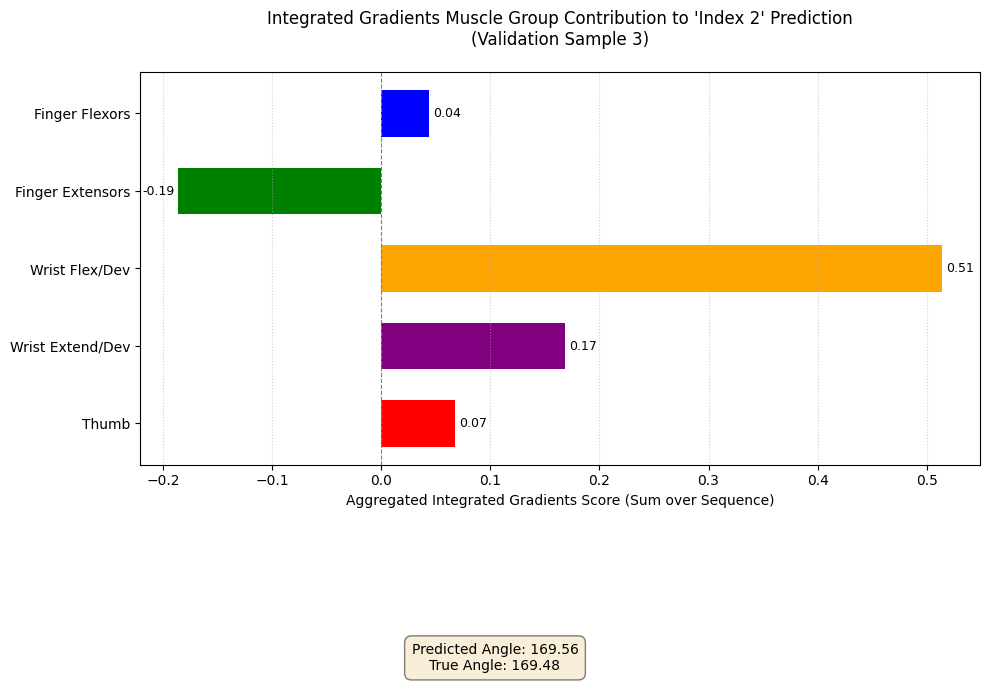

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from textwrap import wrap
import warnings

# --- Dummy variables needed for the function definition (replace with actuals when integrating) ---
# These would normally be defined globally or passed into the main script execution
MUSCLE_GROUP_VIS_INFO = { # Example structure
    'Finger Flexors': {'indices': [2, 3], 'color': 'blue'},
    'Finger Extensors': {'indices': [4, 5], 'color': 'green'},
    'Wrist Flex/Dev': {'indices': [1], 'color': 'orange'},
    'Wrist Extend/Dev': {'indices': [6, 7], 'color': 'purple'},
    'Thumb': {'indices': [0], 'color': 'red'}
}
JOINT_ANGLE_NAMES = [ # Example structure
    'Thumb 1', 'Thumb 2', 'Index 1', 'Index 2', 'Index 3', 'Middle 1', 'Middle 2', 'Middle 3',
    'Ring 1', 'Ring 2', 'Ring 3', 'Little 1', 'Little 2', 'Little 3'
]

# --- Visualization Function ---

def visualize_prediction_attributions(attributions, predicted_angle, target_angle_name,
                                      muscle_group_info, true_angle=None,
                                      title_suffix="", xai_method="Attribution"):
    """
    Visualizes aggregated XAI attributions per muscle group for a single angle prediction.

    Args:
        attributions (np.ndarray): XAI attribution scores for a single prediction,
                                   shape (seq_len, num_emg).
        predicted_angle (float): The predicted angle value (can be scaled or rescaled).
        target_angle_name (str): The name of the joint angle being explained.
        muscle_group_info (dict): Dictionary mapping group names to indices and colors.
        true_angle (float, optional): The true angle value for comparison. Defaults to None.
        title_suffix (str, optional): Suffix to add to the plot title (e.g., "Sample 0").
        xai_method(str, optional): Name of the XAI method used (e.g., "IG", "SHAP").
                                   Defaults to "Attribution".
    """
    print(f"\n--- Visualizing {xai_method} Muscle Contribution for {target_angle_name} {title_suffix} ---")

    if attributions is None or attributions.ndim != 2:
        print(f"Error: Invalid attributions shape ({attributions.shape if attributions is not None else 'None'}). Expected (seq_len, num_emg). Skipping plot.")
        return

    seq_len, num_emg = attributions.shape

    # --- Aggregate Attributions per Muscle Group ---
    group_names = list(muscle_group_info.keys())
    aggregated_scores = {name: 0.0 for name in group_names}
    group_colors = {}

    # Sum attributions over time for each channel first
    total_channel_attribution = np.sum(attributions, axis=0) # Shape: (num_emg,)

    # Aggregate scores per muscle group
    valid_groups = [] # Keep track of groups with data
    for group_name, info in muscle_group_info.items():
        indices = info.get('indices', [])
        color = info.get('color', 'gray')
        if indices: # Check if group has channels defined
            # Ensure indices are within the bounds of channel attributions
            valid_indices = [idx for idx in indices if idx < len(total_channel_attribution)]
            if valid_indices:
                # Sum the total attributions for valid channels belonging to this group
                aggregated_scores[group_name] = np.sum(total_channel_attribution[valid_indices])
                group_colors[group_name] = color
                valid_groups.append(group_name)
            else:
                 print(f"Warning: No valid channel indices found for group '{group_name}'.")
                 del aggregated_scores[group_name] # Remove group if no valid channels
        else:
             print(f"Warning: No indices defined for group '{group_name}'.")
             del aggregated_scores[group_name] # Remove group if no indices

    if not valid_groups:
        print("Error: No valid muscle groups found with data to plot.")
        return

    # Prepare data for plotting
    plot_group_names = valid_groups
    plot_scores = [aggregated_scores[name] for name in plot_group_names]
    plot_colors = [group_colors[name] for name in plot_group_names]

    # --- Create Visualization ---
    fig, ax = plt.subplots(figsize=(10, 6))

    # Horizontal bar chart
    y_pos = np.arange(len(plot_group_names))
    bars = ax.barh(y_pos, plot_scores, color=plot_colors, align='center', height=0.6)

    # Add value labels on bars
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)

    # Formatting
    ax.set_yticks(y_pos)
    ax.set_yticklabels(plot_group_names)
    ax.invert_yaxis() # Display top-to-bottom
    ax.set_xlabel(f"Aggregated {xai_method} Score (Sum over Sequence)")
    ax.set_title(f"{xai_method} Muscle Group Contribution to '{target_angle_name}' Prediction\n{title_suffix}",
                 fontsize=12, pad=20)
    ax.axvline(0, color='grey', lw=0.8, linestyle='--') # Zero line
    ax.grid(True, axis='x', linestyle=':', alpha=0.6)

    # Add prediction/true value text
    text_y_pos = -0.15 # Position below the plot area
    pred_text = f"Predicted Angle: {predicted_angle:.2f}"
    if true_angle is not None:
        true_text = f"True Angle: {true_angle:.2f}"
        info_text = f"{pred_text}\n{true_text}"
    else:
        info_text = pred_text
    fig.text(0.5, text_y_pos, info_text, ha='center', va='top', fontsize=10, wrap=True,
             bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))


    plt.tight_layout(rect=[0, 0.05, 1, 0.93]) # Adjust layout to make space for text
    plt.show()




target_angle_name_ig = 'Index 2' # Or whichever angle you explained
try:
    target_angle_index_ig = JOINT_ANGLE_NAMES.index(target_angle_name_ig)
except ValueError:
    target_angle_index_ig = 0
    target_angle_name_ig = JOINT_ANGLE_NAMES[0] # Fallback

# ig_attributions_sample should have shape (SEQUENCE_LENGTH, num_emg_features)
if ig_attributions is not None:
    # Select the attribution for the current sample if calculated in batch
    if ig_attributions.ndim == 3 and ig_attributions.shape[0] > 1:
        ig_attributions_sample = ig_attributions[i] # Assuming i is the sample index
    elif ig_attributions.ndim == 2:
         ig_attributions_sample = ig_attributions
    else:
         print("Error: Unexpected IG attribution shape.")
         ig_attributions_sample = None

    if ig_attributions_sample is not None:
        # Get the corresponding predicted angle value for this sample and target index
        # Ensure y_pred_scaled_all holds predictions for all validation samples
        predicted_value_scaled = y_pred_scaled_all[i, target_angle_index_ig]

        # Try to get rescaled value if scaler exists
        predicted_value_rescaled = None
        true_value_rescaled = None
        if hasattr(angle_scaler, 'mean_') and angle_scaler.mean_ is not None:
             try:
                 # Reshape needed for scaler if predicting single value
                 pred_reshape = y_pred_scaled_all[i].reshape(1, -1)
                 true_reshape = y_val[i].reshape(1, -1)
                 predicted_value_rescaled = angle_scaler.inverse_transform(pred_reshape)[0, target_angle_index_ig]
                 true_value_rescaled = angle_scaler.inverse_transform(true_reshape)[0, target_angle_index_ig]
             except Exception as e:
                 print(f"Warning: Could not rescale angles for visualization: {e}")

        # Choose which angle value to display (prefer rescaled)
        angle_to_display = predicted_value_rescaled if predicted_value_rescaled is not None else predicted_value_scaled
        true_angle_to_display = true_value_rescaled # Will be None if rescaling failed

        visualize_prediction_attributions(
            attributions=ig_attributions_sample,
            predicted_angle=angle_to_display,
            target_angle_name=target_angle_name_ig,
            muscle_group_info=MUSCLE_GROUP_VIS_INFO, # Pass your defined muscle groups
            true_angle=true_angle_to_display,
            title_suffix=f"(Validation Sample {i})",
            xai_method="Integrated Gradients"
        )
    else:
        print(f"Skipping XAI contribution plot for sample {i} due to attribution calculation error.")



--- Visualizing Detailed Composition for All Muscle Groups (Validation Sample 1) ---


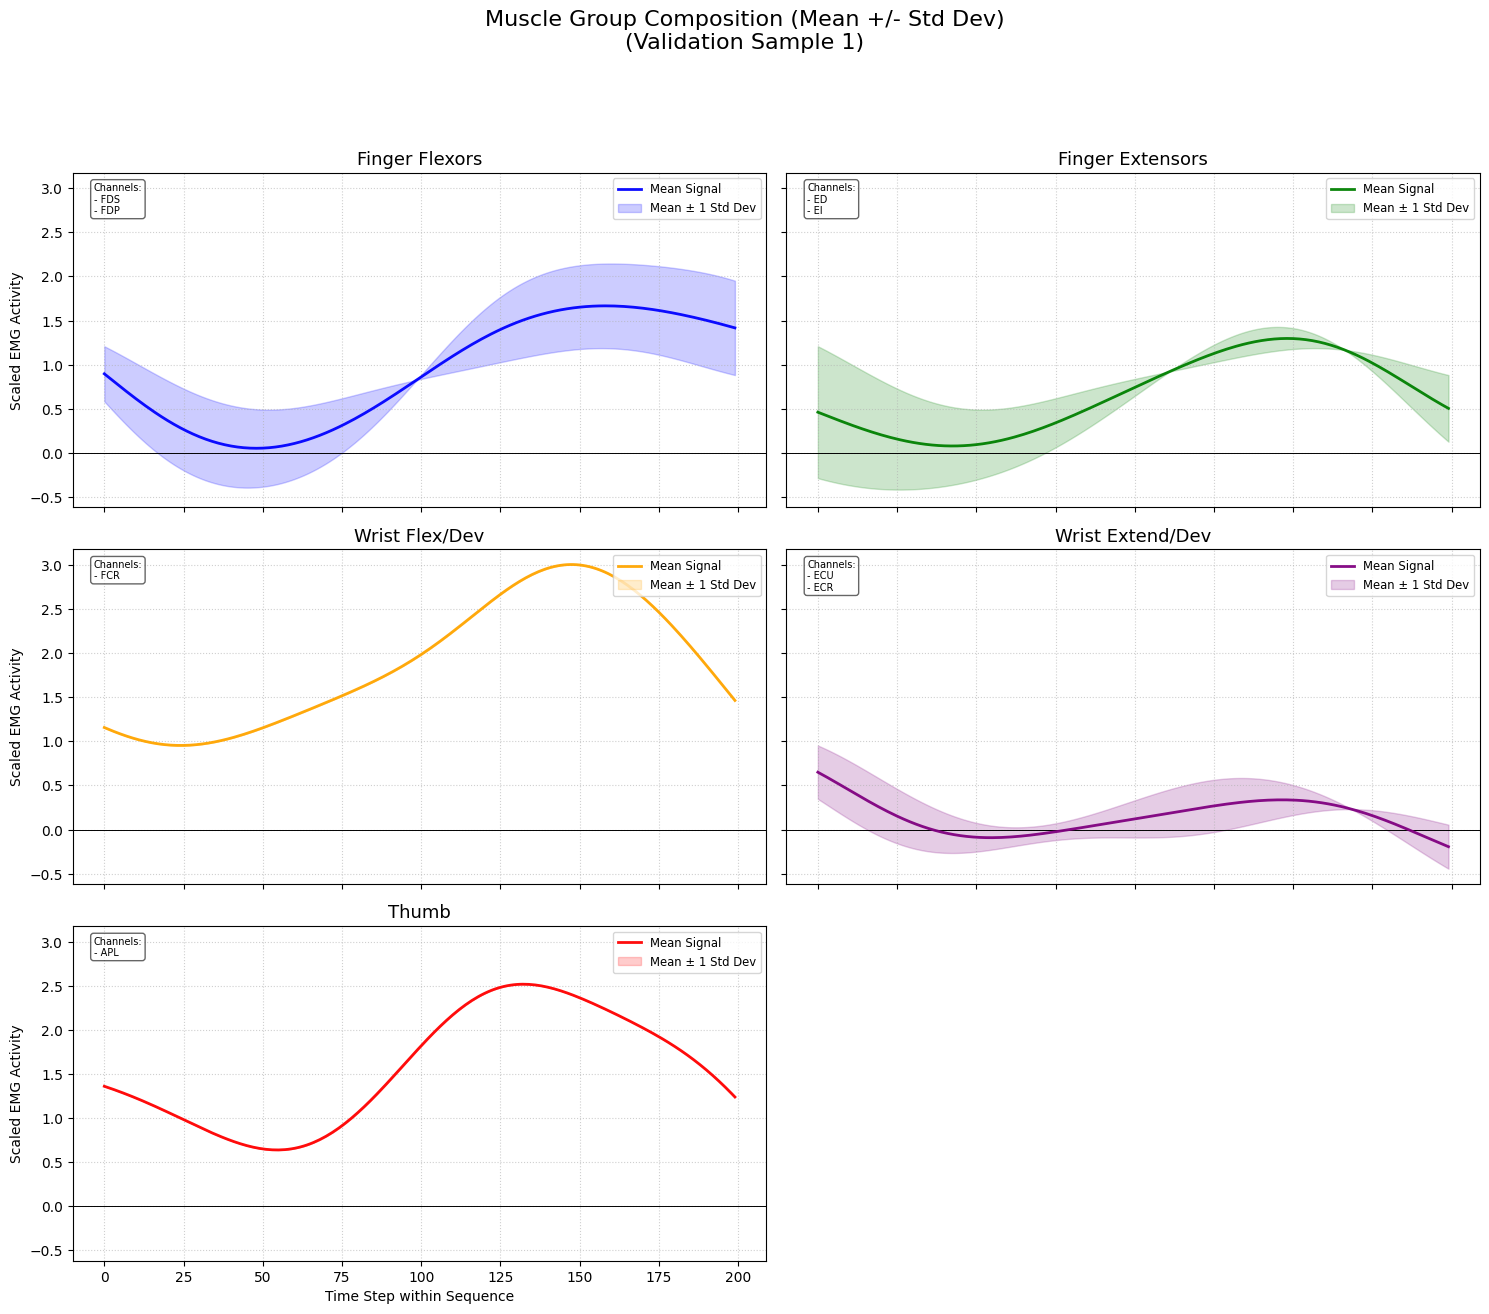

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from textwrap import wrap
import math # For ceiling division
import warnings # To ignore potential RuntimeWarnings from std dev of single channel

# --- Dummy variables needed for the function definition (replace with actuals when integrating) ---
# These would normally be defined globally or passed into the main script execution
MUSCLE_GROUP_VIS_INFO = { # Example structure
    'Finger Flexors': {'indices': [2, 3], 'color': 'blue'},
    'Finger Extensors': {'indices': [4, 5], 'color': 'green'},
    'Wrist Flex/Dev': {'indices': [1], 'color': 'orange'},
    'Wrist Extend/Dev': {'indices': [6, 7], 'color': 'purple'},
    'Thumb': {'indices': [0], 'color': 'red'}
}
EMG_CHANNEL_NAMES = ['APL', 'FCR', 'FDS', 'FDP', 'ED', 'EI', 'ECU', 'ECR'] # Example
SEQUENCE_LENGTH = 200 # Example

# --- Modified Visualization Function (Detailed with Std Dev and Channel Names) ---

def visualize_all_muscle_group_composition(emg_sequence, muscle_group_info,
                                           emg_channel_names, sequence_length,
                                           title_suffix=""):
    """
    Visualizes how each defined muscle group's signal is formed from individual
    channels in a single figure with multiple subplots. Includes mean +/- std dev
    and lists constituent channels.

    Args:
        emg_sequence (np.ndarray): Scaled EMG input sequence (seq_len, num_emg).
        muscle_group_info (dict): Dict mapping group names to indices and colors.
        emg_channel_names (list): List of all EMG channel names.
        sequence_length (int): Expected sequence length of the EMG data.
        title_suffix (str, optional): Suffix for the plot title (e.g., "Sample 0").
    """
    print(f"\n--- Visualizing Detailed Composition for All Muscle Groups {title_suffix} ---")

    # --- Validate Inputs ---
    if not muscle_group_info:
        print("Error: muscle_group_info dictionary is empty.")
        return
    if emg_sequence is None or emg_sequence.ndim != 2:
         print(f"Error: Invalid emg_sequence shape ({emg_sequence.shape if emg_sequence is not None else 'None'}). Expected (seq_len, num_emg).")
         return
    if emg_sequence.shape[0] != sequence_length:
         print(f"Warning: EMG sequence length ({emg_sequence.shape[0]}) does not match expected sequence_length ({sequence_length}). Using actual length.")
         sequence_length = emg_sequence.shape[0] # Adjust based on data
    if sequence_length == 0:
         print("Error: Sequence length is zero.")
         return

    num_emg = emg_sequence.shape[1]
    time_axis = np.arange(sequence_length)
    valid_groups = list(muscle_group_info.keys())
    num_groups = len(valid_groups)

    # --- Create Subplot Grid ---
    ncols = 2 # Adjust number of columns as needed
    nrows = math.ceil(num_groups / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(7.5 * ncols, 4.5 * nrows), # Slightly larger plots
                             sharex=True, sharey=True) # Share axes for consistent scaling
    # Handle case where nrows*ncols=1 (single subplot)
    if num_groups == 1:
        axes = np.array([axes])
    axes = axes.flatten() # Flatten axes array for easy iteration
    fig.suptitle(f"Muscle Group Composition (Mean +/- Std Dev)\n{title_suffix}", fontsize=16, y=1.0)

    # --- Plot for each Muscle Group ---
    for i, muscle_group_name in enumerate(valid_groups):
        ax = axes[i]
        group_info = muscle_group_info[muscle_group_name]
        channel_indices = group_info.get('indices', [])
        group_color = group_info.get('color', 'black')

        ax.set_title(muscle_group_name, fontsize=13) # Slightly larger title
        ax.grid(True, linestyle=':', alpha=0.6) # Lighter grid
        ax.axhline(0, color='black', lw=0.7, linestyle='-')

        constituent_channel_names = [] # To store names for annotation

        if not channel_indices:
            print(f"Warning: No channel indices defined for group '{muscle_group_name}'. Skipping subplot.")
            ax.text(0.5, 0.5, "No channels defined", ha='center', va='center', transform=ax.transAxes)
            continue

        valid_indices = [idx for idx in channel_indices if idx < num_emg]
        if not valid_indices:
             print(f"Warning: No valid channel indices found for group '{muscle_group_name}' within EMG data bounds. Skipping subplot.")
             ax.text(0.5, 0.5, "Channel indices\nout of bounds", ha='center', va='center', transform=ax.transAxes)
             continue

        # Get channel names for annotation BEFORE plotting
        for idx in valid_indices:
             constituent_channel_names.append(emg_channel_names[idx] if idx < len(emg_channel_names) else f"Ch.{idx}")

        # Prepare Data for this group
        individual_signals = emg_sequence[:, valid_indices]
        num_channels_in_group = len(valid_indices)

        # Calculate Mean and Standard Deviation
        average_group_signal = np.mean(individual_signals, axis=1)
        # Calculate std dev, handle case with only 1 channel (std dev is 0)
        with warnings.catch_warnings(): # Suppress RuntimeWarning for std of single element slice
             warnings.simplefilter("ignore", category=RuntimeWarning)
             std_dev_group_signal = np.std(individual_signals, axis=1) if num_channels_in_group > 1 else np.zeros_like(average_group_signal)


        # Plot individual channel signals (optional, can be commented out)
        # for k in range(num_channels_in_group):
        #     channel_idx = valid_indices[k]
        #     ax.plot(time_axis, individual_signals[:, k],
        #             linestyle=':', alpha=0.4, lw=0.8, color=group_color)

        # Plot the average group signal
        ax.plot(time_axis, average_group_signal,
                label=f'Mean Signal', # Label for legend
                color=group_color, linewidth=2.0, alpha=0.95)

        # Plot the standard deviation envelope
        ax.fill_between(time_axis,
                        average_group_signal - std_dev_group_signal,
                        average_group_signal + std_dev_group_signal,
                        color=group_color, alpha=0.2, label='Mean ± 1 Std Dev')

        # Add axis labels only to edge plots
        if i >= (nrows - 1) * ncols: # Bottom row
            ax.set_xlabel("Time Step within Sequence")
        if i % ncols == 0: # First column
            ax.set_ylabel("Scaled EMG Activity")

        # Add legend to each subplot
        ax.legend(loc='upper right', fontsize='small')

        # --- ADD CHANNEL NAME ANNOTATION ---
        channels_text = "Channels:\n" + "\n".join([f"- {name}" for name in constituent_channel_names])
        # Position the text box (adjust x, y as needed)
        ax.text(0.03, 0.97, channels_text, transform=ax.transAxes, fontsize=7, # Smaller font size
                verticalalignment='top', horizontalalignment='left',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.6))
        # --- END ANNOTATION ---


    # Hide unused subplots
    for j in range(num_groups, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout for suptitle
    plt.show()



if 'X_val' in locals() and len(X_val) > 0: # Check if validation data exists
    sample_index_to_plot = 1 # Choose a sample index
    emg_sample = X_val[sample_index_to_plot]

    # Visualize composition for ALL defined muscle groups in one figure
    visualize_all_muscle_group_composition(
        emg_sequence=emg_sample,
        muscle_group_info=MUSCLE_GROUP_VIS_INFO, # Pass the whole dict
        emg_channel_names=EMG_CHANNEL_NAMES,
        sequence_length=SEQUENCE_LENGTH,
        title_suffix=f"(Validation Sample {sample_index_to_plot})"
    )
else:
    print("No validation data available to visualize muscle group composition.")




--- Visualizing Attention Flow for Head 1 (Index), Trial T1_Task1 ---


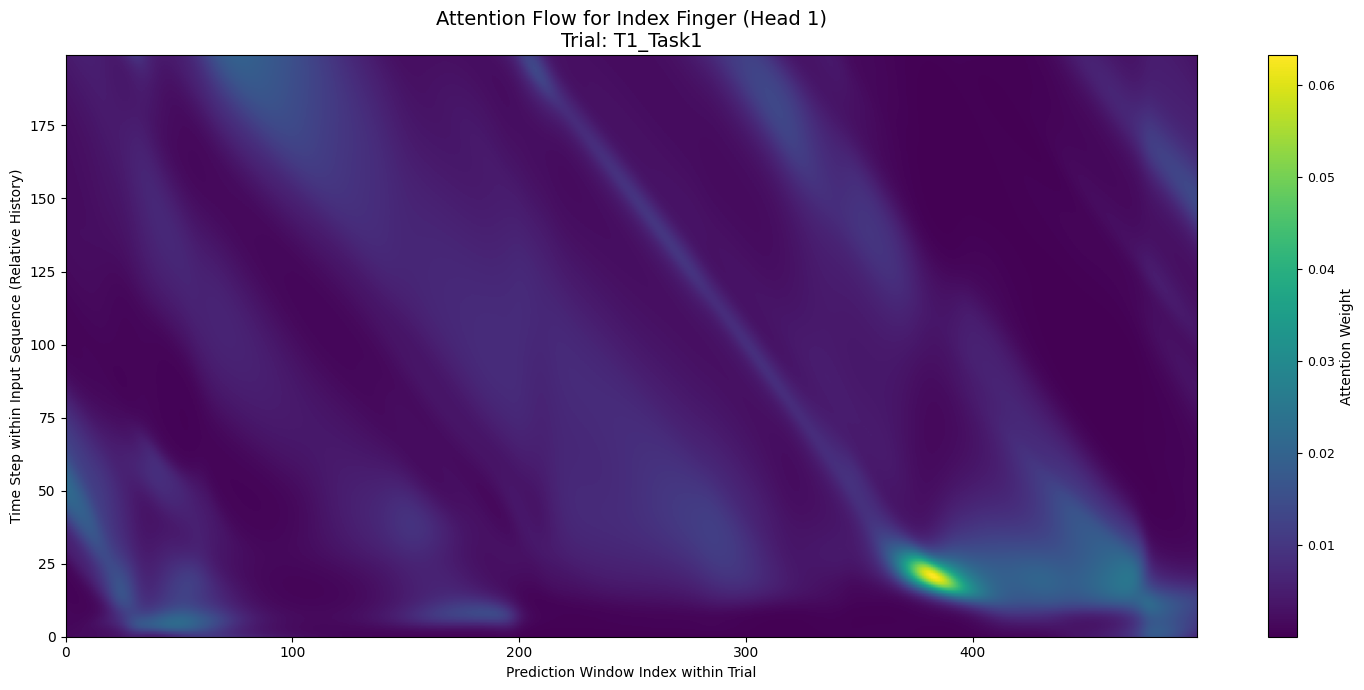


--- Visualizing Cross-Head Attention Correlation ---


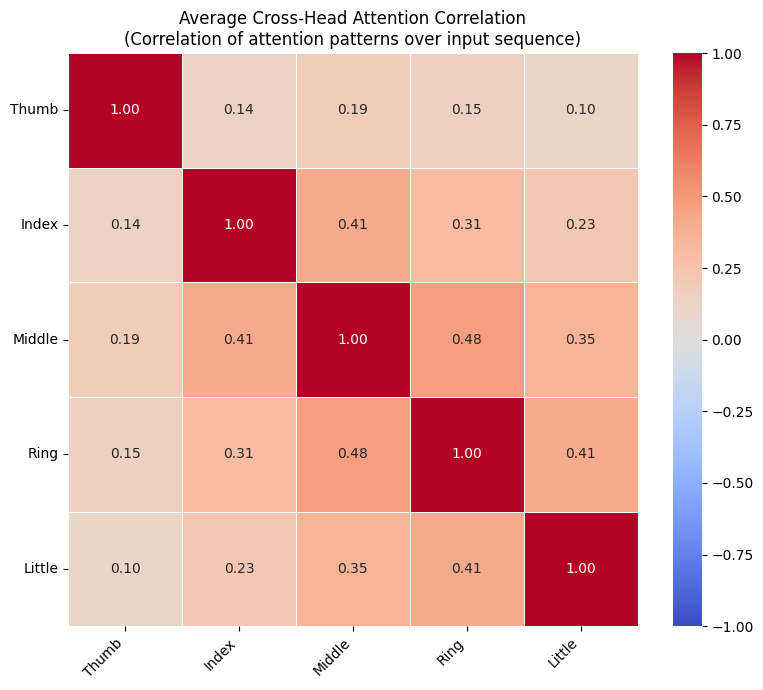

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # For correlation heatmap
import pandas as pd  # For correlation heatmap
from textwrap import wrap

# --- Dummy variables needed for the function definitions ---
# Replace with actuals when integrating
FINGER_NAMES = ['Thumb', 'Index', 'Middle', 'Ring', 'Little'] # Example
SEQUENCE_LENGTH = 200 # Example

# --- Function 1: Attention Flow Visualization ---

def visualize_attention_flow(mha_attention_weights_trial, head_to_plot_idx,
                             finger_name, sequence_length, trial_id,
                             max_windows_to_plot=500):
    """
    Visualizes how attention weights for a specific head evolve over prediction windows.

    Args:
        mha_attention_weights_trial (np.ndarray): Attention weights for a single trial.
                                                  Shape: (num_windows, num_heads, seq_len).
        head_to_plot_idx (int): Index of the attention head to visualize.
        finger_name (str): Name of the finger corresponding to the head.
        sequence_length (int): Length of the input EMG sequence.
        trial_id (str): Identifier for the trial being visualized.
        max_windows_to_plot (int): Maximum number of prediction windows to display
                                   to keep the plot readable.
    """
    print(f"\n--- Visualizing Attention Flow for Head {head_to_plot_idx} ({finger_name}), Trial {trial_id} ---")

    if mha_attention_weights_trial is None or mha_attention_weights_trial.ndim != 3:
        print("Error: Invalid attention weights provided. Expected shape (num_windows, num_heads, seq_len).")
        return

    num_windows, num_heads, seq_len = mha_attention_weights_trial.shape

    if head_to_plot_idx >= num_heads:
        print(f"Error: head_to_plot_idx ({head_to_plot_idx}) is out of bounds for {num_heads} heads.")
        return
    if seq_len != sequence_length:
         print(f"Warning: Attention sequence length ({seq_len}) differs from configured SEQUENCE_LENGTH ({sequence_length}). Using attention sequence length.")
         sequence_length = seq_len # Use actual length from weights

    # Extract attention for the selected head over all windows
    # Shape: (num_windows, seq_len)
    attention_head_over_windows = mha_attention_weights_trial[:, head_to_plot_idx, :]

    # Limit the number of windows for readability
    if num_windows > max_windows_to_plot:
        print(f"Warning: Plotting only the first {max_windows_to_plot} windows out of {num_windows} for readability.")
        attention_head_over_windows = attention_head_over_windows[:max_windows_to_plot, :]
        plot_num_windows = max_windows_to_plot
    else:
        plot_num_windows = num_windows

    if plot_num_windows == 0 or sequence_length == 0:
        print("Error: No data points to plot for attention flow.")
        return

    # --- Create Heatmap ---
    fig, ax = plt.subplots(figsize=(15, 7))

    # Transpose for heatmap: x-axis = prediction window index, y-axis = input sequence time step
    # Origin='lower' puts time step 0 at the bottom
    im = ax.imshow(attention_head_over_windows.T, aspect='auto', cmap='viridis', origin='lower',
                   extent=[0, plot_num_windows - 1, 0, sequence_length - 1]) # Adjust extent

    ax.set_title(f"Attention Flow for {finger_name} Finger (Head {head_to_plot_idx})\nTrial: {trial_id}", fontsize=14)
    ax.set_xlabel("Prediction Window Index within Trial")
    ax.set_ylabel("Time Step within Input Sequence (Relative History)")

    # Add colorbar
    cbar = fig.colorbar(im, ax=ax, label='Attention Weight')
    cbar.ax.tick_params(labelsize=9)

    plt.tight_layout()
    plt.show()


# --- Function 2: Cross-Head Attention Correlation ---

def visualize_cross_head_attention_correlation(mha_attention_weights_all_samples, finger_names):
    """
    Calculates and visualizes the average correlation matrix between attention head patterns.

    Args:
        mha_attention_weights_all_samples (np.ndarray): Attention weights across multiple samples.
                                                        Shape: (num_samples, num_heads, seq_len).
        finger_names (list): List of names corresponding to the attention heads.
    """
    print("\n--- Visualizing Cross-Head Attention Correlation ---")

    if mha_attention_weights_all_samples is None or mha_attention_weights_all_samples.ndim != 3:
        print("Error: Invalid attention weights provided. Expected shape (num_samples, num_heads, seq_len).")
        return

    num_samples, num_heads, seq_len = mha_attention_weights_all_samples.shape

    if num_heads != len(finger_names):
        print(f"Warning: Number of heads ({num_heads}) does not match number of finger names ({len(finger_names)}). Using generic head labels.")
        finger_names = [f"Head {i}" for i in range(num_heads)]

    if num_samples < 2:
        print("Error: Need at least 2 samples to calculate meaningful correlations.")
        return
    if num_heads < 2:
        print("Error: Need at least 2 heads to calculate cross-head correlations.")
        return

    # Calculate correlation matrix for each sample and average
    all_corr_matrices = []
    for i in range(num_samples):
        # Get attention weights for one sample: shape (num_heads, seq_len)
        sample_weights = mha_attention_weights_all_samples[i, :, :]
        # Calculate pairwise correlation between rows (heads)
        # Pandas DataFrame handles this easily
        df_sample = pd.DataFrame(sample_weights.T, columns=finger_names) # Transpose so heads are columns
        # Calculate correlation between columns (heads)
        corr_matrix = df_sample.corr()
        # Check for NaNs (can happen if a head has constant attention)
        if not corr_matrix.isnull().values.any():
            all_corr_matrices.append(corr_matrix.values) # Store as numpy array
        # else:
        #     print(f"Warning: Skipping sample {i} due to NaNs in correlation matrix (possibly constant attention).")


    if not all_corr_matrices:
        print("Error: Could not calculate any valid correlation matrices.")
        return

    # Average the correlation matrices
    avg_corr_matrix = np.mean(np.array(all_corr_matrices), axis=0)
    avg_corr_df = pd.DataFrame(avg_corr_matrix, index=finger_names, columns=finger_names)

    # --- Create Heatmap ---
    plt.figure(figsize=(8, 7))
    sns.heatmap(avg_corr_df, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1, vmax=1, cbar=True)
    plt.title("Average Cross-Head Attention Correlation\n(Correlation of attention patterns over input sequence)")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


# Assume 'trial_mha_weights' holds attention weights for one trial (num_windows, num_heads, seq_len)
# Assume 'head_idx' is the index of the head you want to plot (e.g., from dynamic simulation)
# Assume 'trial_id_str' is the identifier for that trial
# Assume 'FINGER_NAMES' and 'SEQUENCE_LENGTH' are defined

if 'trial_mha_weights' in locals() and trial_mha_weights is not None and \
   'head_idx' in locals() and head_idx is not None and \
   'trial_id_str' in locals():

    finger_name_to_plot = FINGER_NAMES[head_idx] if head_idx < len(FINGER_NAMES) else f"Head {head_idx}"

    visualize_attention_flow(
        mha_attention_weights_trial=trial_mha_weights,
        head_to_plot_idx=head_idx,
        finger_name=finger_name_to_plot,
        sequence_length=SEQUENCE_LENGTH,
        trial_id=trial_id_str
    )
else:
    print("Skipping Attention Flow plot (required data not available).")


# --- Example Call for Cross-Head Correlation ---
# Assume 'mha_attention_weights_all_val' holds attention weights for all validation samples
# Shape: (num_val_samples, num_heads, seq_len)
# Assume 'FINGER_NAMES' is defined

if 'mha_attention_weights_all_val' in locals() and mha_attention_weights_all_val is not None:
    visualize_cross_head_attention_correlation(
        mha_attention_weights_all_samples=mha_attention_weights_all_val,
        finger_names=FINGER_NAMES
    )
else:
    print("Skipping Cross-Head Attention Correlation plot (validation attention weights not available).")




--- Visualizing Prediction Error vs. Attention for 'Index 2' ---
Analyzing joint 'Index 2' (Index: 3) and Attention Head 1 ('Index').


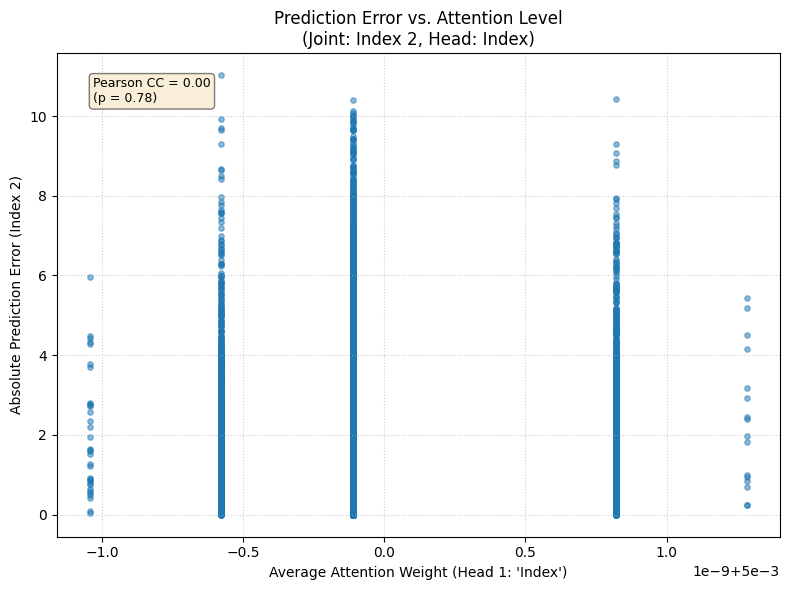


--- Visualizing Prediction Error vs. Attention for 'Thumb 1' ---
Analyzing joint 'Thumb 1' (Index: 0) and Attention Head 0 ('Thumb').


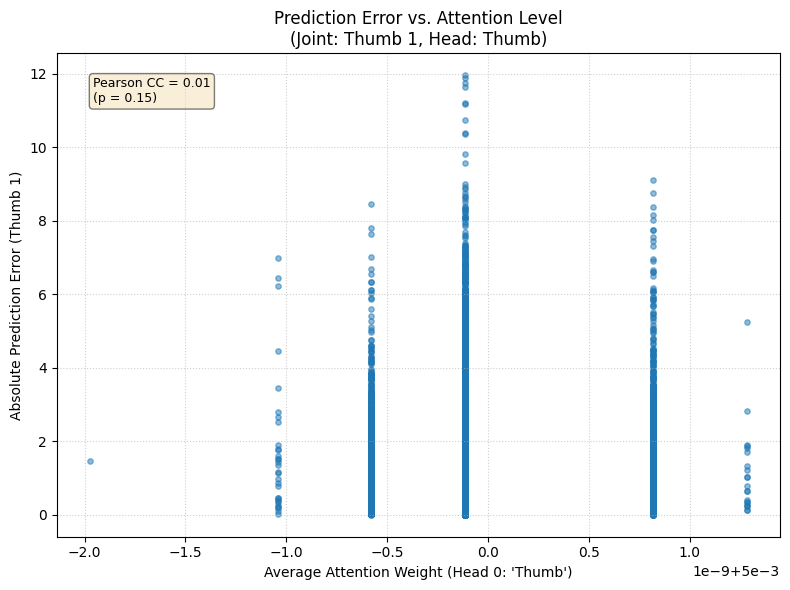

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
from textwrap import wrap

# --- Dummy variables needed for the function definition ---
# Replace with actuals when integrating
FINGER_NAMES = ['Thumb', 'Index', 'Middle', 'Ring', 'Little'] # Example
JOINT_ANGLE_NAMES = [ # Example structure
    'Thumb 1', 'Thumb 2', 'Index 1', 'Index 2', 'Index 3', 'Middle 1', 'Middle 2', 'Middle 3',
    'Ring 1', 'Ring 2', 'Ring 3', 'Little 1', 'Little 2', 'Little 3'
]
FINGER_JOINT_INDICES = { # Example structure
    'Thumb': list(range(0, 2)), 'Index': list(range(2, 5)), 'Middle': list(range(5, 8)),
    'Ring': list(range(8, 11)), 'Little': list(range(11, 14))
}

# --- Visualization Function ---

def visualize_error_vs_attention(y_true, y_pred, mha_attention_weights,
                                 target_joint_name, finger_joint_indices,
                                 joint_angle_names, finger_names):
    """
    Visualizes the relationship between prediction error for a joint and the
    average attention level of its corresponding head.

    Args:
        y_true (np.ndarray): True joint angles (samples, num_angles). Should be rescaled.
        y_pred (np.ndarray): Predicted joint angles (samples, num_angles). Should be rescaled.
        mha_attention_weights (np.ndarray): Attention weights (samples, num_heads, seq_len).
        target_joint_name (str): Name of the joint angle to analyze error for.
        finger_joint_indices (dict): Mapping from finger name to list of joint angle indices.
        joint_angle_names (list): List of all joint angle names.
        finger_names (list): List of finger names corresponding to heads.
    """
    print(f"\n--- Visualizing Prediction Error vs. Attention for '{target_joint_name}' ---")

    # --- Validate Inputs ---
    if y_true.shape != y_pred.shape:
        print("Error: Shape mismatch between true and predicted angles.")
        return
    if y_true.ndim != 2 or mha_attention_weights.ndim != 3:
         print("Error: Invalid dimensions for input arrays.")
         return
    if y_true.shape[0] != mha_attention_weights.shape[0]:
         print("Error: Number of samples mismatch between angles and attention weights.")
         return

    num_samples, num_angles = y_true.shape
    num_heads, seq_len = mha_attention_weights.shape[1], mha_attention_weights.shape[2]

    if num_heads != len(finger_names):
        print(f"Warning: Number of heads ({num_heads}) differs from finger names ({len(finger_names)}).")
        # Proceed with caution, head mapping might be incorrect

    # --- Find Target Joint Index and Corresponding Head ---
    try:
        target_joint_idx = joint_angle_names.index(target_joint_name)
    except ValueError:
        print(f"Error: Target joint '{target_joint_name}' not found in joint_angle_names.")
        return

    target_head_idx = -1
    target_finger_name = "Unknown"
    for finger, indices in finger_joint_indices.items():
        if target_joint_idx in indices:
            try:
                # Find the index of this finger in the finger_names list (which corresponds to head order)
                target_head_idx = finger_names.index(finger)
                target_finger_name = finger
                break
            except ValueError:
                 print(f"Warning: Finger '{finger}' found in mapping but not in finger_names list.")
                 # Continue searching in case another mapping exists

    if target_head_idx == -1:
        print(f"Error: Could not map target joint '{target_joint_name}' to an attention head via finger_names.")
        return
    if target_head_idx >= num_heads:
         print(f"Error: Mapped head index ({target_head_idx}) is out of bounds for available heads ({num_heads}).")
         return

    print(f"Analyzing joint '{target_joint_name}' (Index: {target_joint_idx}) and Attention Head {target_head_idx} ('{target_finger_name}').")

    # --- Calculate Data for Plotting ---
    # 1. Prediction Error (Absolute Error)
    prediction_errors = np.abs(y_pred[:, target_joint_idx] - y_true[:, target_joint_idx])

    # 2. Average Attention Weight for the target head across sequence length
    if seq_len > 0:
        avg_attention_target_head = np.mean(mha_attention_weights[:, target_head_idx, :], axis=1)
    else:
        print("Warning: Attention sequence length is zero. Cannot calculate average attention.")
        avg_attention_target_head = np.zeros(num_samples)


    # --- Create Scatter Plot ---
    fig, ax = plt.subplots(figsize=(8, 6))

    scatter = ax.scatter(avg_attention_target_head, prediction_errors, alpha=0.5, s=15)

    # --- Formatting and Analysis ---
    ax.set_xlabel(f"Average Attention Weight (Head {target_head_idx}: '{target_finger_name}')")
    ax.set_ylabel(f"Absolute Prediction Error ({target_joint_name})")
    ax.set_title(f"Prediction Error vs. Attention Level\n(Joint: {target_joint_name}, Head: {target_finger_name})")
    ax.grid(True, linestyle=':', alpha=0.6)

    # Calculate and display correlation coefficient
    if len(avg_attention_target_head) > 1 and len(prediction_errors) > 1: # Need at least 2 points
        try:
            # Use nan_policy='omit' to handle potential NaNs if errors occur
            corr, p_value = scipy.stats.pearsonr(avg_attention_target_head, prediction_errors)
            if not np.isnan(corr):
                 ax.text(0.05, 0.95, f'Pearson CC = {corr:.2f}\n(p = {p_value:.2g})',
                         transform=ax.transAxes, fontsize=9, va='top',
                         bbox=dict(boxstyle='round,pad=0.3', fc='wheat', alpha=0.5))
            else:
                 ax.text(0.05, 0.95, 'CC = NaN', transform=ax.transAxes, fontsize=9, va='top',
                         bbox=dict(boxstyle='round,pad=0.3', fc='wheat', alpha=0.5))

        except ValueError as e:
            print(f"Warning: Could not calculate correlation: {e}")
            ax.text(0.05, 0.95, 'CC Calculation Error', transform=ax.transAxes, fontsize=9, va='top',
                    bbox=dict(boxstyle='round,pad=0.3', fc='wheat', alpha=0.5))


    plt.tight_layout()
    plt.show()


# --- Code to Use (Example within your main script) ---
# Assume y_val_rescaled and y_pred_rescaled_all hold the rescaled angle values
# Assume mha_attention_weights_all_val holds attention weights for validation set
# Assume FINGER_JOINT_INDICES, JOINT_ANGLE_NAMES, FINGER_NAMES are defined



if 'y_val_rescaled' in locals() and \
   'y_pred_rescaled_all' in locals() and \
   'mha_attention_weights_all_val' in locals() and \
   mha_attention_weights_all_val is not None:

    # Select a joint to analyze
    joint_to_analyze = 'Index 2' # Example

    visualize_error_vs_attention(
        y_true=y_val_rescaled,
        y_pred=y_pred_rescaled_all,
        mha_attention_weights=mha_attention_weights_all_val,
        target_joint_name=joint_to_analyze,
        finger_joint_indices=FINGER_JOINT_INDICES,
        joint_angle_names=JOINT_ANGLE_NAMES,
        finger_names=FINGER_NAMES
    )

    # Example for another joint
    joint_to_analyze_2 = 'Thumb 1'
    visualize_error_vs_attention(
        y_true=y_val_rescaled,
        y_pred=y_pred_rescaled_all,
        mha_attention_weights=mha_attention_weights_all_val,
        target_joint_name=joint_to_analyze_2,
        finger_joint_indices=FINGER_JOINT_INDICES,
        joint_angle_names=JOINT_ANGLE_NAMES,
        finger_names=FINGER_NAMES
    )

else:
    print("Skipping Error vs. Attention plot (required data not available or not rescaled).")




   Calculating for: Thumb 1 (Index 0)
   Calculating for: Thumb 2 (Index 1)
   Calculating for: Index 1 (Index 2)
   Calculating for: Index 2 (Index 3)
   Calculating for: Index 3 (Index 4)
   Calculating for: Middle 1 (Index 5)
   Calculating for: Middle 2 (Index 6)
   Calculating for: Middle 3 (Index 7)
   Calculating for: Ring 1 (Index 8)
   Calculating for: Ring 2 (Index 9)
   Calculating for: Ring 3 (Index 10)
   Calculating for: Little 1 (Index 11)
   Calculating for: Little 2 (Index 12)
   Calculating for: Little 3 (Index 13)

--- Visualizing Multi-Joint Temporal Integrated Gradients Muscle Contribution (Validation Sample 0) ---


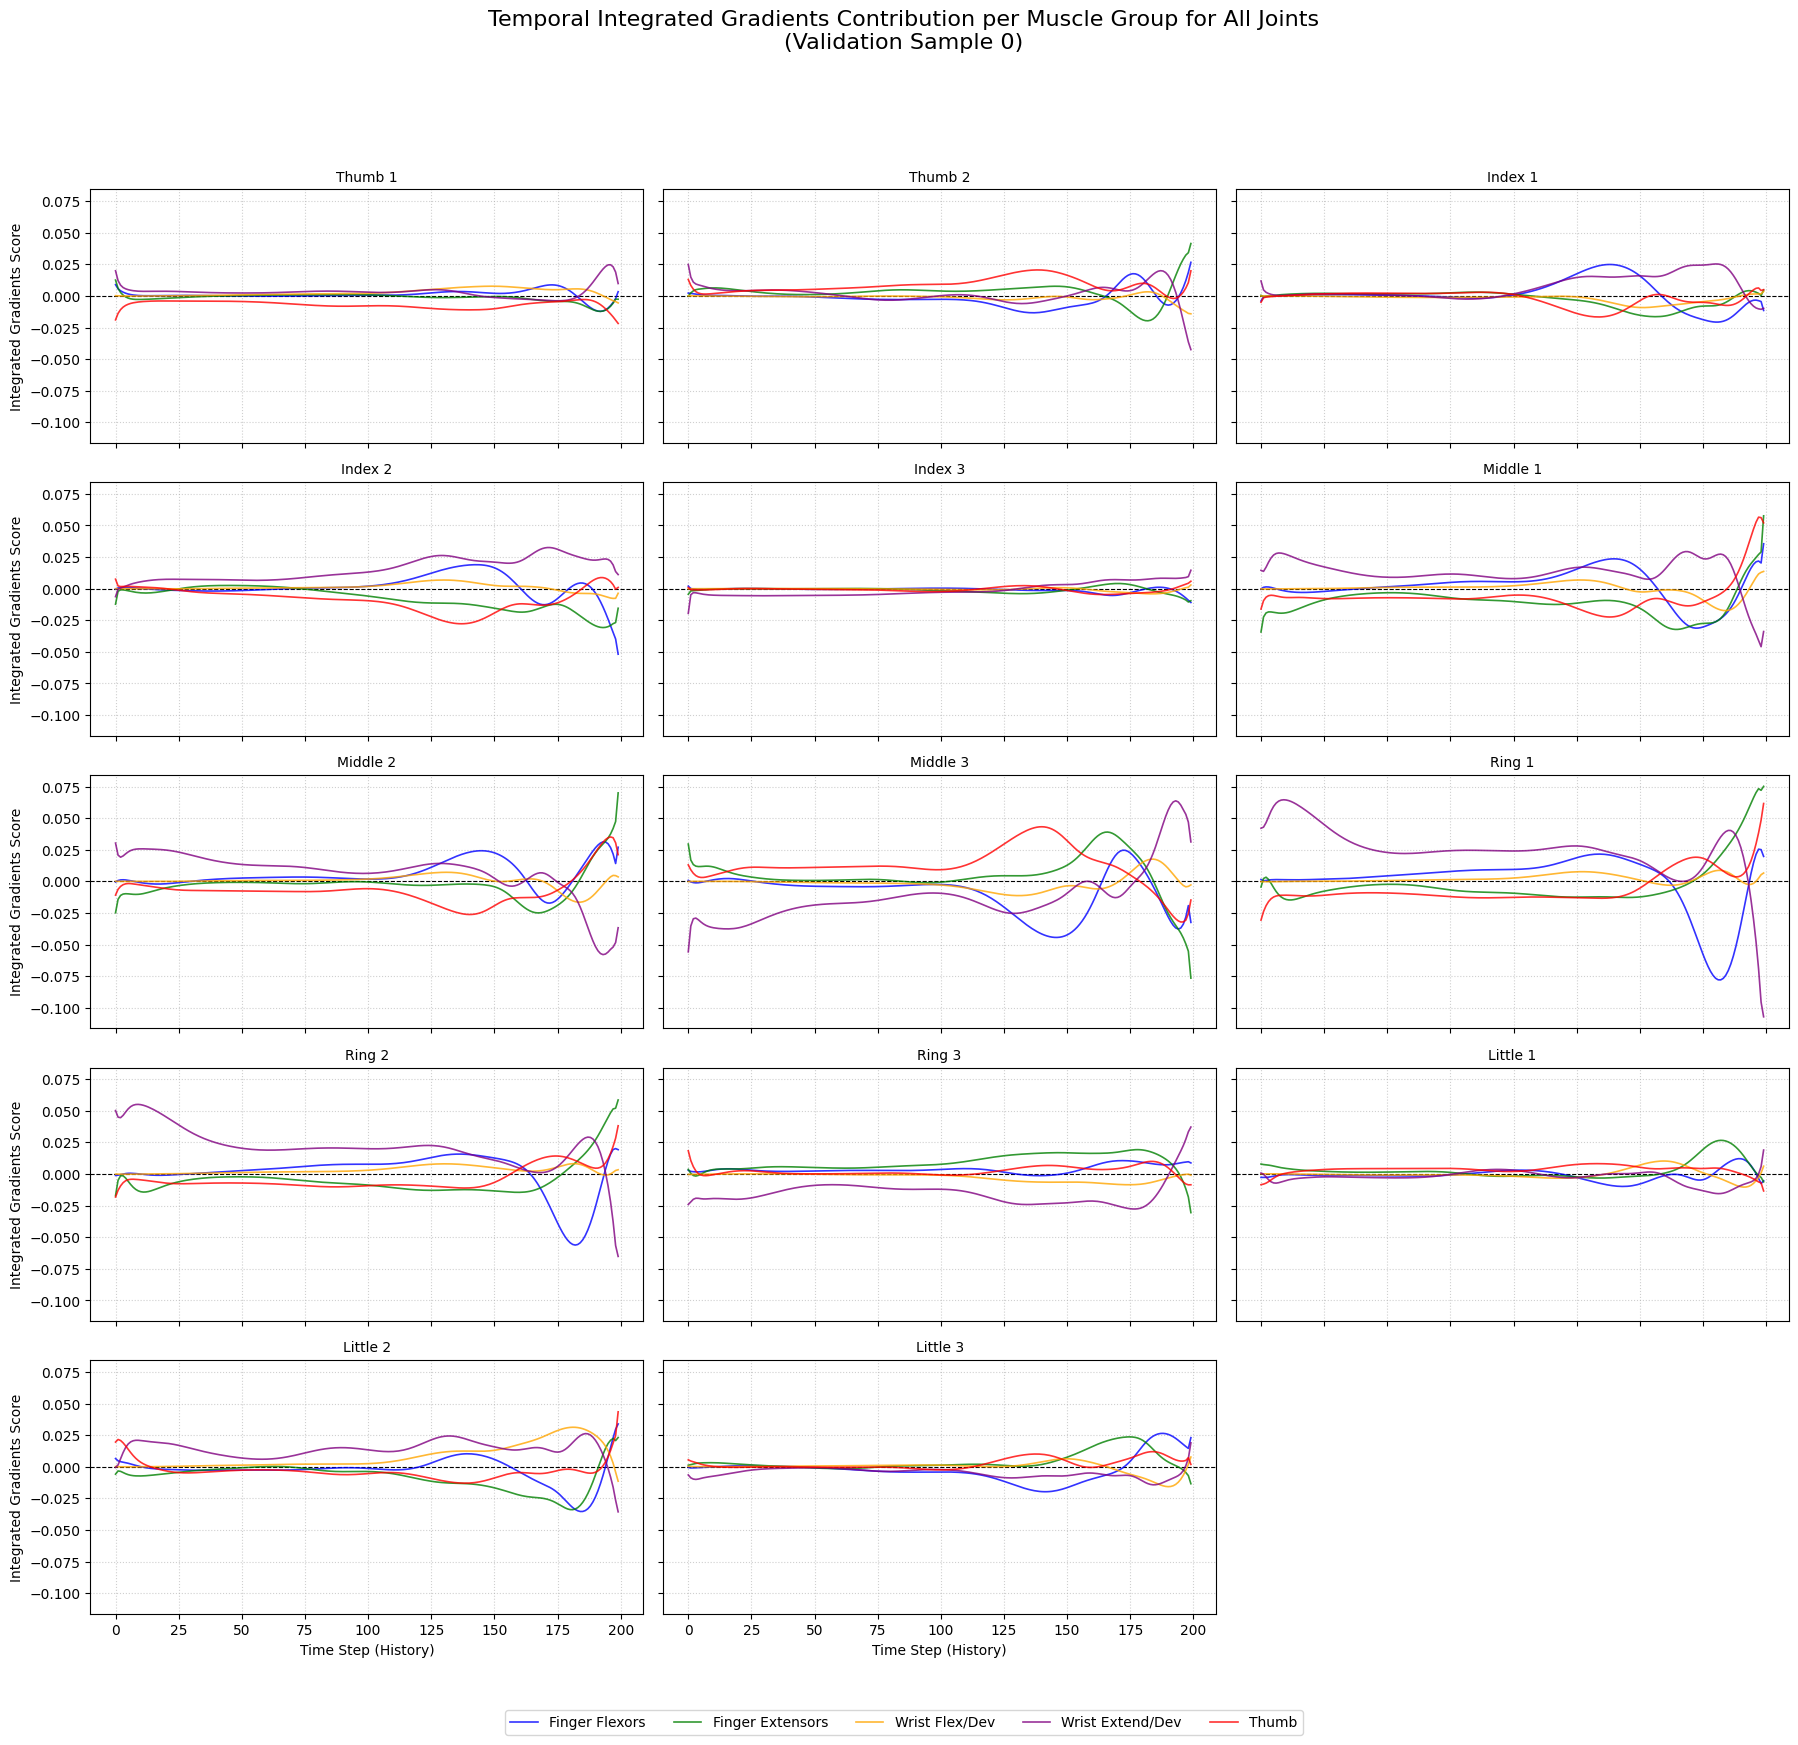

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from textwrap import wrap
import math # For ceiling division

# --- Dummy variables needed for the function definition ---
# Replace with actuals when integrating
MUSCLE_GROUP_VIS_INFO = { # Example structure
    'Finger Flexors': {'indices': [2, 3], 'color': 'blue'},
    'Finger Extensors': {'indices': [4, 5], 'color': 'green'},
    'Wrist Flex/Dev': {'indices': [1], 'color': 'orange'},
    'Wrist Extend/Dev': {'indices': [6, 7], 'color': 'purple'},
    'Thumb': {'indices': [0], 'color': 'red'}
}
JOINT_ANGLE_NAMES = [ # Example structure
    'Thumb 1', 'Thumb 2', 'Index 1', 'Index 2', 'Index 3', 'Middle 1', 'Middle 2', 'Middle 3',
    'Ring 1', 'Ring 2', 'Ring 3', 'Little 1', 'Little 2', 'Little 3'
]
SEQUENCE_LENGTH = 200 # Example

# --- Modified Visualization Function (Corrected Labeling) ---

def visualize_multi_joint_temporal_xai(all_joint_attributions, joint_angle_names,
                                       muscle_group_info, sequence_length,
                                       title_suffix="", xai_method="Attribution"):
    """
    Visualizes the temporal evolution of XAI attributions aggregated per muscle group
    for ALL joint angle predictions for a single input sample.

    Args:
        all_joint_attributions (list or dict): A list or dictionary where each element
                                              contains the XAI attribution scores
                                              (shape: seq_len, num_emg) calculated
                                              specifically for one joint angle's prediction.
                                              The order/keys should correspond to joint_angle_names.
        joint_angle_names (list): List of all joint angle names.
        muscle_group_info (dict): Dictionary mapping group names to indices and colors.
        sequence_length (int): Expected sequence length of the input.
        title_suffix (str, optional): Suffix to add to the plot title (e.g., "Sample 0").
        xai_method(str, optional): Name of the XAI method used (e.g., "IG", "SHAP").
                                   Defaults to "Attribution".
    """
    print(f"\n--- Visualizing Multi-Joint Temporal {xai_method} Muscle Contribution {title_suffix} ---")

    num_joints = len(joint_angle_names)

    # --- Validate Input ---
    if isinstance(all_joint_attributions, dict):
        # Assuming keys are indices 0..N-1
        if len(all_joint_attributions) != num_joints or \
           set(all_joint_attributions.keys()) != set(range(num_joints)):
             print(f"Error: Attribution dictionary keys/length mismatch with joint_angle_names.")
             return
        # Convert dict to list in correct order for iteration
        attributions_list = [all_joint_attributions[i] for i in range(num_joints)]
    elif isinstance(all_joint_attributions, list):
        if len(all_joint_attributions) != num_joints:
            print(f"Error: Attribution list length ({len(all_joint_attributions)}) mismatch with number of joints ({num_joints}).")
            return
        attributions_list = all_joint_attributions
    else:
        print("Error: all_joint_attributions must be a list or dictionary.")
        return

    # Check shape of first valid attribution array to get num_emg
    first_valid_attr = next((attr for attr in attributions_list if attr is not None and attr.ndim == 2), None)
    if first_valid_attr is None:
        print("Error: No valid attribution arrays found in the input.")
        return
    seq_len_attr, num_emg = first_valid_attr.shape
    if seq_len_attr != sequence_length:
        print(f"Warning: Attribution sequence length ({seq_len_attr}) differs from expected sequence_length ({sequence_length}). Using attribution length.")
        sequence_length = seq_len_attr # Use actual length

    time_axis = np.arange(sequence_length)

    # --- Create Grid of Plots ---
    ncols = 3 # Adjust columns for layout
    nrows = math.ceil(num_joints / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 3.5 * nrows),
                             sharex=True, sharey=True) # Share axes for easier comparison
    axes = axes.flatten()
    fig.suptitle(f"Temporal {xai_method} Contribution per Muscle Group for All Joints\n{title_suffix}", fontsize=16, y=1.0)

    # --- Plot for each Joint ---
    plotted_handles = [] # To store handles for legend
    plotted_labels = [] # To store labels for legend

    for j in range(num_joints):
        ax = axes[j]
        joint_name = joint_angle_names[j]
        attributions = attributions_list[j] # Get attributions for this joint

        ax.set_title(joint_name, fontsize=10)
        ax.axhline(0, color='black', lw=0.8, linestyle='--') # Zero contribution line
        ax.grid(True, linestyle=':', alpha=0.6)

        if attributions is None or attributions.shape != (sequence_length, num_emg):
            ax.text(0.5, 0.5, "Attribution\nData Error", ha='center', va='center', transform=ax.transAxes, color='red')
            print(f"Warning: Skipping plot for '{joint_name}' due to invalid attribution data.")
            continue

        # Calculate and plot temporal contribution per muscle group for this joint
        for group_name, info in muscle_group_info.items():
            indices = info.get('indices', [])
            color = info.get('color', 'gray')
            if indices:
                valid_indices = [idx for idx in indices if idx < num_emg]
                if valid_indices:
                    # Sum attributions across channels in the group *at each time step*
                    group_contrib_ts = np.sum(attributions[:, valid_indices], axis=1)
                    # --- CORRECTION HERE: Always add the label ---
                    line, = ax.plot(time_axis, group_contrib_ts, color=color, linewidth=1.2, alpha=0.8, label=group_name)
                    # Store handle and label only once for the figure legend
                    if group_name not in plotted_labels:
                        plotted_handles.append(line)
                        plotted_labels.append(group_name)


        # Add axis labels only to edge plots
        if j >= (nrows - 1) * ncols: # Bottom row
            ax.set_xlabel("Time Step (History)")
        if j % ncols == 0: # First column
            ax.set_ylabel(f"{xai_method} Score")

    # --- Create a single legend for the whole figure ---
    if plotted_handles: # Check if legend items exist
         fig.legend(plotted_handles, plotted_labels, loc='lower center', bbox_to_anchor=(0.5, 0.01), ncol=len(plotted_labels), fontsize='medium')

    # Hide unused subplots
    for k in range(num_joints, len(axes)):
        fig.delaxes(axes[k])

    plt.tight_layout(rect=[0, 0.05, 1, 0.95]) # Adjust layout for title and legend
    plt.show()


# --- Code to Use (Example within your XAI loop) ---
# This demonstrates how you might call the function after getting IG results
# for ALL joints for a single sample.
# (The calling code structure remains the same as before)


# 1. Get the input EMG sequence for this sample
current_emg_sample = X_val[i] # Assuming X_val holds validation EMG data
input_sample_for_ig = np.expand_dims(current_emg_sample, axis=0)
baseline = np.zeros_like(input_sample_for_ig).astype(np.float32) # Define baseline

# 2. Calculate attributions for EACH joint angle
all_attributions_for_sample = [] # Store results here
calculation_successful = True
# --- Make sure necessary variables are defined before this loop ---
# Example: num_emg_features = X_train.shape[2]
# Example: get_integrated_gradients = ... (function definition)
# Example: model = ... (trained model)
# Example: JOINT_ANGLE_NAMES = [...]
# Example: SEQUENCE_LENGTH = ...
# Example: IG_STEPS = ...
# -----------------------------------------------------------------

for joint_idx in range(len(JOINT_ANGLE_NAMES)):
    joint_name = JOINT_ANGLE_NAMES[joint_idx]
    print(f"   Calculating for: {joint_name} (Index {joint_idx})")
    try:
        joint_attributions = get_integrated_gradients( # Or your chosen XAI function
            model=model,
            baseline=baseline,
            input_sample=input_sample_for_ig,
            target_angle_index=joint_idx, # Use the current joint index
            num_steps=IG_STEPS # Or other XAI parameters
        )
        # Ensure result has correct shape (seq_len, num_emg)
        # Need num_emg_features defined here
        if joint_attributions is not None and joint_attributions.ndim == 2 and \
           joint_attributions.shape == (SEQUENCE_LENGTH, num_emg_features):
             all_attributions_for_sample.append(joint_attributions)
        else:
             print(f"   Warning: Attribution calculation failed or returned unexpected shape for {joint_name}. Appending None.")
             all_attributions_for_sample.append(None)
             # calculation_successful = False # Optional: flag if any calculation fails

    except Exception as e:
        print(f"   Error calculating attributions for {joint_name}: {e}")
        all_attributions_for_sample.append(None)
        # calculation_successful = False # Optional: flag if any calculation fails

# 3. Call the visualization function if calculations were okay
if len(all_attributions_for_sample) == len(JOINT_ANGLE_NAMES): # Check if we have a result for each joint
    # --- Ensure necessary variables are defined ---
    # Example: MUSCLE_GROUP_VIS_INFO = {...}
    # ---------------------------------------------
    visualize_multi_joint_temporal_xai(
        all_joint_attributions=all_attributions_for_sample, # Pass the list of results
        joint_angle_names=JOINT_ANGLE_NAMES,
        muscle_group_info=MUSCLE_GROUP_VIS_INFO,
        sequence_length=SEQUENCE_LENGTH,
        title_suffix=f"(Validation Sample {i})",
        xai_method="Integrated Gradients" # Or your chosen method name
    )
else:
    print(f"Skipping multi-joint visualization for sample {i} due to errors in attribution calculation.")

# --- End of multi-joint XAI section for sample i ---




--- Visualizing Predicted Joint Angle Correlation Matrix ---


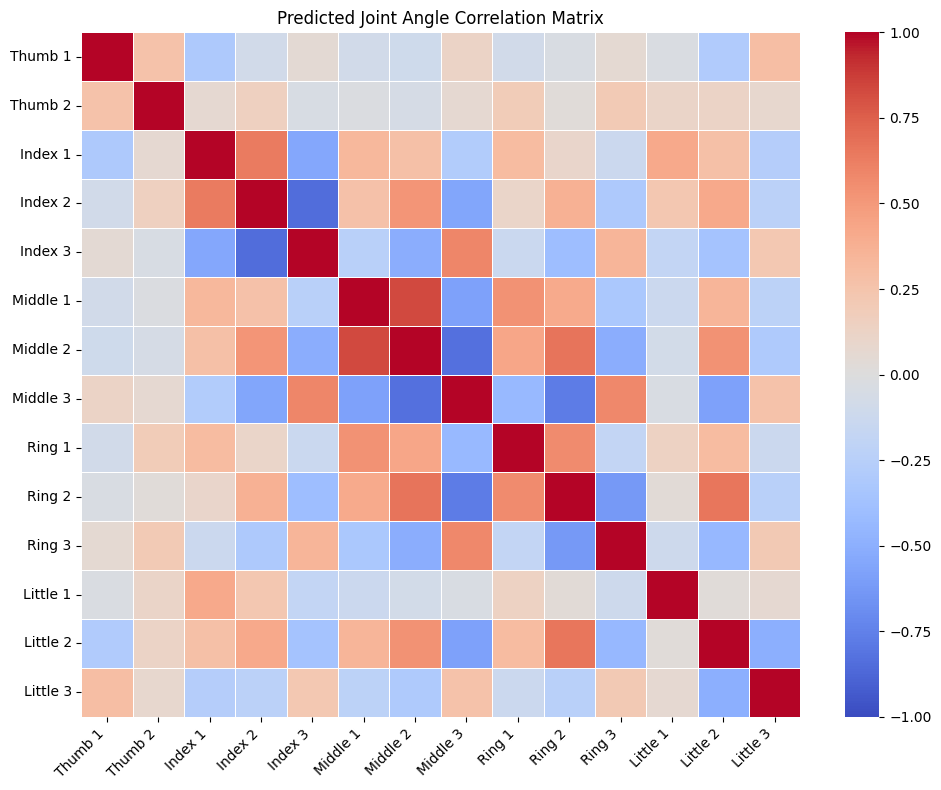


--- Visualizing True Joint Angle Correlation Matrix ---


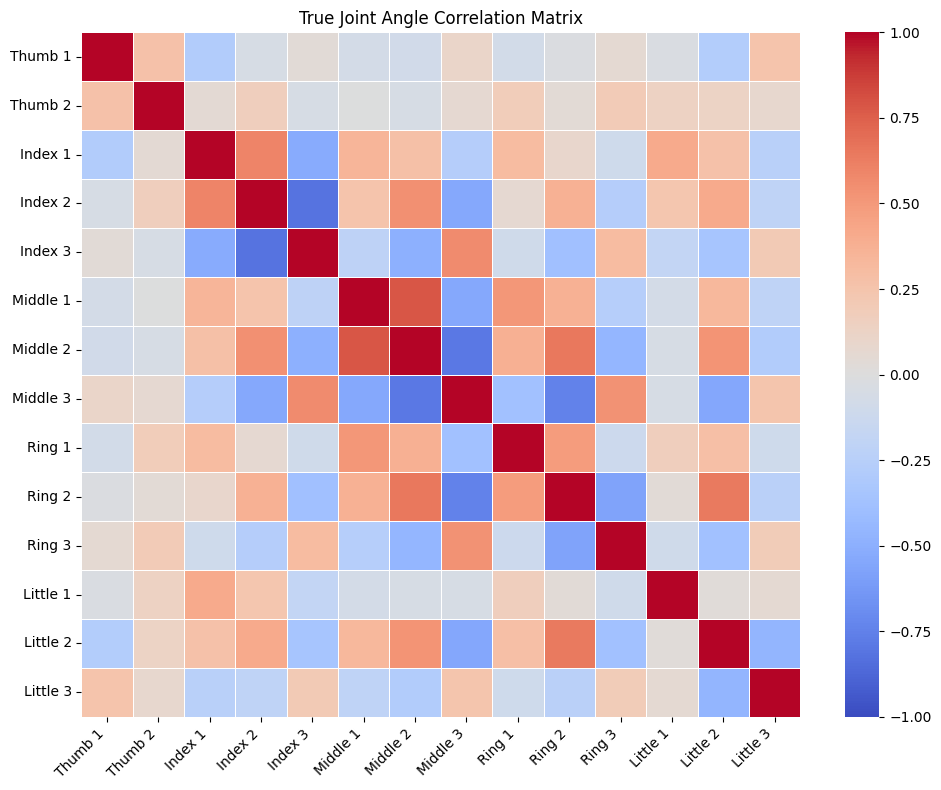

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from textwrap import wrap

# --- Dummy variables needed for the function definition ---
# Replace with actuals when integrating
JOINT_ANGLE_NAMES = [ # Example structure
    'Thumb 1', 'Thumb 2', 'Index 1', 'Index 2', 'Index 3', 'Middle 1', 'Middle 2', 'Middle 3',
    'Ring 1', 'Ring 2', 'Ring 3', 'Little 1', 'Little 2', 'Little 3'
]

# --- Visualization Function ---

def visualize_joint_angle_correlation(angle_data, joint_angle_names, data_label="Predicted"):
    """
    Calculates and visualizes the correlation matrix between joint angle time series.

    Args:
        angle_data (np.ndarray): Array of joint angles (samples, num_angles).
                                 Should ideally be rescaled to original units.
        joint_angle_names (list): List of names corresponding to the angle columns.
        data_label (str): Label for the data type (e.g., "Predicted", "True").
    """
    print(f"\n--- Visualizing {data_label} Joint Angle Correlation Matrix ---")

    if angle_data is None or angle_data.ndim != 2:
        print(f"Error: Invalid angle_data shape ({angle_data.shape if angle_data is not None else 'None'}). Expected (samples, num_angles).")
        return
    if angle_data.shape[1] != len(joint_angle_names):
        print(f"Error: Number of angles in data ({angle_data.shape[1]}) does not match number of names ({len(joint_angle_names)}).")
        return
    if angle_data.shape[0] < 2:
        print("Error: Need at least 2 samples to calculate correlations.")
        return

    # Create DataFrame for easy correlation calculation
    df_angles = pd.DataFrame(angle_data, columns=joint_angle_names)

    # Calculate pairwise correlation between columns (joint angles)
    corr_matrix = df_angles.corr()

    # Check for NaNs (can happen if an angle has zero variance)
    if corr_matrix.isnull().values.any():
        print("Warning: Correlation matrix contains NaNs (possibly due to constant angle values). Filling NaNs with 0 for visualization.")
        corr_matrix = corr_matrix.fillna(0)

    # --- Create Heatmap ---
    plt.figure(figsize=(10, 8)) # Adjust size as needed
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f",
                linewidths=.5, vmin=-1, vmax=1, cbar=True,
                xticklabels=True, yticklabels=True) # Show labels

    # Improve label readability if many joints
    if len(joint_angle_names) > 15:
         plt.xticks(fontsize=8)
         plt.yticks(fontsize=8)

    plt.title(f"{data_label} Joint Angle Correlation Matrix")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


# --- Code to Use (Example within your main script) ---
# Assume y_val_rescaled and y_pred_rescaled_all hold the rescaled angle values
# for the entire validation set.
# Assume JOINT_ANGLE_NAMES is defined.



if 'y_pred_rescaled_all' in locals() and y_pred_rescaled_all is not None:
    visualize_joint_angle_correlation(
        angle_data=y_pred_rescaled_all,
        joint_angle_names=JOINT_ANGLE_NAMES,
        data_label="Predicted"
    )
else:
    print("Skipping Predicted Angle Correlation plot (predicted data not available or not rescaled).")

# Optionally, visualize the true angle correlations for comparison
if 'y_val_rescaled' in locals() and y_val_rescaled is not None:
    visualize_joint_angle_correlation(
        angle_data=y_val_rescaled,
        joint_angle_names=JOINT_ANGLE_NAMES,
        data_label="True"
    )
else:
    print("Skipping True Angle Correlation plot (true data not available or not rescaled).")

